# OMNI BehaviorScore Rank-Order Studio &mdash; v4

**The question this studio answers.** BehaviorScore is the portfolio score (built with Experian) that estimates the chance an account rolls **2+ cycles delinquent over the next six cycles**. OMNI is a higher-quality boarded population (only the $10K credit-line tier). The portfolio team wants to know: **does BehaviorScore actually rank-order risk for OMNI?**

**How it answers.** The dashboard shows OMNI's rank-order on two prisms (Cohort + Total Portfolio), at two performance reads (30+@MOB4 + 60+@MOB6) side-by-side, with three OMNI-like comparison populations as a benchmark. The headline KPI is **D1 vs D10 lift** &mdash; the single number that says "is the score separating risk?". Roughly: &ge;2&times; clean, 1.5&ndash;2&times; weak, &lt;1.5&times; not separating. The verdict pill in the hero summarises this across both reads.

**Two prisms (different denominators on purpose).**

- **Cohort** &mdash; accounts grouped by board / open month, read at a fixed months-on-books horizon. Combine months (e.g. Nov, or Nov + Dec) and they are pooled and re-deciled together. This is the **acquisition-quality** view.
- **Total Portfolio** &mdash; a snapshot of all active + newly boarded OMNI accounts at the latest complete data month, looking forward. This is the **current-book** view.

The cohort and portfolio EDRs will look very different (cohort is usually much lower, because young boards haven't had time to misbehave). That is by design, not a bug &mdash; the Benchmark and Lift Comparison tabs control for this by comparing rank-order strength rather than absolute EDR.

**How to run.** Top to bottom. Section 4 detects the live data window from the warehouse, so re-running months from now automatically picks up new boards and newly matured performance. The final dashboard cell writes a standalone interactive HTML app and opens it in your browser.

**Tie-aware deciles.** Deciles are cut on cumulative population share of the BehaviorScore, so two accounts with the same score never land in different deciles. They are intentionally **uneven** in size. Decile 1 = lowest scores = highest expected risk.

**What changed in v4.**

- **Latest-complete-month detection (load-bearing fix).** v3 set `LATEST_DATA_MONTH = month_start(MAX(reportingdate))` and computed the portfolio snapshot from that. If the data warehouse refresh lands mid-month (e.g. 6/3/2026), the partial month does not have an end-of-month row in the fact table, and the Total Portfolio forward-window maturity check collapses to ~8 accounts at 60+@MOB6. v4 detects this and drops back to the previous complete month.
- **OMNI-like populations removed from the Population dropdown.** They're used only by the Benchmark + Lift Comparison tabs (as a comparison reference), so they no longer clutter the main selector or its per-vintage chip view.
- **Benchmark tab honours the Prism selector.** v3 was hardcoded to Total Portfolio, which made the Rank-Order tab (e.g. Cohort) and the Benchmark tab look like they disagreed. v4 reads the current prism &mdash; Cohort shows OMNI alone (no OMNI-like cohort data exists yet), Total Portfolio shows all four populations.
- **EDR + eligible count in every legend** so the universe you are looking at is never implicit.
- **Side-by-side rank-order panels** for both reads (30+@MOB4 and 60+@MOB6) plus a read-by-read comparison table on the Rank-Order tab.
- **D1 vs D10 lift KPI** (BETA) on the Rank-Order tab and a new **Lift Comparison tab** (BETA) that overlays each population's lift-normalized decile curve &mdash; level-free rank-order strength across populations.
- **Smarter verdict text** that summarises both reads at once instead of the single selected slice.
- **Trend tab: D1 vs D10 lift by board month** &mdash; rank-order stability over vintages, not just EDR.
- **Active Card tab: Activation &times; BehaviorScore band crosstab** &mdash; do low-score boards activate slower or not at all?
- **Methodology tab cleanup** &mdash; three focused cards instead of six, OMNI-like described as benchmark-only.

**Still in from v3.**

- **Valid-score floor 400&ndash;900.** Anything below 400 is an exception code, not a real score.
- **Bulk cohort pull** in Section 8 (one SQL per read covering all board months).
- **Fraud / deceased exclusion** (`dimstatusreasonid` in 52 / 88 / 43 / 55), date-scoped so it uses the reporting-date index.
- **Section 9B funnel + per-month reconciliation** against the company OMNI dashboard.

### 0. Setup & imports

In [1]:
import os
import sys
import math
from dataclasses import dataclass
from datetime import date, datetime, timedelta
from pathlib import Path
from typing import Iterable, Literal

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from dateutil.relativedelta import relativedelta
from rich.console import Console


def find_repo_root(start: Path | None = None) -> Path:
    """Find the workspace root that contains Agora.py and BehaviorScore."""
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "Agora.py").exists() and (candidate / "BehaviorScore").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Keep the original Windows Delphi path available for the C1B desktop environment.
DELPHI_PATH = Path(r"C:\Users\gsmith\88c6afda0b696ca552ccd7000b7ae067\delphi")
if DELPHI_PATH.exists() and str(DELPHI_PATH) not in sys.path:
    sys.path.append(str(DELPHI_PATH))

from Agora import C1BConnections

PROJECT_DIR = REPO_ROOT / "BehaviorScore" / "Omni_RankOrder"
DATA_DIR = PROJECT_DIR / "data"
EXPORT_DIR = PROJECT_DIR / "exports"
for folder in [DATA_DIR, EXPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

console = Console()
print(f"Repo root: {REPO_ROOT}")
print(f"Project dir: {PROJECT_DIR}")
print(f"Data dir: {DATA_DIR}")
print(f"Export dir: {EXPORT_DIR}")


Repo root: C:\Users\gsmith\88c6afda0b696ca552ccd7000b7ae067\BehaviorScore\Omni Analysis
Project dir: C:\Users\gsmith\88c6afda0b696ca552ccd7000b7ae067\BehaviorScore\Omni Analysis\BehaviorScore\Omni_RankOrder
Data dir: C:\Users\gsmith\88c6afda0b696ca552ccd7000b7ae067\BehaviorScore\Omni Analysis\BehaviorScore\Omni_RankOrder\data
Export dir: C:\Users\gsmith\88c6afda0b696ca552ccd7000b7ae067\BehaviorScore\Omni Analysis\BehaviorScore\Omni_RankOrder\exports


### 1. Connect to the data warehouse

In [2]:
# Connect to the data warehouse.  Everything below reads from this single
# DWH connection (FinancialStar.factfinancialmonthly and its dimensions).
agora = C1BConnections()
agora.connect_to_SQL("dwh")
print("Connected to DWH.")

Ready to open connections.


 Connected to SQL Server

Connected to DWH.


### 2. Configuration
Scope knobs only. The data window is detected live in Section 4.

In [3]:
# ---------------------------------------------------------------------------
# Analysis configuration.  Everything that controls SCOPE lives here.
# The data WINDOW itself is detected live in Section 4, so re-running this
# notebook months from now automatically picks up newly boarded OMNI accounts
# and newly matured performance with no edits.
# ---------------------------------------------------------------------------

# OMNI is identified from the first four characters of reservationnumber (the
# offer / program code).  SAS-confirmed codes plus the newer dashboard codes.
OMNI_PROGRAM_CODES = [
    "OM11", "OM12", "OM15",
    "WO11", "WO12", "WO13", "WO14", "WO15",
    "WXF9", "WXG9", "XB86", "XB97", "XC21",
]

# OMNI population we care about is only the $10,000 credit-line tier.
# Applied at the boarding row in every OMNI pull (cohort, portfolio, activation).
# Set to None to disable this restriction.
OMNI_CREDITLINE = 10000

# BehaviorScore validity band.  Values outside this are exception codes, not scores.
# BehaviorScore is FICO-scale-ish (roughly 400-900) so 100 would let exception
# codes leak in.  Anything below 400 is treated as a non-score and dropped.
VALID_SCORE_MIN = 400
VALID_SCORE_MAX = 900

# Cohort score observation: None = latest available valid BehaviorScore row per
# account (recommended).  Set an int to force a specific score MOB.
DEFAULT_SCORE_MOB = None
SCORE_AVAILABILITY_MAX_MOB = 8

# Performance reads.  bucket = delinquency bucket; horizon = cycles of performance.
# Cohort prism: horizon is months-on-books.  Portfolio prism: horizon is forward
# calendar months from the snapshot.  Add/edit reads here and everything follows.
READS = [
    {"key": "b30_w4", "label": "30+ within 4 cycles", "bucket": 30, "horizon": 4},
    {"key": "b60_w6", "label": "60+ within 6 cycles", "bucket": 60, "horizon": 6},
]

# Target semantics: "ever" = ever reached the bucket (or charged off) through the
# horizon.  Prior charge-off always counts as bad.
PERFORMANCE_MODE = "ever"
PERF_START_MOB = 0
N_DECILES = 10

# Portfolio snapshot includes the snapshot month itself in the forward window.
PORTFOLIO_M1_INCLUSIVE = True

# OMNI-like benchmark = non-OMNI book of comparable quality (VantageScore 731+).
OMNI_LIKE_VANTAGE_MIN = 731
OMNI_LIKE_REQUIRE_BLANK_EXTERNAL_STATUS = True
OMNI_LIKE_CURRENT_BUCKET_MAX = 29
OMNI_LIKE_M1_INCLUSIVE = True
OMNI_LIKE_PERFORMANCE_MODE = "portfolio_snapshot_forward"
OMNI_LIKE_SCORE_MOB_LABEL = "snapshot"

# Active-card tracker axis cap.
ACTIVATION_MAX_MONTHS = 12

# Fraud / deceased exclusion.  Accounts whose dimstatusreasonid has EVER been
# in this set are dropped from both numerator and denominator (population AND
# bad count) of every downstream view.  Per the team's mapping:
#   52, 88 = charge-off due to fraud
#   43, 55 = deceased
# Set to [] to disable the exclusion.
FRAUD_EXCLUSION_REASON_IDS = [52, 88, 43, 55]

# Re-pull from the warehouse instead of reading cached parquet.  Because the
# window auto-extends and recent months keep maturing, default True so a fresh
# run reflects the latest performance.  Flip to False for faster cached re-runs.
REFRESH_DATA = True

print(f"OMNI program codes : {OMNI_PROGRAM_CODES}")
print(f"Reads              : {[r['label'] for r in READS]}")
print(f"Deciles            : {N_DECILES} (tie-aware, cumulative-share)")

OMNI program codes : ['OM11', 'OM12', 'OM15', 'WO11', 'WO12', 'WO13', 'WO14', 'WO15', 'WXF9', 'WXG9', 'XB86', 'XB97', 'XC21']
Reads              : ['30+ within 4 cycles', '60+ within 6 cycles']
Deciles            : 10 (tie-aware, cumulative-share)


### 3. Helpers (proven)

In [4]:
def month_start(d: date | str | pd.Timestamp) -> date:
    if isinstance(d, str):
        d = pd.to_datetime(d).date()
    elif isinstance(d, pd.Timestamp):
        d = d.date()
    return date(d.year, d.month, 1)


def end_of_month(d: date) -> date:
    d = month_start(d)
    return (d + relativedelta(months=1)) - timedelta(days=1)


def sql_date(d: date) -> str:
    return d.strftime("%Y-%m-%d")


def sql_list(values: Iterable[str]) -> str:
    cleaned = []
    for value in values:
        v = str(value).strip().upper().replace("'", "''")
        if v:
            cleaned.append(f"'{v}'")
    if not cleaned:
        raise ValueError("SQL list cannot be empty")
    return ", ".join(cleaned)


def safe_label(value: str) -> str:
    return "".join(ch if ch.isalnum() else "_" for ch in str(value)).strip("_").lower()


def score_mob_label(score_mob: int | None) -> str:
    return "any" if score_mob is None else str(int(score_mob))


def parquet_path_for_metric(cohort_month: date, bucket: int, mob: int, score_mob: int | None, mode: str) -> Path:
    label = cohort_month.strftime("%Y%m")
    return DATA_DIR / f"omni_{label}_scoremob{score_mob_label(score_mob)}_{bucket}plus_mob{mob}_{mode}.parquet"


In [5]:
# Extra date helpers for the live window and the activation tracker.
def add_months(d, n: int) -> date:
    return month_start(d) + relativedelta(months=int(n))


def months_between(a, b) -> int:
    a = month_start(a)
    b = month_start(b)
    return (b.year - a.year) * 12 + (b.month - a.month)


def month_iter(start, end) -> list:
    cur = month_start(start)
    stop = month_start(end)
    out = []
    while cur <= stop:
        out.append(cur)
        cur = add_months(cur, 1)
    return out


def month_key(d) -> str:
    return month_start(d).strftime("%Y-%m")

### 4. Detect the live data window (auto-update)

Reads the live OMNI universe from the fact table to learn:

- `WINDOW_START_MONTH` &mdash; the first month any OMNI account boarded.
- `LATEST_REPORTING_DATE` &mdash; the most recent reportingdate in fact.
- `LATEST_DATA_MONTH` &mdash; the latest **complete** month. If the run lands mid-month, this drops back to the previous month so the forward-window maturity check has data to use (v4 fix).
- `PORTFOLIO_SNAPSHOT_MONTH` &mdash; latest data month minus the longest read horizon, so the snapshot's forward window has fully matured.

Then pulls the fraud / deceased exclusion list (scoped to the last 24 months so the query uses the reportingdate index) and the lifetime &ldquo;boarded at $10K ever&rdquo; account-id set used by the Total Portfolio restriction.

In [6]:
# ---------------------------------------------------------------------------
# Detect the live data window directly from the warehouse so the analysis
# AUTO-UPDATES on every run:
#   WINDOW_START_MONTH       - first month an OMNI account boarded
#   LATEST_REPORTING_DATE    - most recent reportingdate observed (any OMNI row)
#   LATEST_DATA_MONTH        - latest month whose END-OF-MONTH row exists in fact
#                              (i.e. the latest COMPLETE month - partial months
#                              break the forward-window maturity check)
#   AVAILABLE_BOARD_MONTHS   - every board month in between (the cohort universe)
#   PORTFOLIO_SNAPSHOT_MONTH - latest month whose longest forward read is complete
#
# v4 fix: in v3 LATEST_DATA_MONTH was just month_start(latest_reporting_date).
# If the run lands mid-month (e.g. data warehouse refresh on 6/3 of a new
# month), the EOM row for that month does not exist yet, so the Total Portfolio
# perf-window maturity check collapses to a tiny number. v4 detects this and
# drops back to the previous month when needed.
# ---------------------------------------------------------------------------
window_query = f"""
SELECT
    MIN(CASE WHEN a.newaccountindicator = 1
             THEN CAST(DATEFROMPARTS(YEAR(a.opendate), MONTH(a.opendate), 1) AS date) END) AS first_board_month,
    MAX(CAST(a.reportingdate AS date)) AS latest_reporting_date
FROM factfinancialmonthly a
WHERE a.cardid IS NOT NULL
  AND LEFT(a.reservationnumber, 4) IN ({sql_list(OMNI_PROGRAM_CODES)})
"""
window_df = pl.read_database(window_query, agora.SQL_Connection)
first_board_month = window_df["first_board_month"][0]
latest_reporting_date = window_df["latest_reporting_date"][0]
if first_board_month is None or latest_reporting_date is None:
    raise RuntimeError("No OMNI accounts found - check OMNI_PROGRAM_CODES and the connection.")

WINDOW_START_MONTH = month_start(first_board_month)
LATEST_REPORTING_DATE = (latest_reporting_date if isinstance(latest_reporting_date, date)
                         else pd.to_datetime(latest_reporting_date).date())
_latest_month_eom = end_of_month(month_start(LATEST_REPORTING_DATE))
if LATEST_REPORTING_DATE >= _latest_month_eom:
    LATEST_DATA_MONTH = month_start(LATEST_REPORTING_DATE)
    _partial_note = ""
else:
    LATEST_DATA_MONTH = add_months(month_start(LATEST_REPORTING_DATE), -1)
    _partial_note = (f" (latest reportingdate {LATEST_REPORTING_DATE} is mid-month; "
                     f"dropped back to last complete month)")

AVAILABLE_BOARD_MONTHS = month_iter(WINDOW_START_MONTH, LATEST_DATA_MONTH)
MAX_READ_HORIZON = max(r["horizon"] for r in READS)
_offset = (MAX_READ_HORIZON - 1) if PORTFOLIO_M1_INCLUSIVE else MAX_READ_HORIZON
PORTFOLIO_SNAPSHOT_MONTH = add_months(LATEST_DATA_MONTH, -_offset)

print(f"First OMNI board month  : {WINDOW_START_MONTH:%Y-%m}")
print(f"Latest reporting date   : {LATEST_REPORTING_DATE}")
print(f"Latest COMPLETE month   : {LATEST_DATA_MONTH:%Y-%m}{_partial_note}")
print(f"Board months in scope   : {len(AVAILABLE_BOARD_MONTHS)} "
      f"({AVAILABLE_BOARD_MONTHS[0]:%Y-%m} -> {AVAILABLE_BOARD_MONTHS[-1]:%Y-%m})")
print(f"Portfolio snapshot month: {PORTFOLIO_SNAPSHOT_MONTH:%Y-%m} "
      f"(longest read = {MAX_READ_HORIZON} cycles, window ends {LATEST_DATA_MONTH:%Y-%m})")

# ---------------------------------------------------------------------------
# Fraud / deceased exclusion list.  Any account whose dimstatusreasonid has
# EVER been in FRAUD_EXCLUSION_REASON_IDS is dropped from every downstream
# view (population AND bad count).  Pulled once here and reused by the
# activation, cohort, portfolio, and OMNI-like pulls.
#
# IMPORTANT performance note: dimstatusreasonid is not an indexed column on the
# fact table, so an unbounded scan can take 30+ minutes.  We scope the search
# by reportingdate (which IS indexed) starting FRAUD_LOOKBACK_MONTHS before the
# window start.  Anything older than that can't be in scope for an OMNI account
# (OMNI did not exist).
# ---------------------------------------------------------------------------
FRAUD_LOOKBACK_MONTHS = 24
if FRAUD_EXCLUSION_REASON_IDS:
    _excl_sql = ", ".join(str(int(x)) for x in FRAUD_EXCLUSION_REASON_IDS)
    _fraud_start = add_months(WINDOW_START_MONTH, -FRAUD_LOOKBACK_MONTHS)
    fraud_excl_query = f"""
    SELECT DISTINCT creditaccountid
    FROM factfinancialmonthly
    WHERE cardid IS NOT NULL
      AND reportingdate >= '{sql_date(_fraud_start)}'
      AND dimstatusreasonid IN ({_excl_sql})
    """
    _fraud_excl_df = pl.read_database(fraud_excl_query, agora.SQL_Connection)
    FRAUD_EXCLUDED_ACCOUNT_IDS = set(int(x) for x in _fraud_excl_df["creditaccountid"].to_list())
else:
    FRAUD_EXCLUDED_ACCOUNT_IDS = set()
print(f"Fraud/deceased exclusion: {len(FRAUD_EXCLUDED_ACCOUNT_IDS):,} account(s) flagged "
      f"(dimstatusreasonid in {FRAUD_EXCLUSION_REASON_IDS}, "
      f"looked back to {add_months(WINDOW_START_MONTH, -FRAUD_LOOKBACK_MONTHS):%Y-%m})")


def drop_excluded_accounts(df, excluded_ids=None):
    """Drop rows from a polars frame whose creditaccountid is in the exclusion set."""
    if excluded_ids is None:
        excluded_ids = FRAUD_EXCLUDED_ACCOUNT_IDS
    if not excluded_ids or df is None or df.height == 0:
        return df
    dtype = df.schema["creditaccountid"]
    excl = pl.DataFrame({"creditaccountid": pl.Series(list(excluded_ids), dtype=dtype)})
    return df.join(excl, on="creditaccountid", how="anti")


def drop_excluded_pdf(pdf, excluded_ids=None):
    """Drop rows from a pandas frame whose creditaccountid is in the exclusion set."""
    if excluded_ids is None:
        excluded_ids = FRAUD_EXCLUDED_ACCOUNT_IDS
    if not excluded_ids or pdf is None or pdf.empty:
        return pdf
    return pdf[~pdf["creditaccountid"].astype("int64").isin(excluded_ids)].reset_index(drop=True)


# ---------------------------------------------------------------------------
# OMNI "boarded-at-$10K" account-id lookup.  Used to restrict the Total Portfolio
# snapshot (whose row-level creditline reflects current state, not boarding
# state) to only accounts whose ORIGINAL boarding row carried this credit line.
# Cohort and activation pulls already filter at the boarding row in SQL.
# ---------------------------------------------------------------------------
if OMNI_CREDITLINE is not None:
    omni_10k_query = f"""
    SELECT DISTINCT a.creditaccountid
    FROM factfinancialmonthly a
    WHERE a.cardid IS NOT NULL
      AND a.newaccountindicator = 1
      AND LEFT(a.reservationnumber, 4) IN ({sql_list(OMNI_PROGRAM_CODES)})
      AND a.creditline = {int(OMNI_CREDITLINE)}
    """
    _omni10k_df = pl.read_database(omni_10k_query, agora.SQL_Connection)
    OMNI_BOARDED_AT_TIER_IDS = set(int(x) for x in _omni10k_df["creditaccountid"].to_list())
else:
    OMNI_BOARDED_AT_TIER_IDS = None
print(f"OMNI boarded-at-${OMNI_CREDITLINE:,}" if OMNI_CREDITLINE else "OMNI boarding-CL filter disabled",
      end="")
print(f": {len(OMNI_BOARDED_AT_TIER_IDS):,} account(s)" if OMNI_BOARDED_AT_TIER_IDS is not None else "")


def restrict_to_account_ids(df, allowed_ids):
    """Keep only rows of a polars frame whose creditaccountid is in the allowed set.
    Pass None to skip (no-op)."""
    if allowed_ids is None or df is None or df.height == 0:
        return df
    dtype = df.schema["creditaccountid"]
    keep = pl.DataFrame({"creditaccountid": pl.Series(list(allowed_ids), dtype=dtype)})
    return df.join(keep, on="creditaccountid", how="inner")

First OMNI board month  : 2025-08
Latest reporting date   : 2026-06-03
Latest COMPLETE month   : 2026-05 (latest reportingdate 2026-06-03 is mid-month; dropped back to last complete month)
Board months in scope   : 10 (2025-08 -> 2026-05)
Portfolio snapshot month: 2025-12 (longest read = 6 cycles, window ends 2026-05)
Fraud/deceased exclusion: 2,820,026 account(s) flagged (dimstatusreasonid in [52, 88, 43, 55], looked back to 2023-08)
OMNI boarded-at-$10,000: 39,512 account(s)


### 5. Core pull classes & functions (reused proven SQL)
These are copied verbatim from the original Omni rank-order notebook so the warehouse logic is unchanged, with one targeted edit on the OMNI cohort class: every OMNI boarding-row query gets `AND a.creditline = {OMNI_CREDITLINE}` injected so the cohort/availability/score-availability pulls all share the boarding credit-line filter.

In [7]:
@dataclass
class OmniBehaviorScorePull:
    connection: object
    output_dir: Path
    program_codes: list[str]

    def __post_init__(self):
        self.output_dir = Path(self.output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)
        self.program_codes = [str(c).strip().upper() for c in self.program_codes]

    @property
    def program_code_sql(self) -> str:
        return sql_list(self.program_codes)

    def available_cohorts(self, start: date, end: date) -> pl.DataFrame:
        """Summarize Omni boarded cohorts and observed MOB maturity."""
        start_eom = end_of_month(start)
        end_eom = end_of_month(end)
        query = f"""
        WITH boards_raw AS (
            SELECT
                CAST(DATEFROMPARTS(YEAR(a.reportingdate), MONTH(a.reportingdate), 1) AS date) AS vintage,
                CAST(a.reportingdate AS date) AS cohort_reportingdate,
                CAST(a.opendate AS date) AS opendate,
                a.creditaccountid,
                a.cardid,
                a.reservationnumber,
                LEFT(a.reservationnumber, 4) AS program_code,
                LEFT(a.reservationnumber, 6) AS campaign_code,
                b.channel,
                a.creditline,
                ROW_NUMBER() OVER (
                    PARTITION BY a.creditaccountid
                    ORDER BY a.reportingdate ASC, a.cardid DESC
                ) AS rn_board
            FROM factfinancialmonthly a
            LEFT JOIN dimproductoffered b
                ON a.dimproductofferedid = b.dimproductofferedid
            WHERE
                a.reportingdate >= '{sql_date(start_eom)}'
                AND a.reportingdate <= '{sql_date(end_eom)}'
                AND a.cardid IS NOT NULL
                AND a.newaccountindicator = 1
                AND LEFT(a.reservationnumber, 4) IN ({self.program_code_sql})
                AND a.creditline = {OMNI_CREDITLINE}
        ),
        boards AS (
            SELECT * FROM boards_raw WHERE rn_board = 1
        ),
        perf AS (
            SELECT
                br.creditaccountid,
                MAX(p.monthsonbooks) AS max_mob_observed
            FROM boards br
            LEFT JOIN factfinancialmonthly p
                ON br.creditaccountid = p.creditaccountid
                AND p.cardid IS NOT NULL
            GROUP BY br.creditaccountid
        )
        SELECT
            br.vintage,
            br.program_code,
            br.channel,
            COUNT(*) AS accounts,
            MIN(br.opendate) AS min_opendate,
            MAX(br.opendate) AS max_opendate,
            AVG(CAST(br.creditline AS float)) AS avg_creditline,
            SUM(CASE WHEN COALESCE(perf.max_mob_observed, -1) >= 4 THEN 1 ELSE 0 END) AS matured_mob4,
            SUM(CASE WHEN COALESCE(perf.max_mob_observed, -1) >= 6 THEN 1 ELSE 0 END) AS matured_mob6,
            MAX(perf.max_mob_observed) AS max_mob_observed
        FROM boards br
        LEFT JOIN perf
            ON br.creditaccountid = perf.creditaccountid
        GROUP BY br.vintage, br.program_code, br.channel
        ORDER BY br.vintage, br.program_code, br.channel
        """
        return pl.read_database(query, self.connection)


    def score_availability(
        self,
        cohort_month: date,
        max_mob: int = SCORE_AVAILABILITY_MAX_MOB,
    ) -> pl.DataFrame:
        """Count non-null and valid BehaviorScore rows by MOB for one Omni cohort."""
        cohort_month = month_start(cohort_month)
        cohort_eom = end_of_month(cohort_month)
        query = f"""
        WITH boards_raw AS (
            SELECT
                a.creditaccountid,
                a.cardid,
                ROW_NUMBER() OVER (
                    PARTITION BY a.creditaccountid
                    ORDER BY a.reportingdate ASC, a.cardid DESC
                ) AS rn_board
            FROM factfinancialmonthly a
            WHERE
                a.reportingdate = '{sql_date(cohort_eom)}'
                AND a.cardid IS NOT NULL
                AND a.newaccountindicator = 1
                AND LEFT(a.reservationnumber, 4) IN ({self.program_code_sql})
                AND a.creditline = {OMNI_CREDITLINE}
        ),
        boards AS (
            SELECT * FROM boards_raw WHERE rn_board = 1
        )
        SELECT
            s.monthsonbooks AS score_mob,
            COUNT(DISTINCT br.creditaccountid) AS boarded_accounts_with_row,
            COUNT(DISTINCT CASE WHEN ds.score IS NOT NULL THEN br.creditaccountid END) AS accounts_with_score,
            COUNT(DISTINCT CASE WHEN ds.score BETWEEN {VALID_SCORE_MIN} AND {VALID_SCORE_MAX} THEN br.creditaccountid END) AS accounts_with_valid_score,
            MIN(ds.score) AS min_score,
            MAX(ds.score) AS max_score
        FROM boards br
        LEFT JOIN factfinancialmonthly s
            ON br.creditaccountid = s.creditaccountid
            AND s.cardid IS NOT NULL
            AND s.monthsonbooks BETWEEN 1 AND {int(max_mob)}
        LEFT JOIN dimscore ds
            ON s.dimbehaviorscoreid = ds.dimscoreid
        GROUP BY s.monthsonbooks
        ORDER BY s.monthsonbooks
        """
        df = pl.read_database(query, self.connection)
        if df.height:
            df = df.with_columns([
                pl.lit(cohort_month.strftime("%Y-%m")).alias("cohort"),
                (pl.col("accounts_with_valid_score") / pl.col("boarded_accounts_with_row")).alias("valid_score_rate_among_rows"),
            ])
        return df

    def pull_metric_dataset(
        self,
        cohort_month: date,
        delinquency_bucket: int,
        horizon_mob: int,
        score_mob: int | None = DEFAULT_SCORE_MOB,
        performance_mode: Literal["ever", "point_in_time"] = "ever",
        perf_start_mob: int = PERF_START_MOB,
        include_invalid_scores: bool = False,
    ) -> pl.DataFrame:
        """Pull one Omni cohort with BehaviorScore and EDR target columns."""
        cohort_month = month_start(cohort_month)
        cohort_eom = end_of_month(cohort_month)
        if performance_mode not in {"ever", "point_in_time"}:
            raise ValueError("performance_mode must be 'ever' or 'point_in_time'")
        if performance_mode == "ever":
            perf_mob_clause = f"p.monthsonbooks BETWEEN {int(perf_start_mob)} AND {int(horizon_mob)}"
        else:
            perf_mob_clause = (
                f"p.monthsonbooks = {int(horizon_mob)} "
                f"OR (p.monthsonbooks BETWEEN {int(perf_start_mob)} AND {int(horizon_mob)} AND p.chargeoffindicator = 1)"
            )
        score_mob_clause = "" if score_mob is None else f"AND s.monthsonbooks = {int(score_mob)}"
        configured_score_mob_value = None if score_mob is None else int(score_mob)

        target_name = f"target_{int(delinquency_bucket)}plus_mob{int(horizon_mob)}"
        max_bucket_name = f"max_bucket_mob{int(horizon_mob)}"
        chargeoff_name = f"chargeoff_mob{int(horizon_mob)}"

        query = f"""
        WITH boards_raw AS (
            SELECT
                CAST(DATEFROMPARTS(YEAR(a.reportingdate), MONTH(a.reportingdate), 1) AS date) AS vintage,
                CAST(a.reportingdate AS date) AS cohort_reportingdate,
                CAST(a.opendate AS date) AS opendate,
                a.creditaccountid,
                a.cardid AS board_cardid,
                a.reservationnumber,
                LEFT(a.reservationnumber, 4) AS program_code,
                LEFT(a.reservationnumber, 6) AS campaign_code,
                b.channel,
                a.creditline,
                ROW_NUMBER() OVER (
                    PARTITION BY a.creditaccountid
                    ORDER BY a.reportingdate ASC, a.cardid DESC
                ) AS rn_board
            FROM factfinancialmonthly a
            LEFT JOIN dimproductoffered b
                ON a.dimproductofferedid = b.dimproductofferedid
            WHERE
                a.reportingdate = '{sql_date(cohort_eom)}'
                AND a.cardid IS NOT NULL
                AND a.newaccountindicator = 1
                AND LEFT(a.reservationnumber, 4) IN ({self.program_code_sql})
                AND a.creditline = {OMNI_CREDITLINE}
        ),
        boards AS (
            SELECT * FROM boards_raw WHERE rn_board = 1
        ),
        score_rows AS (
            SELECT
                br.creditaccountid,
                CAST(s.reportingdate AS date) AS score_reportingdate,
                s.monthsonbooks AS score_mob,
                s.dimbucketid AS bucket_at_score,
                ds.score AS bhvr_score,
                esc.externalstatuscode AS esc,
                mefi.behaviorscorecardidentifier AS scorecard,
                ROW_NUMBER() OVER (
                    PARTITION BY br.creditaccountid
                    ORDER BY
                        CASE WHEN ds.score BETWEEN {VALID_SCORE_MIN} AND {VALID_SCORE_MAX} THEN 0 ELSE 1 END,
                        CASE WHEN esc.externalstatuscode IS NULL OR LTRIM(RTRIM(esc.externalstatuscode)) = '' THEN 0 ELSE 1 END,
                        s.reportingdate DESC,
                        s.cardid DESC
                ) AS rn_score
            FROM boards br
            LEFT JOIN factfinancialmonthly s
                ON br.creditaccountid = s.creditaccountid
                AND s.cardid IS NOT NULL
                {score_mob_clause}
            LEFT JOIN dimscore ds
                ON s.dimbehaviorscoreid = ds.dimscoreid
            LEFT JOIN dimexternalstatus esc
                ON s.dimexternalstatusid = esc.dimexternalstatusid
            LEFT JOIN monthendfinancialinfo mefi
                ON s.cardid = mefi.cardid
                AND s.reportingdate = mefi.reportingdate
                AND mefi.cardid IS NOT NULL
        ),
        score AS (
            SELECT * FROM score_rows WHERE rn_score = 1
        ),
        perf_rows AS (
            SELECT
                br.creditaccountid,
                p.monthsonbooks,
                p.dimbucketid,
                p.chargeoffindicator,
                CASE WHEN p.dimstatusreasonid NOT IN (52, 88, 43, 55) THEN 1 ELSE 0 END AS contractual_chargeoff
            FROM boards br
            LEFT JOIN factfinancialmonthly p
                ON br.creditaccountid = p.creditaccountid
                AND p.cardid IS NOT NULL
                AND {perf_mob_clause}
                AND (p.activeaccountindicator = 1 OR p.chargeoffindicator = 1)
        ),
        perf AS (
            SELECT
                creditaccountid,
                MAX(monthsonbooks) AS max_mob_observed,
                MAX(dimbucketid) AS {max_bucket_name},
                MAX(CASE WHEN chargeoffindicator = 1 THEN 1 ELSE 0 END) AS {chargeoff_name},
                MAX(CASE WHEN contractual_chargeoff = 1 AND chargeoffindicator = 1 THEN 1 ELSE 0 END) AS contractual_chargeoff,
                MAX(CASE WHEN monthsonbooks = {int(horizon_mob)} THEN 1 ELSE 0 END) AS has_horizon_mob,
                MAX(CASE WHEN dimbucketid >= {int(delinquency_bucket)} OR chargeoffindicator = 1 THEN 1 ELSE 0 END) AS {target_name}
            FROM perf_rows
            GROUP BY creditaccountid
        )
        SELECT
            br.vintage,
            br.cohort_reportingdate,
            br.opendate,
            br.creditaccountid,
            br.board_cardid,
            br.reservationnumber,
            br.program_code,
            br.campaign_code,
            br.channel,
            br.creditline,
            sc.score_reportingdate,
            sc.score_mob,
            sc.bucket_at_score,
            sc.bhvr_score,
            sc.esc,
            sc.scorecard,
            perf.max_mob_observed,
            perf.{max_bucket_name},
            perf.{chargeoff_name},
            perf.contractual_chargeoff,
            perf.has_horizon_mob,
            CASE
                WHEN COALESCE(perf.has_horizon_mob, 0) = 1 OR COALESCE(perf.{chargeoff_name}, 0) = 1 THEN 1
                ELSE 0
            END AS metric_eligible,
            perf.{target_name}
        FROM boards br
        LEFT JOIN score sc
            ON br.creditaccountid = sc.creditaccountid
        LEFT JOIN perf
            ON br.creditaccountid = perf.creditaccountid
        ORDER BY br.creditaccountid
        """
        df = pl.read_database(query, self.connection)
        df = df.with_columns([
            pl.lit(int(delinquency_bucket)).alias("target_bucket"),
            pl.lit(int(horizon_mob)).alias("horizon_mob"),
            pl.lit(configured_score_mob_value).alias("configured_score_mob"),
            pl.lit(performance_mode).alias("performance_mode"),
            pl.lit(target_name).alias("target_column"),
        ])
        n_before_score_filter = df.height
        n_with_score = df.filter(pl.col("bhvr_score").is_not_null()).height if "bhvr_score" in df.columns else 0
        n_valid_score = df.filter(pl.col("bhvr_score").is_between(VALID_SCORE_MIN, VALID_SCORE_MAX)).height if "bhvr_score" in df.columns else 0
        n_eligible = df.filter(pl.col("metric_eligible") == 1).height if "metric_eligible" in df.columns else 0
        print(
            f"    Pull diagnostics before score filter: rows={n_before_score_filter:,}, "
            f"with_score={n_with_score:,}, valid_score={n_valid_score:,}, eligible={n_eligible:,}"
        )
        if not include_invalid_scores:
            df = df.filter(pl.col("bhvr_score").is_between(VALID_SCORE_MIN, VALID_SCORE_MAX))
        return df

    def load_or_pull_metric_dataset(
        self,
        cohort_month: date,
        delinquency_bucket: int,
        horizon_mob: int,
        score_mob: int | None = DEFAULT_SCORE_MOB,
        performance_mode: Literal["ever", "point_in_time"] = "ever",
        refresh: bool = REFRESH_DATA,
    ) -> pl.DataFrame:
        path = parquet_path_for_metric(cohort_month, delinquency_bucket, horizon_mob, score_mob, performance_mode)
        if path.exists() and not refresh:
            cached = pl.read_parquet(path)
            if cached.height > 0:
                print(f"[CACHE] {path.name} ({cached.height:,} rows)")
                return cached
            print(f"[CACHE EMPTY] {path.name}; repulling because zero-row caches hide score-join problems")
        print(f"[PULL] cohort={month_start(cohort_month):%Y-%m}, target={delinquency_bucket}+ @ MOB{horizon_mob}, score_mob={score_mob_label(score_mob)}, mode={performance_mode}")
        df = self.pull_metric_dataset(
            cohort_month=cohort_month,
            delinquency_bucket=delinquency_bucket,
            horizon_mob=horizon_mob,
            score_mob=score_mob,
            performance_mode=performance_mode,
        )
        df.write_parquet(path)
        print(f"[SAVE] {df.height:,} rows -> {path}")
        return df


In [8]:
def metric_target_column(df: pl.DataFrame) -> str:
    names = df.select("target_column").drop_nulls().unique().to_series().to_list()
    if len(names) == 1:
        return names[0]
    target_cols = [c for c in df.columns if c.startswith("target_") and "plus_mob" in c]
    if len(target_cols) == 1:
        return target_cols[0]
    raise ValueError(f"Expected one target column, found target_column values={names}, target-like columns={target_cols}")


def prepared_metric_frame(df: pl.DataFrame, target_col: str | None = None) -> pd.DataFrame:
    target_col = target_col or metric_target_column(df)
    cols = [
        "creditaccountid", "vintage", "program_code", "campaign_code", "channel",
        "bhvr_score", "scorecard", "metric_eligible", target_col,
        "target_bucket", "horizon_mob", "configured_score_mob", "performance_mode",
    ]
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing expected columns: {missing}")
    pdf = df.select(cols).to_pandas()
    pdf = pdf[(pdf["metric_eligible"] == 1) & pdf[target_col].notna() & pdf["bhvr_score"].notna()].copy()
    pdf[target_col] = pdf[target_col].astype(int)
    pdf["bhvr_score"] = pd.to_numeric(pdf["bhvr_score"], errors="coerce")
    pdf = pdf[pdf["bhvr_score"].between(VALID_SCORE_MIN, VALID_SCORE_MAX)].copy()
    return pdf


def build_overall_summary(df: pl.DataFrame, label: str) -> pd.DataFrame:
    target_col = metric_target_column(df)
    pdf = prepared_metric_frame(df, target_col)
    total_scored = df.height
    total_eligible = len(pdf)
    bads = int(pdf[target_col].sum()) if total_eligible else 0
    rate = bads / total_eligible if total_eligible else np.nan
    row = {
        "analysis": label,
        "target": target_col,
        "cohort": str(df.select("vintage").drop_nulls().unique().item())[:10] if df.height else None,
        "score_mob": df.select("configured_score_mob").drop_nulls().unique().item() if df.height and df.select("configured_score_mob").drop_nulls().height else "any",
        "performance_mode": df.select("performance_mode").drop_nulls().unique().item() if df.height else PERFORMANCE_MODE,
        "total_scored_rows": total_scored,
        "eligible_rows": total_eligible,
        "bads": bads,
        "rate": rate,
        "score_min": pdf["bhvr_score"].min() if total_eligible else np.nan,
        "score_max": pdf["bhvr_score"].max() if total_eligible else np.nan,
        "score_mean": pdf["bhvr_score"].mean() if total_eligible else np.nan,
    }
    return pd.DataFrame([row])


def build_decile_table(df: pl.DataFrame, n_deciles: int = N_DECILES) -> pd.DataFrame:
    target_col = metric_target_column(df)
    pdf = prepared_metric_frame(df, target_col).sort_values(["bhvr_score", "creditaccountid"]).reset_index(drop=True)

    if pdf.empty:
        return pd.DataFrame()

    # Tie-aware deciles: cut on the actual BehaviorScore value so the same
    # score is not split across two adjacent deciles.
    unique_scores = pdf["bhvr_score"].nunique(dropna=True)
    k = min(n_deciles, unique_scores)

    if k <= 1:
        pdf["score_decile"] = 1
        actual_deciles = 1
    else:
        deciles = pd.qcut(
            pdf["bhvr_score"],
            q=k,
            labels=False,
            duplicates="drop",
        )

        pdf["score_decile"] = deciles.astype(int) + 1
        actual_deciles = int(pdf["score_decile"].nunique())

    overall_rate = pdf[target_col].mean()

    grouped = (
        pdf.groupby("score_decile", observed=True)
        .agg(
            n=("creditaccountid", "count"),
            bads=(target_col, "sum"),
            score_min=("bhvr_score", "min"),
            score_max=("bhvr_score", "max"),
            score_mean=("bhvr_score", "mean"),
            score_median=("bhvr_score", "median"),
        )
        .reset_index()
        .sort_values("score_decile")
    )

    grouped["goods"] = grouped["n"] - grouped["bads"]
    grouped["bad_rate"] = grouped["bads"] / grouped["n"]
    grouped["lift_vs_overall"] = grouped["bad_rate"] / overall_rate if overall_rate else np.nan
    grouped["pct_population"] = grouped["n"] / grouped["n"].sum()
    grouped["cum_n_low_to_high"] = grouped["n"].cumsum()
    grouped["cum_bads_low_to_high"] = grouped["bads"].cumsum()
    grouped["cum_bad_rate_low_to_high"] = grouped["cum_bads_low_to_high"] / grouped["cum_n_low_to_high"]
    grouped["expected_risk_order"] = "lower score = higher expected delinquency"
    grouped["decile_method"] = "score_value_quantile_tie_aware"
    grouped["requested_deciles"] = int(n_deciles)
    grouped["actual_deciles"] = actual_deciles

    return grouped[
        [
            "score_decile",
            "score_min",
            "score_max",
            "score_mean",
            "score_median",
            "n",
            "goods",
            "bads",
            "bad_rate",
            "lift_vs_overall",
            "pct_population",
            "cum_n_low_to_high",
            "cum_bads_low_to_high",
            "cum_bad_rate_low_to_high",
            "expected_risk_order",
            "decile_method",
            "requested_deciles",
            "actual_deciles",
        ]
    ]


def build_segment_tables(df: pl.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    target_col = metric_target_column(df)
    pdf = prepared_metric_frame(df, target_col)
    def segment(col: str) -> pd.DataFrame:
        if pdf.empty:
            return pd.DataFrame()
        out = (
            pdf.groupby(col, dropna=False)
            .agg(n=("creditaccountid", "count"), bads=(target_col, "sum"), score_mean=("bhvr_score", "mean"))
            .reset_index()
            .sort_values("n", ascending=False)
        )
        out["bad_rate"] = out["bads"] / out["n"]
        return out
    return segment("program_code"), segment("channel")


def rank_order_diagnostics(deciles: pd.DataFrame) -> pd.DataFrame:
    if deciles.empty or len(deciles) < 2:
        return pd.DataFrame([{"spearman_decile_bad_rate": np.nan, "monotonic_violations": np.nan, "note": "Not enough deciles"}])
    bad_rate = deciles["bad_rate"].astype(float).to_numpy()
    # Higher score deciles should generally have lower bad rates.
    violations = int(np.sum(np.diff(bad_rate) > 0))
    spearman = deciles["score_decile"].corr(deciles["bad_rate"], method="spearman")
    note = "Pass" if violations == 0 and spearman < 0 else "Review rank-order bumps"
    return pd.DataFrame([{"spearman_decile_bad_rate": spearman, "monotonic_violations": violations, "note": note}])


def plot_decile_bad_rate(deciles: pd.DataFrame, title: str):
    if deciles.empty:
        print(f"No deciles to plot for {title}")
        return
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(deciles["score_decile"], deciles["bad_rate"] * 100, marker="o", linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("BehaviorScore Decile (1 = lowest score / highest expected risk)")
    ax.set_ylabel("Delinquency Rate (%)")
    ax.set_xticks(deciles["score_decile"])
    ax.grid(True, linestyle="--", alpha=0.35)
    fig.tight_layout()
    plt.show()


In [9]:
def portfolio_perf_end(snapshot_month: date, horizon_months: int, m1_inclusive: bool = PORTFOLIO_M1_INCLUSIVE) -> date:
    months_to_add = int(horizon_months) - 1 if m1_inclusive else int(horizon_months)
    return end_of_month(month_start(snapshot_month) + relativedelta(months=months_to_add))


def portfolio_perf_start(snapshot_month: date, m1_inclusive: bool = PORTFOLIO_M1_INCLUSIVE) -> date:
    start_month = month_start(snapshot_month) if m1_inclusive else month_start(snapshot_month) + relativedelta(months=1)
    return end_of_month(start_month)


def portfolio_parquet_path(snapshot_month: date, delinquency_bucket: int, horizon_months: int, m1_inclusive: bool = PORTFOLIO_M1_INCLUSIVE) -> Path:
    label = month_start(snapshot_month).strftime("%Y%m")
    mode = "m1inclusive" if m1_inclusive else "forwardonly"
    return DATA_DIR / f"omni_portfolio_snapshot_{label}_{delinquency_bucket}plus_{horizon_months}m_{mode}.parquet"


def pull_omni_portfolio_snapshot(
    connection,
    snapshot_month: date,
    delinquency_bucket: int,
    horizon_months: int,
    m1_inclusive: bool = PORTFOLIO_M1_INCLUSIVE,
    include_invalid_scores: bool = False,
) -> pl.DataFrame:
    snapshot_month = month_start(snapshot_month)
    obs = end_of_month(snapshot_month)
    perf_start = portfolio_perf_start(snapshot_month, m1_inclusive)
    perf_end = portfolio_perf_end(snapshot_month, horizon_months, m1_inclusive)
    target_col = f"target_{int(delinquency_bucket)}plus_mob{int(horizon_months)}"
    chargeoff_col = f"chargeoff_fwd{int(horizon_months)}m"
    max_bucket_col = f"max_bucket_fwd{int(horizon_months)}m"

    query = f"""
    WITH active_raw AS (
        SELECT
            CAST(DATEFROMPARTS(YEAR(a.reportingdate), MONTH(a.reportingdate), 1) AS date) AS vintage,
            CAST(a.reportingdate AS date) AS snapshot_reportingdate,
            CAST(a.opendate AS date) AS opendate,
            CAST(DATEFROMPARTS(YEAR(a.opendate), MONTH(a.opendate), 1) AS date) AS board_month,
            a.creditaccountid,
            a.cardid AS snapshot_cardid,
            a.activeaccountindicator,
            a.newaccountindicator,
            CASE
                WHEN a.activeaccountindicator = 1 THEN 'active'
                WHEN a.newaccountindicator = 1 THEN 'new_board'
                ELSE 'other'
            END AS snapshot_population_source,
            a.reservationnumber,
            LEFT(a.reservationnumber, 4) AS program_code,
            LEFT(a.reservationnumber, 6) AS campaign_code,
            po.channel,
            a.creditline,
            a.dimbucketid AS bucket_at_snapshot,
            ds.score AS bhvr_score,
            esc.externalstatuscode AS esc,
            mefi.behaviorscorecardidentifier AS scorecard,
            ROW_NUMBER() OVER (
                PARTITION BY a.creditaccountid
                ORDER BY
                    CASE WHEN ds.score BETWEEN {VALID_SCORE_MIN} AND {VALID_SCORE_MAX} THEN 0 ELSE 1 END,
                    CASE WHEN esc.externalstatuscode IS NULL OR LTRIM(RTRIM(esc.externalstatuscode)) = '' THEN 0 ELSE 1 END,
                    a.cardid DESC
            ) AS rn_active
        FROM factfinancialmonthly a
        LEFT JOIN dimproductoffered po
            ON a.dimproductofferedid = po.dimproductofferedid
        LEFT JOIN dimscore ds
            ON a.dimbehaviorscoreid = ds.dimscoreid
        LEFT JOIN dimexternalstatus esc
            ON a.dimexternalstatusid = esc.dimexternalstatusid
        LEFT JOIN monthendfinancialinfo mefi
            ON a.cardid = mefi.cardid
            AND mefi.reportingdate = a.reportingdate
            AND mefi.cardid IS NOT NULL
        WHERE
            a.reportingdate = '{sql_date(obs)}'
            AND a.cardid IS NOT NULL
            AND (a.activeaccountindicator = 1 OR a.newaccountindicator = 1)
            AND LEFT(a.reservationnumber, 4) IN ({sql_list(OMNI_PROGRAM_CODES)})
    ),
    active AS (
        SELECT * FROM active_raw WHERE rn_active = 1
    ),
    perf_rows AS (
        SELECT
            p.creditaccountid,
            CAST(p.reportingdate AS date) AS performance_reportingdate,
            p.dimbucketid,
            p.chargeoffindicator,
            CASE WHEN p.dimstatusreasonid NOT IN (52, 88, 43, 55) THEN 1 ELSE 0 END AS contractual_chargeoff
        FROM factfinancialmonthly p
        INNER JOIN active a
            ON p.creditaccountid = a.creditaccountid
        WHERE
            p.reportingdate >= '{sql_date(perf_start)}'
            AND p.reportingdate <= '{sql_date(perf_end)}'
            AND p.cardid IS NOT NULL
            AND (p.activeaccountindicator = 1 OR p.chargeoffindicator = 1)
    ),
    perf AS (
        SELECT
            creditaccountid,
            MAX(dimbucketid) AS {max_bucket_col},
            MAX(CASE WHEN chargeoffindicator = 1 THEN 1 ELSE 0 END) AS {chargeoff_col},
            MAX(CASE WHEN contractual_chargeoff = 1 AND chargeoffindicator = 1 THEN 1 ELSE 0 END) AS contractual_chargeoff,
            MAX(CASE WHEN performance_reportingdate = '{sql_date(perf_end)}' THEN 1 ELSE 0 END) AS has_horizon_snapshot,
            MAX(CASE WHEN dimbucketid >= {int(delinquency_bucket)} OR chargeoffindicator = 1 THEN 1 ELSE 0 END) AS {target_col}
        FROM perf_rows
        GROUP BY creditaccountid
    )
    SELECT
        a.vintage,
        a.snapshot_reportingdate,
        a.opendate,
        a.board_month,
        a.creditaccountid,
        a.snapshot_cardid,
        a.activeaccountindicator,
        a.newaccountindicator,
        a.snapshot_population_source,
        a.reservationnumber,
        a.program_code,
        a.campaign_code,
        a.channel,
        a.creditline,
        a.bucket_at_snapshot,
        a.bhvr_score,
        a.esc,
        a.scorecard,
        perf.{max_bucket_col},
        perf.{chargeoff_col},
        perf.contractual_chargeoff,
        perf.has_horizon_snapshot,
        CASE
            WHEN COALESCE(perf.has_horizon_snapshot, 0) = 1 OR COALESCE(perf.{chargeoff_col}, 0) = 1 THEN 1
            ELSE 0
        END AS metric_eligible,
        perf.{target_col}
    FROM active a
    LEFT JOIN perf
        ON a.creditaccountid = perf.creditaccountid
    ORDER BY a.creditaccountid
    """

    df = pl.read_database(query, connection)
    df = df.with_columns([
        pl.lit(int(delinquency_bucket)).alias("target_bucket"),
        pl.lit(int(horizon_months)).alias("horizon_mob"),
        pl.lit("snapshot").alias("configured_score_mob"),
        pl.lit("portfolio_forward_snapshot").alias("performance_mode"),
        pl.lit(target_col).alias("target_column"),
        pl.lit(snapshot_month.strftime("%Y-%m")).alias("snapshot_month"),
        pl.lit(sql_date(obs)).alias("snapshot_date"),
        pl.lit(sql_date(perf_start)).alias("performance_start_date"),
        pl.lit(sql_date(perf_end)).alias("performance_end_date"),
    ])

    n_before = df.height
    n_eligible = df.filter(pl.col("metric_eligible") == 1).height if "metric_eligible" in df.columns else 0
    n_valid_score = df.filter(pl.col("bhvr_score").is_between(VALID_SCORE_MIN, VALID_SCORE_MAX)).height if "bhvr_score" in df.columns else 0
    print(
        f"Portfolio snapshot diagnostics: active={n_before:,}, "
        f"eligible={n_eligible:,}, valid_score={n_valid_score:,}, "
        f"window={sql_date(perf_start)} to {sql_date(perf_end)}"
    )

    if not include_invalid_scores:
        df = df.filter(pl.col("bhvr_score").is_between(VALID_SCORE_MIN, VALID_SCORE_MAX))
    df = df.filter(pl.col("metric_eligible") == 1)
    return df



def pull_omni_portfolio_snapshot_diagnostics(
    connection,
    snapshot_month: date,
    delinquency_bucket: int,
    horizon_months: int,
    m1_inclusive: bool = PORTFOLIO_M1_INCLUSIVE,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Return board-month diagnostics before the valid-score/eligibility filters."""
    snapshot_month = month_start(snapshot_month)
    obs = end_of_month(snapshot_month)
    perf_start = portfolio_perf_start(snapshot_month, m1_inclusive)
    perf_end = portfolio_perf_end(snapshot_month, horizon_months, m1_inclusive)
    target_col = f"target_{int(delinquency_bucket)}plus_mob{int(horizon_months)}"
    chargeoff_col = f"chargeoff_fwd{int(horizon_months)}m"

    query = f"""
    WITH active_raw AS (
        SELECT
            CAST(DATEFROMPARTS(YEAR(a.reportingdate), MONTH(a.reportingdate), 1) AS date) AS vintage,
            CAST(a.reportingdate AS date) AS snapshot_reportingdate,
            CAST(a.opendate AS date) AS opendate,
            CAST(DATEFROMPARTS(YEAR(a.opendate), MONTH(a.opendate), 1) AS date) AS board_month,
            a.creditaccountid,
            a.cardid AS snapshot_cardid,
            a.activeaccountindicator,
            a.newaccountindicator,
            CASE
                WHEN a.activeaccountindicator = 1 THEN 'active'
                WHEN a.newaccountindicator = 1 THEN 'new_board'
                ELSE 'other'
            END AS snapshot_population_source,
            a.reservationnumber,
            LEFT(a.reservationnumber, 4) AS program_code,
            LEFT(a.reservationnumber, 6) AS campaign_code,
            po.channel,
            ds.score AS bhvr_score,
            esc.externalstatuscode AS esc,
            ROW_NUMBER() OVER (
                PARTITION BY a.creditaccountid
                ORDER BY
                    CASE WHEN ds.score BETWEEN {VALID_SCORE_MIN} AND {VALID_SCORE_MAX} THEN 0 ELSE 1 END,
                    CASE WHEN esc.externalstatuscode IS NULL OR LTRIM(RTRIM(esc.externalstatuscode)) = '' THEN 0 ELSE 1 END,
                    a.cardid DESC
            ) AS rn_active
        FROM factfinancialmonthly a
        LEFT JOIN dimproductoffered po
            ON a.dimproductofferedid = po.dimproductofferedid
        LEFT JOIN dimscore ds
            ON a.dimbehaviorscoreid = ds.dimscoreid
        LEFT JOIN dimexternalstatus esc
            ON a.dimexternalstatusid = esc.dimexternalstatusid
        WHERE
            a.reportingdate = '{sql_date(obs)}'
            AND a.cardid IS NOT NULL
            AND (a.activeaccountindicator = 1 OR a.newaccountindicator = 1)
            AND LEFT(a.reservationnumber, 4) IN ({sql_list(OMNI_PROGRAM_CODES)})
    ),
    active AS (
        SELECT * FROM active_raw WHERE rn_active = 1
    ),
    perf_rows AS (
        SELECT
            p.creditaccountid,
            CAST(p.reportingdate AS date) AS performance_reportingdate,
            p.dimbucketid,
            p.chargeoffindicator
        FROM factfinancialmonthly p
        INNER JOIN active a
            ON p.creditaccountid = a.creditaccountid
        WHERE
            p.reportingdate >= '{sql_date(perf_start)}'
            AND p.reportingdate <= '{sql_date(perf_end)}'
            AND p.cardid IS NOT NULL
            AND (p.activeaccountindicator = 1 OR p.chargeoffindicator = 1)
    ),
    perf AS (
        SELECT
            creditaccountid,
            MAX(CASE WHEN performance_reportingdate = '{sql_date(perf_end)}' THEN 1 ELSE 0 END) AS has_horizon_snapshot,
            MAX(CASE WHEN chargeoffindicator = 1 THEN 1 ELSE 0 END) AS {chargeoff_col},
            MAX(CASE WHEN dimbucketid >= {int(delinquency_bucket)} OR chargeoffindicator = 1 THEN 1 ELSE 0 END) AS {target_col}
        FROM perf_rows
        GROUP BY creditaccountid
    )
    SELECT
        a.board_month,
        a.snapshot_population_source,
        a.program_code,
        a.channel,
        COUNT(*) AS active_or_new_snapshot_accounts,
        SUM(CASE WHEN a.activeaccountindicator = 1 THEN 1 ELSE 0 END) AS active_snapshot_accounts,
        SUM(CASE WHEN a.newaccountindicator = 1 THEN 1 ELSE 0 END) AS new_board_snapshot_accounts,
        SUM(CASE WHEN a.bhvr_score IS NOT NULL THEN 1 ELSE 0 END) AS accounts_with_score,
        SUM(CASE WHEN a.bhvr_score BETWEEN {VALID_SCORE_MIN} AND {VALID_SCORE_MAX} THEN 1 ELSE 0 END) AS accounts_with_valid_score,
        SUM(CASE WHEN COALESCE(perf.has_horizon_snapshot, 0) = 1 OR COALESCE(perf.{chargeoff_col}, 0) = 1 THEN 1 ELSE 0 END) AS eligible_accounts,
        SUM(CASE WHEN (a.bhvr_score BETWEEN {VALID_SCORE_MIN} AND {VALID_SCORE_MAX}) AND (COALESCE(perf.has_horizon_snapshot, 0) = 1 OR COALESCE(perf.{chargeoff_col}, 0) = 1) THEN 1 ELSE 0 END) AS eligible_valid_score_accounts,
        SUM(CASE WHEN (a.bhvr_score BETWEEN {VALID_SCORE_MIN} AND {VALID_SCORE_MAX}) AND (COALESCE(perf.has_horizon_snapshot, 0) = 1 OR COALESCE(perf.{chargeoff_col}, 0) = 1) AND COALESCE(perf.{target_col}, 0) = 1 THEN 1 ELSE 0 END) AS bads_valid_score,
        AVG(CASE WHEN a.bhvr_score BETWEEN {VALID_SCORE_MIN} AND {VALID_SCORE_MAX} THEN CAST(a.bhvr_score AS float) END) AS avg_valid_score
    FROM active a
    LEFT JOIN perf
        ON a.creditaccountid = perf.creditaccountid
    GROUP BY a.board_month, a.snapshot_population_source, a.program_code, a.channel
    ORDER BY a.board_month, a.snapshot_population_source, a.program_code, a.channel
    """
    detail = pl.read_database(query, connection)
    summary = (
        detail
        .group_by("board_month")
        .agg([
            pl.col("active_or_new_snapshot_accounts").sum(),
            pl.col("active_snapshot_accounts").sum(),
            pl.col("new_board_snapshot_accounts").sum(),
            pl.col("accounts_with_score").sum(),
            pl.col("accounts_with_valid_score").sum(),
            pl.col("eligible_accounts").sum(),
            pl.col("eligible_valid_score_accounts").sum(),
            pl.col("bads_valid_score").sum(),
        ])
        .sort("board_month")
        .with_columns([
            (pl.col("accounts_with_valid_score") / pl.col("active_or_new_snapshot_accounts")).alias("valid_score_rate"),
            (pl.col("eligible_valid_score_accounts") / pl.col("active_or_new_snapshot_accounts")).alias("eligible_valid_score_rate"),
            (pl.col("bads_valid_score") / pl.col("eligible_valid_score_accounts")).alias("bad_rate_valid_score"),
        ])
    ) if detail.height else pl.DataFrame()
    return summary, detail


def load_or_pull_omni_portfolio_snapshot(
    connection,
    snapshot_month: date,
    delinquency_bucket: int,
    horizon_months: int,
    m1_inclusive: bool = PORTFOLIO_M1_INCLUSIVE,
    refresh: bool = REFRESH_DATA,
) -> pl.DataFrame:
    path = portfolio_parquet_path(snapshot_month, delinquency_bucket, horizon_months, m1_inclusive)
    if path.exists() and not refresh:
        cached = pl.read_parquet(path)
        print(f"[CACHE] {path.name} ({cached.height:,} rows)")
        return cached

    print(
        f"[PULL] portfolio snapshot={month_start(snapshot_month):%Y-%m}, "
        f"target={delinquency_bucket}+ forward {horizon_months} months"
    )
    df = pull_omni_portfolio_snapshot(
        connection=connection,
        snapshot_month=snapshot_month,
        delinquency_bucket=delinquency_bucket,
        horizon_months=horizon_months,
        m1_inclusive=m1_inclusive,
    )
    df.write_parquet(path)
    print(f"[SAVE] {df.height:,} rows -> {path}")
    return df


def pull_portfolio_snapshot_score_validity_diagnostics(
    connection,
    snapshot_month: date,
    horizon_months: int,
    m1_inclusive: bool = PORTFOLIO_M1_INCLUSIVE,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Diagnose snapshot score validity and invalid score values for the active/new Omni snapshot."""
    snapshot_month = month_start(snapshot_month)
    obs = end_of_month(snapshot_month)
    query = f"""
    WITH active_raw AS (
        SELECT
            CAST(DATEFROMPARTS(YEAR(a.opendate), MONTH(a.opendate), 1) AS date) AS board_month,
            CASE
                WHEN a.activeaccountindicator = 1 THEN 'active'
                WHEN a.newaccountindicator = 1 THEN 'new_board'
                ELSE 'other'
            END AS snapshot_population_source,
            LEFT(a.reservationnumber, 4) AS program_code,
            po.channel,
            a.creditaccountid,
            ds.score AS snapshot_bhvr_score,
            ROW_NUMBER() OVER (
                PARTITION BY a.creditaccountid
                ORDER BY
                    CASE WHEN ds.score BETWEEN {VALID_SCORE_MIN} AND {VALID_SCORE_MAX} THEN 0 ELSE 1 END,
                    a.cardid DESC
            ) AS rn_active
        FROM factfinancialmonthly a
        LEFT JOIN dimproductoffered po
            ON a.dimproductofferedid = po.dimproductofferedid
        LEFT JOIN dimscore ds
            ON a.dimbehaviorscoreid = ds.dimscoreid
        WHERE
            a.reportingdate = '{sql_date(obs)}'
            AND a.cardid IS NOT NULL
            AND (a.activeaccountindicator = 1 OR a.newaccountindicator = 1)
            AND LEFT(a.reservationnumber, 4) IN ({sql_list(OMNI_PROGRAM_CODES)})
    ),
    active AS (
        SELECT * FROM active_raw WHERE rn_active = 1
    ),
    scored AS (
        SELECT
            *,
            CASE
                WHEN snapshot_bhvr_score BETWEEN {VALID_SCORE_MIN} AND {VALID_SCORE_MAX} THEN 'valid_100_900'
                WHEN snapshot_bhvr_score IS NULL THEN 'missing_score'
                WHEN snapshot_bhvr_score < {VALID_SCORE_MIN} THEN 'below_100_exception'
                WHEN snapshot_bhvr_score > {VALID_SCORE_MAX} THEN 'above_900_exception'
                ELSE 'other_invalid'
            END AS snapshot_score_status
        FROM active
    )
    SELECT
        board_month,
        snapshot_population_source,
        program_code,
        channel,
        snapshot_score_status,
        COUNT(*) AS accounts,
        MIN(snapshot_bhvr_score) AS min_snapshot_score,
        MAX(snapshot_bhvr_score) AS max_snapshot_score,
        AVG(CAST(snapshot_bhvr_score AS float)) AS avg_snapshot_score
    FROM scored
    GROUP BY board_month, snapshot_population_source, program_code, channel, snapshot_score_status
    ORDER BY board_month, snapshot_population_source, program_code, channel, snapshot_score_status
    """
    status_detail = pl.read_database(query, connection)

    invalid_query = f"""
    WITH active_raw AS (
        SELECT
            CAST(DATEFROMPARTS(YEAR(a.opendate), MONTH(a.opendate), 1) AS date) AS board_month,
            CASE
                WHEN a.activeaccountindicator = 1 THEN 'active'
                WHEN a.newaccountindicator = 1 THEN 'new_board'
                ELSE 'other'
            END AS snapshot_population_source,
            LEFT(a.reservationnumber, 4) AS program_code,
            po.channel,
            a.creditaccountid,
            ds.score AS snapshot_bhvr_score,
            ROW_NUMBER() OVER (
                PARTITION BY a.creditaccountid
                ORDER BY
                    CASE WHEN ds.score BETWEEN {VALID_SCORE_MIN} AND {VALID_SCORE_MAX} THEN 0 ELSE 1 END,
                    a.cardid DESC
            ) AS rn_active
        FROM factfinancialmonthly a
        LEFT JOIN dimproductoffered po
            ON a.dimproductofferedid = po.dimproductofferedid
        LEFT JOIN dimscore ds
            ON a.dimbehaviorscoreid = ds.dimscoreid
        WHERE
            a.reportingdate = '{sql_date(obs)}'
            AND a.cardid IS NOT NULL
            AND (a.activeaccountindicator = 1 OR a.newaccountindicator = 1)
            AND LEFT(a.reservationnumber, 4) IN ({sql_list(OMNI_PROGRAM_CODES)})
    )
    SELECT
        board_month,
        snapshot_population_source,
        program_code,
        channel,
        snapshot_bhvr_score,
        COUNT(*) AS accounts
    FROM active_raw
    WHERE
        rn_active = 1
        AND (snapshot_bhvr_score IS NULL OR snapshot_bhvr_score < {VALID_SCORE_MIN} OR snapshot_bhvr_score > {VALID_SCORE_MAX})
    GROUP BY board_month, snapshot_population_source, program_code, channel, snapshot_bhvr_score
    ORDER BY board_month, snapshot_population_source, program_code, channel, accounts DESC
    """
    invalid_value_detail = pl.read_database(invalid_query, connection)
    return status_detail, invalid_value_detail


def portfolio_closest_score_parquet_path(snapshot_month: date, delinquency_bucket: int, horizon_months: int, m1_inclusive: bool = PORTFOLIO_M1_INCLUSIVE) -> Path:
    label = month_start(snapshot_month).strftime("%Y%m")
    mode = "m1inclusive" if m1_inclusive else "forwardonly"
    return DATA_DIR / f"omni_portfolio_snapshot_{label}_{delinquency_bucket}plus_{horizon_months}m_closestscore_{mode}.parquet"


def pull_omni_portfolio_snapshot_closest_score(
    connection,
    snapshot_month: date,
    delinquency_bucket: int,
    horizon_months: int,
    m1_inclusive: bool = PORTFOLIO_M1_INCLUSIVE,
) -> pl.DataFrame:
    """Use the closest valid BehaviorScore at or after the snapshot, bounded by the performance window."""
    snapshot_month = month_start(snapshot_month)
    obs = end_of_month(snapshot_month)
    perf_start = portfolio_perf_start(snapshot_month, m1_inclusive)
    perf_end = portfolio_perf_end(snapshot_month, horizon_months, m1_inclusive)
    target_col = f"target_{int(delinquency_bucket)}plus_mob{int(horizon_months)}"
    chargeoff_col = f"chargeoff_fwd{int(horizon_months)}m"
    max_bucket_col = f"max_bucket_fwd{int(horizon_months)}m"

    query = f"""
    WITH active_raw AS (
        SELECT
            CAST(DATEFROMPARTS(YEAR(a.reportingdate), MONTH(a.reportingdate), 1) AS date) AS vintage,
            CAST(a.reportingdate AS date) AS snapshot_reportingdate,
            CAST(a.opendate AS date) AS opendate,
            CAST(DATEFROMPARTS(YEAR(a.opendate), MONTH(a.opendate), 1) AS date) AS board_month,
            a.creditaccountid,
            a.cardid AS snapshot_cardid,
            a.activeaccountindicator,
            a.newaccountindicator,
            CASE
                WHEN a.activeaccountindicator = 1 THEN 'active'
                WHEN a.newaccountindicator = 1 THEN 'new_board'
                ELSE 'other'
            END AS snapshot_population_source,
            a.reservationnumber,
            LEFT(a.reservationnumber, 4) AS program_code,
            LEFT(a.reservationnumber, 6) AS campaign_code,
            po.channel,
            a.creditline,
            a.dimbucketid AS bucket_at_snapshot,
            ROW_NUMBER() OVER (
                PARTITION BY a.creditaccountid
                ORDER BY a.cardid DESC
            ) AS rn_active
        FROM factfinancialmonthly a
        LEFT JOIN dimproductoffered po
            ON a.dimproductofferedid = po.dimproductofferedid
        WHERE
            a.reportingdate = '{sql_date(obs)}'
            AND a.cardid IS NOT NULL
            AND (a.activeaccountindicator = 1 OR a.newaccountindicator = 1)
            AND LEFT(a.reservationnumber, 4) IN ({sql_list(OMNI_PROGRAM_CODES)})
    ),
    active AS (
        SELECT * FROM active_raw WHERE rn_active = 1
    ),
    score_rows AS (
        SELECT
            a.creditaccountid,
            CAST(s.reportingdate AS date) AS score_reportingdate,
            s.monthsonbooks AS score_mob,
            s.cardid AS score_cardid,
            ds.score AS bhvr_score,
            esc.externalstatuscode AS esc,
            mefi.behaviorscorecardidentifier AS scorecard,
            DATEDIFF(day, '{sql_date(obs)}', s.reportingdate) AS days_from_snapshot,
            ROW_NUMBER() OVER (
                PARTITION BY a.creditaccountid
                ORDER BY
                    ABS(DATEDIFF(day, '{sql_date(obs)}', s.reportingdate)) ASC,
                    s.reportingdate ASC,
                    s.cardid DESC
            ) AS rn_score
        FROM active a
        INNER JOIN factfinancialmonthly s
            ON a.creditaccountid = s.creditaccountid
            AND s.cardid IS NOT NULL
            AND s.reportingdate >= '{sql_date(obs)}'
            AND s.reportingdate <= '{sql_date(perf_end)}'
        INNER JOIN dimscore ds
            ON s.dimbehaviorscoreid = ds.dimscoreid
            AND ds.score BETWEEN {VALID_SCORE_MIN} AND {VALID_SCORE_MAX}
        LEFT JOIN dimexternalstatus esc
            ON s.dimexternalstatusid = esc.dimexternalstatusid
        LEFT JOIN monthendfinancialinfo mefi
            ON s.cardid = mefi.cardid
            AND mefi.reportingdate = s.reportingdate
            AND mefi.cardid IS NOT NULL
    ),
    score AS (
        SELECT * FROM score_rows WHERE rn_score = 1
    ),
    perf_rows AS (
        SELECT
            p.creditaccountid,
            CAST(p.reportingdate AS date) AS performance_reportingdate,
            p.dimbucketid,
            p.chargeoffindicator,
            CASE WHEN p.dimstatusreasonid NOT IN (52, 88, 43, 55) THEN 1 ELSE 0 END AS contractual_chargeoff
        FROM factfinancialmonthly p
        INNER JOIN active a
            ON p.creditaccountid = a.creditaccountid
        WHERE
            p.reportingdate >= '{sql_date(perf_start)}'
            AND p.reportingdate <= '{sql_date(perf_end)}'
            AND p.cardid IS NOT NULL
            AND (p.activeaccountindicator = 1 OR p.chargeoffindicator = 1)
    ),
    perf AS (
        SELECT
            creditaccountid,
            MAX(dimbucketid) AS {max_bucket_col},
            MAX(CASE WHEN chargeoffindicator = 1 THEN 1 ELSE 0 END) AS {chargeoff_col},
            MAX(CASE WHEN contractual_chargeoff = 1 AND chargeoffindicator = 1 THEN 1 ELSE 0 END) AS contractual_chargeoff,
            MAX(CASE WHEN performance_reportingdate = '{sql_date(perf_end)}' THEN 1 ELSE 0 END) AS has_horizon_snapshot,
            MAX(CASE WHEN dimbucketid >= {int(delinquency_bucket)} OR chargeoffindicator = 1 THEN 1 ELSE 0 END) AS {target_col}
        FROM perf_rows
        GROUP BY creditaccountid
    )
    SELECT
        a.vintage,
        a.snapshot_reportingdate,
        a.opendate,
        a.board_month,
        a.creditaccountid,
        a.snapshot_cardid,
        a.activeaccountindicator,
        a.newaccountindicator,
        a.snapshot_population_source,
        a.reservationnumber,
        a.program_code,
        a.campaign_code,
        a.channel,
        a.creditline,
        a.bucket_at_snapshot,
        sc.score_reportingdate,
        sc.score_mob,
        sc.days_from_snapshot,
        sc.bhvr_score,
        sc.esc,
        sc.scorecard,
        perf.{max_bucket_col},
        perf.{chargeoff_col},
        perf.contractual_chargeoff,
        perf.has_horizon_snapshot,
        CASE
            WHEN COALESCE(perf.has_horizon_snapshot, 0) = 1 OR COALESCE(perf.{chargeoff_col}, 0) = 1 THEN 1
            ELSE 0
        END AS metric_eligible,
        perf.{target_col}
    FROM active a
    LEFT JOIN score sc
        ON a.creditaccountid = sc.creditaccountid
    LEFT JOIN perf
        ON a.creditaccountid = perf.creditaccountid
    ORDER BY a.creditaccountid
    """
    df = pl.read_database(query, connection)
    df = df.with_columns([
        pl.lit(int(delinquency_bucket)).alias("target_bucket"),
        pl.lit(int(horizon_months)).alias("horizon_mob"),
        pl.lit("closest_valid_to_snapshot").alias("configured_score_mob"),
        pl.lit("portfolio_forward_snapshot_closest_score").alias("performance_mode"),
        pl.lit(target_col).alias("target_column"),
        pl.lit(snapshot_month.strftime("%Y-%m")).alias("snapshot_month"),
        pl.lit(sql_date(obs)).alias("snapshot_date"),
        pl.lit(sql_date(perf_start)).alias("performance_start_date"),
        pl.lit(sql_date(perf_end)).alias("performance_end_date"),
    ])
    n_active = df.height
    n_score = df.filter(pl.col("bhvr_score").is_not_null()).height
    n_eligible = df.filter(pl.col("metric_eligible") == 1).height if "metric_eligible" in df.columns else 0
    print(
        f"Closest-score diagnostics: active_snapshot={n_active:,}, "
        f"with_closest_valid_score={n_score:,}, eligible={n_eligible:,}, "
        f"score_search={sql_date(obs)} to {sql_date(perf_end)}"
    )
    df = df.filter((pl.col("bhvr_score").is_between(VALID_SCORE_MIN, VALID_SCORE_MAX)) & (pl.col("metric_eligible") == 1))
    return df


def load_or_pull_omni_portfolio_snapshot_closest_score(
    connection,
    snapshot_month: date,
    delinquency_bucket: int,
    horizon_months: int,
    m1_inclusive: bool = PORTFOLIO_M1_INCLUSIVE,
    refresh: bool = REFRESH_DATA,
) -> pl.DataFrame:
    path = portfolio_closest_score_parquet_path(snapshot_month, delinquency_bucket, horizon_months, m1_inclusive)
    if path.exists() and not refresh:
        cached = pl.read_parquet(path)
        print(f"[CACHE] {path.name} ({cached.height:,} rows)")
        return cached
    print(
        f"[PULL] portfolio closest-score snapshot={month_start(snapshot_month):%Y-%m}, "
        f"target={delinquency_bucket}+ forward {horizon_months} months"
    )
    df = pull_omni_portfolio_snapshot_closest_score(
        connection=connection,
        snapshot_month=snapshot_month,
        delinquency_bucket=delinquency_bucket,
        horizon_months=horizon_months,
        m1_inclusive=m1_inclusive,
    )
    df.write_parquet(path)
    print(f"[SAVE] {df.height:,} rows -> {path}")
    return df


In [10]:
def omni_like_perf_end(snapshot_month: date, horizon_months: int, m1_inclusive: bool = OMNI_LIKE_M1_INCLUSIVE) -> date:
    months_to_add = int(horizon_months) - 1 if m1_inclusive else int(horizon_months)
    return end_of_month(month_start(snapshot_month) + relativedelta(months=months_to_add))


def omni_like_perf_start(snapshot_month: date, m1_inclusive: bool = OMNI_LIKE_M1_INCLUSIVE) -> date:
    start_month = month_start(snapshot_month) if m1_inclusive else month_start(snapshot_month) + relativedelta(months=1)
    return end_of_month(start_month)


def omni_like_parquet_path(snapshot_month: date, delinquency_bucket: int, horizon_months: int, with_creditline_groups: bool) -> Path:
    label = month_start(snapshot_month).strftime("%Y%m")
    group_label = "creditline_groups_bs_deciles" if with_creditline_groups else "no_creditline_split_bs_deciles"
    return DATA_DIR / f"omni_like_non_omni_{label}_{delinquency_bucket}plus_mob{horizon_months}_{group_label}.parquet"


def pull_omni_like_snapshot(
    connection,
    snapshot_month: date,
    delinquency_bucket: int,
    horizon_months: int,
    with_creditline_groups: bool = False,
    refresh: bool = REFRESH_DATA,
) -> pl.DataFrame:
    snapshot_month = month_start(snapshot_month)
    obs = end_of_month(snapshot_month)
    perf_start = omni_like_perf_start(snapshot_month, OMNI_LIKE_M1_INCLUSIVE)
    perf_end = omni_like_perf_end(snapshot_month, horizon_months, OMNI_LIKE_M1_INCLUSIVE)
    target_col = f"target_{int(delinquency_bucket)}plus_mob{int(horizon_months)}"
    path = omni_like_parquet_path(snapshot_month, delinquency_bucket, horizon_months, with_creditline_groups)
    required_cached_cols = {
        "creditaccountid", "vintage", "program_code", "campaign_code", "channel",
        "bhvr_score", "scorecard", "metric_eligible", target_col,
        "target_bucket", "horizon_mob", "configured_score_mob", "performance_mode",
        "omni_like_group", "target_column",
    }

    if path.exists() and not refresh:
        cached = pl.read_parquet(path)
        if required_cached_cols.issubset(set(cached.columns)):
            print(f"[CACHE] {path.name} ({cached.height:,} rows)")
            return cached
        print(f"[CACHE STALE] Rebuilding {path.name}; cached file is missing BehaviorScore analysis columns.")

    external_status_filter = "AND (esc.externalstatuscode IS NULL OR LTRIM(RTRIM(esc.externalstatuscode)) = '')" if OMNI_LIKE_REQUIRE_BLANK_EXTERNAL_STATUS else ""

    query = f"""
    WITH snapshot_raw AS (
        SELECT
            CAST(DATEFROMPARTS(YEAR(a.reportingdate), MONTH(a.reportingdate), 1) AS date) AS snapshot_month,
            CAST(DATEFROMPARTS(YEAR(a.reportingdate), MONTH(a.reportingdate), 1) AS date) AS vintage,
            CAST(a.reportingdate AS date) AS snapshot_reportingdate,
            CAST(a.opendate AS date) AS opendate,
            CAST(DATEFROMPARTS(YEAR(a.opendate), MONTH(a.opendate), 1) AS date) AS board_month,
            a.creditaccountid,
            a.cardid AS snapshot_cardid,
            a.reservationnumber,
            LEFT(a.reservationnumber, 4) AS program_code,
            CAST(NULL AS varchar(50)) AS campaign_code,
            po.channel,
            a.creditline,
            a.Vantage3Score,
            a.dimbucketid AS bucket_at_snapshot,
            a.activeaccountindicator,
            a.newaccountindicator,
            esc.externalstatuscode AS esc,
            ds.score AS bhvr_score,
            mefi.behaviorscorecardidentifier AS scorecard,
            ROW_NUMBER() OVER (
                PARTITION BY a.creditaccountid
                ORDER BY
                    CASE WHEN ds.score BETWEEN {VALID_SCORE_MIN} AND {VALID_SCORE_MAX} THEN 0 ELSE 1 END,
                    a.cardid DESC
            ) AS rn_snapshot
        FROM factfinancialmonthly a
        LEFT JOIN dimproductoffered po
            ON a.dimproductofferedid = po.dimproductofferedid
        LEFT JOIN dimexternalstatus esc
            ON a.dimexternalstatusid = esc.dimexternalstatusid
        LEFT JOIN dimscore ds
            ON a.dimbehaviorscoreid = ds.dimscoreid
        LEFT JOIN monthendfinancialinfo mefi
            ON a.cardid = mefi.cardid
            AND mefi.reportingdate = a.reportingdate
            AND mefi.cardid IS NOT NULL
        WHERE
            a.reportingdate = '{sql_date(obs)}'
            AND a.cardid IS NOT NULL
            AND a.activeaccountindicator = 1
            AND a.dimbucketid <= {int(OMNI_LIKE_CURRENT_BUCKET_MAX)}
            AND a.Vantage3Score >= {int(OMNI_LIKE_VANTAGE_MIN)}
            AND (a.reservationnumber IS NULL OR LEFT(a.reservationnumber, 4) NOT IN ({sql_list(OMNI_PROGRAM_CODES)}))
            {external_status_filter}
    ),
    snapshot AS (
        SELECT * FROM snapshot_raw WHERE rn_snapshot = 1
    ),
    perf_rows AS (
        SELECT
            p.creditaccountid,
            CAST(p.reportingdate AS date) AS performance_reportingdate,
            p.dimbucketid,
            p.chargeoffindicator,
            CASE WHEN p.dimstatusreasonid NOT IN (52, 88, 43, 55) THEN 1 ELSE 0 END AS contractual_chargeoff
        FROM factfinancialmonthly p
        INNER JOIN snapshot s
            ON p.creditaccountid = s.creditaccountid
        WHERE
            p.reportingdate >= '{sql_date(perf_start)}'
            AND p.reportingdate <= '{sql_date(perf_end)}'
            AND p.cardid IS NOT NULL
            AND (p.activeaccountindicator = 1 OR p.chargeoffindicator = 1)
    ),
    perf AS (
        SELECT
            creditaccountid,
            MAX(dimbucketid) AS max_bucket_forward,
            MAX(CASE WHEN chargeoffindicator = 1 THEN 1 ELSE 0 END) AS chargeoff_forward,
            MAX(CASE WHEN contractual_chargeoff = 1 AND chargeoffindicator = 1 THEN 1 ELSE 0 END) AS contractual_chargeoff_forward,
            MAX(CASE WHEN dimbucketid >= {int(delinquency_bucket)} OR chargeoffindicator = 1 THEN 1 ELSE 0 END) AS {target_col}
        FROM perf_rows
        GROUP BY creditaccountid
    )
    SELECT
        s.*,
        perf.max_bucket_forward,
        perf.chargeoff_forward,
        perf.contractual_chargeoff_forward,
        COALESCE(perf.{target_col}, 0) AS {target_col}
    FROM snapshot s
    LEFT JOIN perf
        ON s.creditaccountid = perf.creditaccountid
    ORDER BY s.creditaccountid
    """

    df = pl.read_database(query, connection)
    if with_creditline_groups:
        df = df.with_columns(
            pl.when(pl.col("creditline") >= 5000).then(pl.lit("OMNI-Like Group 1 - Vantage3Score >= 731 & Credit Line >= $5,000"))
              .when((pl.col("creditline") < 5000) & (pl.col("creditline") >= 3000)).then(pl.lit("OMNI-Like Group 2 - Vantage3Score >= 731 & $5,000 > Credit Line >= $3,000"))
              .when(pl.col("creditline") < 3000).then(pl.lit("OMNI-Like Group 3 - Vantage3Score >= 731 & Credit Line < $3,000"))
              .otherwise(pl.lit("OMNI-Like Group Unknown Credit Line"))
              .alias("omni_like_group")
        )
    else:
        df = df.with_columns(pl.lit("Non-Omni Vantage3Score >= 731").alias("omni_like_group"))

    df = df.with_columns([
        pl.lit(1).alias("metric_eligible"),
        pl.lit(int(delinquency_bucket)).alias("target_bucket"),
        pl.lit(int(horizon_months)).alias("horizon_mob"),
        pl.lit(OMNI_LIKE_SCORE_MOB_LABEL).alias("configured_score_mob"),
        pl.lit(OMNI_LIKE_PERFORMANCE_MODE).alias("performance_mode"),
        pl.lit(snapshot_month.strftime("%Y-%m")).alias("snapshot_label"),
        pl.lit(sql_date(obs)).alias("snapshot_date"),
        pl.lit(sql_date(perf_start)).alias("performance_start_date"),
        pl.lit(sql_date(perf_end)).alias("performance_end_date"),
        pl.lit(target_col).alias("target_column"),
    ])
    df.write_parquet(path)
    valid_scores = df.filter(pl.col("bhvr_score").is_between(VALID_SCORE_MIN, VALID_SCORE_MAX)).height if df.height else 0
    print(
        f"[SAVE] {df.height:,} rows ({valid_scores:,} valid BehaviorScores) -> {path.name}; "
        f"snapshot={sql_date(obs)}, window={sql_date(perf_start)} to {sql_date(perf_end)}, target={target_col}"
    )
    return df


def _with_analysis_columns(pdf: pd.DataFrame, analysis: str, group: str | None = None) -> pd.DataFrame:
    out = pdf.copy()
    if out.empty:
        return out
    if "analysis" in out.columns:
        out["analysis"] = analysis
    else:
        out.insert(0, "analysis", analysis)
    if group is not None:
        if "omni_like_group" in out.columns:
            out["omni_like_group"] = group
        else:
            out.insert(1, "omni_like_group", group)
    return out


def build_omni_like_rank_order_outputs(df: pl.DataFrame, label: str, group_col: str | None = None) -> dict:
    groups: list[tuple[str | None, pl.DataFrame]]
    if group_col:
        group_values = df.select(group_col).drop_nulls().unique().sort(group_col).to_series().to_list() if df.height else []
        groups = [(str(group), df.filter(pl.col(group_col) == group)) for group in group_values]
    else:
        groups = [(None, df)]

    group_outputs = {}
    overall_parts = []
    diagnostics_parts = []
    decile_parts = []
    program_parts = []
    channel_parts = []

    for group, subset in groups:
        analysis_label = f"{label} - {group}" if group else label
        overall = _with_analysis_columns(build_overall_summary(subset, analysis_label), analysis_label, group)
        deciles = _with_analysis_columns(build_decile_table(subset, N_DECILES), analysis_label, group)
        diagnostics = _with_analysis_columns(rank_order_diagnostics(deciles), analysis_label, group)
        by_program, by_channel = build_segment_tables(subset)
        by_program = _with_analysis_columns(by_program, analysis_label, group)
        by_channel = _with_analysis_columns(by_channel, analysis_label, group)

        group_outputs[group or "all"] = {
            "overall": overall,
            "deciles": deciles,
            "diagnostics": diagnostics,
            "by_program": by_program,
            "by_channel": by_channel,
        }
        overall_parts.append(overall)
        diagnostics_parts.append(diagnostics)
        decile_parts.append(deciles)
        program_parts.append(by_program)
        channel_parts.append(by_channel)

    return {
        "groups": group_outputs,
        "overall": pd.concat(overall_parts, ignore_index=True) if overall_parts else pd.DataFrame(),
        "diagnostics": pd.concat(diagnostics_parts, ignore_index=True) if diagnostics_parts else pd.DataFrame(),
        "deciles": pd.concat(decile_parts, ignore_index=True) if decile_parts else pd.DataFrame(),
        "by_program": pd.concat(program_parts, ignore_index=True) if program_parts else pd.DataFrame(),
        "by_channel": pd.concat(channel_parts, ignore_index=True) if channel_parts else pd.DataFrame(),
    }


def display_omni_like_rank_order(payload: dict, title: str):
    print("=" * 90)
    print(title)
    if not payload["overall"].empty:
        display(payload["overall"].style.format({"rate": "{:.2%}", "score_mean": "{:.1f}"}))
    if not payload["diagnostics"].empty:
        display(payload["diagnostics"])
    if not payload["deciles"].empty:
        display(payload["deciles"].style.format({
            "score_mean": "{:.1f}",
            "score_median": "{:.1f}",
            "bad_rate": "{:.2%}",
            "lift_vs_overall": "{:.2f}",
            "pct_population": "{:.2%}",
            "cum_bad_rate_low_to_high": "{:.2%}",
        }))
    for group, group_payload in payload["groups"].items():
        plot_title = title if group == "all" else f"{title}: {group}"
        plot_decile_bad_rate(group_payload["deciles"], plot_title)

### 6. Card activation tracker pull
Activation = first month at/after boarding with `activeaccountindicator = 1`.

In [11]:
# Card-activation pull.  We board OMNI accounts but many do not turn the card
# on for months; activeaccountindicator = 1 is our activation signal.  One row
# per boarded account: board month + first month it went active.
def pull_omni_activation(connection, window_start: date, window_end: date) -> pl.DataFrame:
    start_eom = end_of_month(window_start)
    end_eom = end_of_month(window_end)
    creditline_clause = "" if OMNI_CREDITLINE is None else f"AND a.creditline = {int(OMNI_CREDITLINE)}"
    query = f"""
    WITH boards_raw AS (
        SELECT
            a.creditaccountid,
            CAST(DATEFROMPARTS(YEAR(a.opendate), MONTH(a.opendate), 1) AS date) AS board_month,
            ROW_NUMBER() OVER (
                PARTITION BY a.creditaccountid
                ORDER BY a.reportingdate ASC, a.cardid DESC
            ) AS rn_board
        FROM factfinancialmonthly a
        WHERE
            a.reportingdate >= '{sql_date(start_eom)}'
            AND a.reportingdate <= '{sql_date(end_eom)}'
            AND a.cardid IS NOT NULL
            AND a.newaccountindicator = 1
            AND LEFT(a.reservationnumber, 4) IN ({sql_list(OMNI_PROGRAM_CODES)})
            {creditline_clause}
    ),
    boards AS (
        SELECT creditaccountid, board_month FROM boards_raw WHERE rn_board = 1
    ),
    activity AS (
        SELECT
            b.creditaccountid,
            MIN(CASE WHEN p.activeaccountindicator = 1 THEN CAST(p.reportingdate AS date) END) AS first_active_date
        FROM boards b
        LEFT JOIN factfinancialmonthly p
            ON b.creditaccountid = p.creditaccountid
            AND p.cardid IS NOT NULL
            AND p.reportingdate <= '{sql_date(end_eom)}'
        GROUP BY b.creditaccountid
    )
    SELECT b.creditaccountid, b.board_month, activity.first_active_date
    FROM boards b
    LEFT JOIN activity ON b.creditaccountid = activity.creditaccountid
    ORDER BY b.creditaccountid
    """
    return pl.read_database(query, connection)


omni_activation_raw = pull_omni_activation(agora.SQL_Connection, WINDOW_START_MONTH, LATEST_DATA_MONTH)

# act_lag    = months from board to first active month (-1 = never activated yet)
# obs_months = how many months we can actually watch this account (censoring)
activation_accounts = omni_activation_raw.to_pandas()
if not activation_accounts.empty:
    activation_accounts["board_month_str"] = pd.to_datetime(activation_accounts["board_month"]).dt.strftime("%Y-%m")

    def _activation_lag(row):
        if pd.isna(row["first_active_date"]):
            return -1
        return max(0, months_between(row["board_month"], row["first_active_date"]))

    activation_accounts["act_lag"] = activation_accounts.apply(_activation_lag, axis=1)
    activation_accounts["obs_months"] = activation_accounts["board_month"].apply(
        lambda d: months_between(d, LATEST_DATA_MONTH)
    )
    # Drop fraud / deceased accounts from the activation tracker.
    _before = len(activation_accounts)
    activation_accounts = drop_excluded_pdf(activation_accounts)
    _dropped = _before - len(activation_accounts)
    _n_board = len(activation_accounts)
    _n_active = int((activation_accounts["act_lag"] >= 0).sum())
    print(f"[activation] {_n_board:,} boarded OMNI accounts (dropped {_dropped:,} fraud/deceased); "
          f"{_n_active:,} activated ({(_n_active / _n_board if _n_board else 0):.1%})")
else:
    print("[activation] no boarded OMNI accounts found")

[activation] 38,725 boarded OMNI accounts (dropped 625 fraud/deceased); 27,930 activated (72.1%)


### 7. Analytics helpers (tie-aware deciles)

In [12]:
# Tie-aware decile helper shared by the notebook views and the dashboard.
# Accounts are sorted by BehaviorScore; each distinct score's cumulative
# population share maps to a decile 1..10, so equal scores never split across a
# boundary.  Deciles are therefore intentionally UNEVEN.  Decile 1 = lowest
# scores = highest expected risk.
def cumulative_share_deciles(scores, bads, k: int = N_DECILES) -> pd.DataFrame:
    s = pd.DataFrame({"score": np.asarray(scores, dtype=float),
                      "bad": np.asarray(bads, dtype=float)}).dropna(subset=["score"])
    n = len(s)
    if n == 0:
        return pd.DataFrame()
    grp = s.groupby("score", sort=True).agg(n=("bad", "size"), bads=("bad", "sum")).reset_index()
    total_bads = float(grp["bads"].sum())
    overall = total_bads / n if n else np.nan
    grp["cum_n"] = grp["n"].cumsum()
    grp["decile"] = np.clip(np.ceil(grp["cum_n"] / n * k).astype(int), 1, k)
    out = (grp.groupby("decile")
              .agg(score_min=("score", "min"), score_max=("score", "max"),
                   n=("n", "sum"), bads=("bads", "sum"))
              .reset_index().sort_values("decile"))
    out["bad_rate"] = out["bads"] / out["n"]
    out["lift_vs_overall"] = (out["bad_rate"] / overall) if overall else np.nan
    out["pct_population"] = out["n"] / n
    out["cum_n"] = out["n"].cumsum()
    out["cum_bads"] = out["bads"].cumsum()
    out["cum_bad_rate"] = out["cum_bads"] / out["cum_n"]
    out["cum_bad_share"] = (out["cum_bads"] / total_bads) if total_bads else np.nan
    return out.reset_index(drop=True)


def eligible_score_bad(df, bucket: int, horizon: int, months=None):
    """Pull (scores, bads) for matured, valid-scored accounts in a pulled frame."""
    if df is None or df.height == 0:
        return [], []
    tcol = f"target_{int(bucket)}plus_mob{int(horizon)}"
    pdf = df.to_pandas()
    if "metric_eligible" in pdf.columns:
        pdf = pdf[pd.to_numeric(pdf["metric_eligible"], errors="coerce").fillna(0).astype(int) == 1]
    pdf = pdf[pd.to_numeric(pdf["bhvr_score"], errors="coerce").between(VALID_SCORE_MIN, VALID_SCORE_MAX)]
    if tcol not in pdf.columns:
        return [], []
    if months is not None:
        board_col = "vintage" if "vintage" in pdf.columns else ("board_month" if "board_month" in pdf.columns else None)
        if board_col is not None:
            bm = pd.to_datetime(pdf[board_col]).dt.strftime("%Y-%m")
            pdf = pdf[bm.isin(months)]
    scores = pd.to_numeric(pdf["bhvr_score"], errors="coerce").tolist()
    bads = pd.to_numeric(pdf[tcol], errors="coerce").fillna(0).astype(int).tolist()
    return scores, bads

### 8. Pull the OMNI acquisition cohorts (board-month prism)

**v3 bulk pull.** Each read runs a single SQL covering every board month, with `reportingdate` bounds on the score-row and perf-row joins so SQL Server uses its date index. In v2 this section ran one SQL per (read &times; board month) and could take 10+ hours; v3 should finish in minutes.

In [13]:
# ---------------------------------------------------------------------------
# Acquisition (Cohort) prism - BULK PULL.
#
# v2 looped one SQL pull per (board_month x read), which meant ~12 board months
# x 2 reads = ~24 separate large CTE queries against the fact table.  That can
# run for 10+ hours when the warehouse is busy.
#
# v3 collapses each read into ONE SQL pull covering ALL board months, with
# tight reportingdate bounds on every fact-table join so the optimizer uses the
# (indexed) date column.  Logic and outputs are identical to v2 - we just save
# round-trips and intermediate CTE spool work.
# ---------------------------------------------------------------------------
puller = OmniBehaviorScorePull(
    connection=agora.SQL_Connection,
    output_dir=DATA_DIR,
    program_codes=OMNI_PROGRAM_CODES,
)


def pull_omni_cohort_bulk(connection, board_months, bucket, horizon,
                          perf_start_mob=PERF_START_MOB):
    """One SQL pull covering ALL board months for one (bucket, horizon).

    Each per-account row carries `vintage` = its board month, so downstream code
    that splits by board month (the dashboard payload, the trend tab, the
    static views) continues to work unchanged.
    """
    eom_list = ", ".join(f"'{sql_date(end_of_month(m))}'" for m in board_months)
    window_start_eom = sql_date(end_of_month(board_months[0]))
    window_end_eom = sql_date(end_of_month(LATEST_DATA_MONTH))
    target_name = f"target_{int(bucket)}plus_mob{int(horizon)}"
    max_bucket_name = f"max_bucket_mob{int(horizon)}"
    chargeoff_name = f"chargeoff_mob{int(horizon)}"
    code_sql = sql_list(OMNI_PROGRAM_CODES)
    cl_clause = "" if OMNI_CREDITLINE is None else f"AND a.creditline = {int(OMNI_CREDITLINE)}"

    query = f"""
    WITH boards_raw AS (
        SELECT
            CAST(DATEFROMPARTS(YEAR(a.reportingdate), MONTH(a.reportingdate), 1) AS date) AS vintage,
            CAST(a.reportingdate AS date) AS cohort_reportingdate,
            CAST(a.opendate AS date) AS opendate,
            a.creditaccountid,
            a.cardid AS board_cardid,
            a.reservationnumber,
            LEFT(a.reservationnumber, 4) AS program_code,
            LEFT(a.reservationnumber, 6) AS campaign_code,
            b.channel,
            a.creditline,
            ROW_NUMBER() OVER (
                PARTITION BY a.creditaccountid
                ORDER BY a.reportingdate ASC, a.cardid DESC
            ) AS rn_board
        FROM factfinancialmonthly a
        LEFT JOIN dimproductoffered b
            ON a.dimproductofferedid = b.dimproductofferedid
        WHERE
            a.reportingdate IN ({eom_list})
            AND a.cardid IS NOT NULL
            AND a.newaccountindicator = 1
            AND LEFT(a.reservationnumber, 4) IN ({code_sql})
            {cl_clause}
    ),
    boards AS (SELECT * FROM boards_raw WHERE rn_board = 1),
    score_rows AS (
        SELECT
            br.creditaccountid,
            CAST(s.reportingdate AS date) AS score_reportingdate,
            s.monthsonbooks AS score_mob,
            s.dimbucketid AS bucket_at_score,
            ds.score AS bhvr_score,
            esc.externalstatuscode AS esc,
            mefi.behaviorscorecardidentifier AS scorecard,
            ROW_NUMBER() OVER (
                PARTITION BY br.creditaccountid
                ORDER BY
                    CASE WHEN ds.score BETWEEN {VALID_SCORE_MIN} AND {VALID_SCORE_MAX} THEN 0 ELSE 1 END,
                    CASE WHEN esc.externalstatuscode IS NULL OR LTRIM(RTRIM(esc.externalstatuscode)) = '' THEN 0 ELSE 1 END,
                    s.reportingdate DESC,
                    s.cardid DESC
            ) AS rn_score
        FROM boards br
        INNER JOIN factfinancialmonthly s
            ON br.creditaccountid = s.creditaccountid
            AND s.cardid IS NOT NULL
            AND s.reportingdate >= '{window_start_eom}'
            AND s.reportingdate <= '{window_end_eom}'
        LEFT JOIN dimscore ds
            ON s.dimbehaviorscoreid = ds.dimscoreid
        LEFT JOIN dimexternalstatus esc
            ON s.dimexternalstatusid = esc.dimexternalstatusid
        LEFT JOIN monthendfinancialinfo mefi
            ON s.cardid = mefi.cardid
            AND s.reportingdate = mefi.reportingdate
            AND mefi.cardid IS NOT NULL
    ),
    score AS (SELECT * FROM score_rows WHERE rn_score = 1),
    perf_rows AS (
        SELECT
            br.creditaccountid,
            p.monthsonbooks,
            p.dimbucketid,
            p.chargeoffindicator
        FROM boards br
        INNER JOIN factfinancialmonthly p
            ON br.creditaccountid = p.creditaccountid
            AND p.cardid IS NOT NULL
            AND p.reportingdate >= '{window_start_eom}'
            AND p.reportingdate <= '{window_end_eom}'
            AND p.monthsonbooks BETWEEN {int(perf_start_mob)} AND {int(horizon)}
            AND (p.activeaccountindicator = 1 OR p.chargeoffindicator = 1)
    ),
    perf AS (
        SELECT
            creditaccountid,
            MAX(monthsonbooks) AS max_mob_observed,
            MAX(dimbucketid) AS {max_bucket_name},
            MAX(CASE WHEN chargeoffindicator = 1 THEN 1 ELSE 0 END) AS {chargeoff_name},
            MAX(CASE WHEN monthsonbooks = {int(horizon)} THEN 1 ELSE 0 END) AS has_horizon_mob,
            MAX(CASE WHEN dimbucketid >= {int(bucket)} OR chargeoffindicator = 1 THEN 1 ELSE 0 END) AS {target_name}
        FROM perf_rows
        GROUP BY creditaccountid
    )
    SELECT
        br.vintage,
        br.cohort_reportingdate,
        br.opendate,
        br.creditaccountid,
        br.board_cardid,
        br.reservationnumber,
        br.program_code,
        br.campaign_code,
        br.channel,
        br.creditline,
        sc.score_reportingdate,
        sc.score_mob,
        sc.bucket_at_score,
        sc.bhvr_score,
        sc.esc,
        sc.scorecard,
        perf.max_mob_observed,
        perf.{max_bucket_name},
        perf.{chargeoff_name},
        perf.has_horizon_mob,
        CASE WHEN COALESCE(perf.has_horizon_mob, 0) = 1 OR COALESCE(perf.{chargeoff_name}, 0) = 1
             THEN 1 ELSE 0 END AS metric_eligible,
        perf.{target_name}
    FROM boards br
    LEFT JOIN score sc ON br.creditaccountid = sc.creditaccountid
    LEFT JOIN perf ON br.creditaccountid = perf.creditaccountid
    ORDER BY br.vintage, br.creditaccountid
    """
    df = pl.read_database(query, connection)
    df = df.with_columns([
        pl.lit(int(bucket)).alias("target_bucket"),
        pl.lit(int(horizon)).alias("horizon_mob"),
        pl.lit(target_name).alias("target_column"),
    ])
    # Keep only rows with a valid BehaviorScore - matches v2's payload filter.
    return df.filter(pl.col("bhvr_score").is_between(VALID_SCORE_MIN, VALID_SCORE_MAX))


omni_cohort_frames = {}
for r in READS:
    print(f"[cohort BULK PULL] {r['label']}: {len(AVAILABLE_BOARD_MONTHS)} board months in 1 SQL")
    df = pull_omni_cohort_bulk(
        connection=agora.SQL_Connection,
        board_months=AVAILABLE_BOARD_MONTHS,
        bucket=r["bucket"],
        horizon=r["horizon"],
    )
    _before = df.height
    df = drop_excluded_accounts(df)
    omni_cohort_frames[r["key"]] = df
    # Save a combined parquet so this pull is reusable.
    df.write_parquet(DATA_DIR / f"omni_cohort_bulk_{r['key']}.parquet")
    print(f"  -> {df.height:,} pooled valid-scored rows "
          f"(dropped {_before - df.height:,} fraud/deceased)")

[cohort BULK PULL] 30+ within 4 cycles: 10 board months in 1 SQL
  -> 21,828 pooled valid-scored rows (dropped 512 fraud/deceased)
[cohort BULK PULL] 60+ within 6 cycles: 10 board months in 1 SQL
  -> 21,828 pooled valid-scored rows (dropped 512 fraud/deceased)


### 9. Pull the total OMNI portfolio snapshot (snapshot-forward prism)

Snapshots all OMNI accounts that are active OR newly boarded at `PORTFOLIO_SNAPSHOT_MONTH` and walks forward over each read window. The snapshot is positioned far enough back from the latest data month that the full forward window has finished maturing.

In [14]:
# Total Portfolio prism: snapshot all active + newly boarded OMNI accounts at the
# latest mature month and look forward over each read window.
omni_portfolio_frames = {}
for r in READS:
    df = load_or_pull_omni_portfolio_snapshot(
        connection=agora.SQL_Connection,
        snapshot_month=PORTFOLIO_SNAPSHOT_MONTH,
        delinquency_bucket=r["bucket"],
        horizon_months=r["horizon"],
        m1_inclusive=PORTFOLIO_M1_INCLUSIVE,
        refresh=REFRESH_DATA,
    )
    _raw = df.height
    df = drop_excluded_accounts(df)
    _after_fraud = df.height
    df = restrict_to_account_ids(df, OMNI_BOARDED_AT_TIER_IDS)
    omni_portfolio_frames[r["key"]] = df
    print(f"[portfolio] {r['label']}: {df.height:,} eligible valid-scored accounts at "
          f"{PORTFOLIO_SNAPSHOT_MONTH:%Y-%m} "
          f"(dropped {_raw - _after_fraud:,} fraud/deceased; "
          f"dropped {_after_fraud - df.height:,} not boarded at the OMNI tier)")

[PULL] portfolio snapshot=2025-12, target=30+ forward 4 months
Portfolio snapshot diagnostics: active=23,200, eligible=18,268, valid_score=5,706, window=2025-12-31 to 2026-03-31
[SAVE] 4,477 rows -> C:\Users\gsmith\88c6afda0b696ca552ccd7000b7ae067\BehaviorScore\Omni Analysis\BehaviorScore\Omni_RankOrder\data\omni_portfolio_snapshot_202512_30plus_4m_m1inclusive.parquet
[portfolio] 30+ within 4 cycles: 1,947 eligible valid-scored accounts at 2025-12 (dropped 188 fraud/deceased; dropped 2,342 not boarded at the OMNI tier)
[PULL] portfolio snapshot=2025-12, target=60+ forward 6 months
Portfolio snapshot diagnostics: active=23,200, eligible=16,651, valid_score=5,706, window=2025-12-31 to 2026-05-31
[SAVE] 4,185 rows -> C:\Users\gsmith\88c6afda0b696ca552ccd7000b7ae067\BehaviorScore\Omni Analysis\BehaviorScore\Omni_RankOrder\data\omni_portfolio_snapshot_202512_60plus_6m_m1inclusive.parquet
[portfolio] 60+ within 6 cycles: 1,700 eligible valid-scored accounts at 2025-12 (dropped 189 fraud/dece

### 9B. Total Portfolio volume funnel + per-month reconciliation

Diagnostics-only cell, two parts:

1. **Snapshot funnel** &mdash; the waterfall of accounts that survive each Total Portfolio filter at the snapshot month, ending in the final eligible count the dashboard shows.

2. **Per-board-month reconciliation** &mdash; a table with one row per board month showing &ldquo;Boards (any CL)&rdquo; and &ldquo;Boards at $10K&rdquo;. The first column should match the company OMNI dashboard&rsquo;s &ldquo;Volume&rdquo; row line-by-line. The second column is the subset our analysis actually uses. Because the company-level average credit line is well below $10K, only a fraction of each month&rsquo;s boards land in our $10K-tier analysis &mdash; the &ldquo;$10K share&rdquo; column quantifies that fraction.

The drop between &ldquo;lifetime universe&rdquo; and the final &ldquo;eligible&rdquo; number in the funnel is structural: the portfolio prism is one snapshot month deep, while the lifetime universe spans every OMNI board ever.

In [15]:
# ---------------------------------------------------------------------------
# Total Portfolio volume FUNNEL.
#
# Reconciles the dashboard's "eligible accounts" number against the full OMNI
# underwriting universe.  The Total Portfolio prism is one snapshot month deep,
# so a long list of filters compound on top of each other and the final number
# can look surprisingly small.  This cell prints every step of the funnel so
# you can see where the volume goes, and compare to the company dashboard.
# ---------------------------------------------------------------------------
print("=" * 90)
print(f"TOTAL PORTFOLIO funnel @ snapshot {PORTFOLIO_SNAPSHOT_MONTH:%Y-%m}")
_offset_used = (MAX_READ_HORIZON - 1) if PORTFOLIO_M1_INCLUSIVE else MAX_READ_HORIZON
print(f"(longest read = {MAX_READ_HORIZON} cycles; snapshot = latest data month "
      f"{LATEST_DATA_MONTH:%Y-%m} - {_offset_used} months so the forward window is complete)")
print("-" * 90)

_obs = end_of_month(PORTFOLIO_SNAPSHOT_MONTH)
_in_clause = sql_list(OMNI_PROGRAM_CODES)

# Step-by-step screen at the snapshot month, all conditions evaluated together.
funnel_query = f"""
SELECT
  COUNT(*) AS step1_omni_rows_at_snapshot,
  SUM(CASE WHEN a.activeaccountindicator = 1 OR a.newaccountindicator = 1
           THEN 1 ELSE 0 END) AS step2_active_or_new,
  SUM(CASE WHEN (a.activeaccountindicator = 1 OR a.newaccountindicator = 1)
           AND a.creditline = {int(OMNI_CREDITLINE)} THEN 1 ELSE 0 END) AS step3_snapshot_cl_10k,
  SUM(CASE WHEN (a.activeaccountindicator = 1 OR a.newaccountindicator = 1)
           AND ds.score BETWEEN {VALID_SCORE_MIN} AND {VALID_SCORE_MAX}
           THEN 1 ELSE 0 END) AS step4_valid_score,
  SUM(CASE WHEN (a.activeaccountindicator = 1 OR a.newaccountindicator = 1)
           AND a.dimbucketid <= 29 THEN 1 ELSE 0 END) AS step5_current_or_30dpd
FROM factfinancialmonthly a
LEFT JOIN dimscore ds ON a.dimbehaviorscoreid = ds.dimscoreid
WHERE a.reportingdate = '{sql_date(_obs)}'
  AND a.cardid IS NOT NULL
  AND LEFT(a.reservationnumber, 4) IN ({_in_clause})
"""
_funnel = pl.read_database(funnel_query, agora.SQL_Connection).to_pandas().iloc[0]
print(f"  Step 1 - OMNI rows at snapshot           : {int(_funnel['step1_omni_rows_at_snapshot']):>10,}")
print(f"  Step 2 - + active OR new at snapshot     : {int(_funnel['step2_active_or_new']):>10,}")
print(f"  Step 3 - + snapshot creditline = $10K    : {int(_funnel['step3_snapshot_cl_10k']):>10,}  (snapshot CL, not boarding CL)")
print(f"  Step 4 - + valid BehaviorScore           : {int(_funnel['step4_valid_score']):>10,}  ({VALID_SCORE_MIN}-{VALID_SCORE_MAX})")
print(f"  Step 5 - + current bucket <= 29 days     : {int(_funnel['step5_current_or_30dpd']):>10,}")

# Lifetime OMNI underwriting universe (compare this to the company dashboard).
_universe = len(OMNI_BOARDED_AT_TIER_IDS) if OMNI_BOARDED_AT_TIER_IDS else 0
print(f"  Boarded at $10K EVER (lifetime universe) : {_universe:>10,}  <-- compare to company OMNI count")

# And the pulled frames at each step, per read.
print("-" * 90)
print("Per-read pulled frame breakdown:")
for r in READS:
    df_raw = load_or_pull_omni_portfolio_snapshot(
        connection=agora.SQL_Connection,
        snapshot_month=PORTFOLIO_SNAPSHOT_MONTH,
        delinquency_bucket=r["bucket"],
        horizon_months=r["horizon"],
        m1_inclusive=PORTFOLIO_M1_INCLUSIVE,
        refresh=False,   # use the parquet Section 9 just wrote
    )
    n_pulled = df_raw.height
    n_no_fraud = drop_excluded_accounts(df_raw).height
    n_tier = restrict_to_account_ids(drop_excluded_accounts(df_raw), OMNI_BOARDED_AT_TIER_IDS).height
    print(f"  [{r['label']}]  pulled={n_pulled:>6,}  no fraud/deceased={n_no_fraud:>6,}  "
          f"boarded-at-$10K={n_tier:>6,}")
print("-" * 90)
print("Reading the funnel:")
print("  - The cohort prism uses the lifetime universe (boarded ever), pooled across")
print("    every board month that has matured to the read horizon.")
print("  - The total portfolio prism uses only Step 5 above, at one single month,")
print("    AND requires the full forward window to be complete - hence the gap.")
print()

# ---------------------------------------------------------------------------
# Per-board-month volume reconciliation against the company OMNI dashboard.
# This breaks the lifetime universe down by board month so you can compare
# line-by-line against the company dashboard's "Volume" row.  The split shows
# how many of each month's boards landed at the $10K tier vs. other tiers - if
# the company dashboard's averagae CL is below $10K, only a subset of each
# month's boards are in our analysis.
# ---------------------------------------------------------------------------
print("=" * 90)
print("PER-BOARD-MONTH RECONCILIATION (compare to company dashboard 'Volume' row)")
print("-" * 90)

board_vol_query = f"""
SELECT
    CAST(DATEFROMPARTS(YEAR(a.opendate), MONTH(a.opendate), 1) AS date) AS board_month,
    COUNT(DISTINCT a.creditaccountid) AS boards_any_cl,
    COUNT(DISTINCT CASE WHEN a.creditline = {int(OMNI_CREDITLINE)}
                        THEN a.creditaccountid END) AS boards_at_tier,
    AVG(CAST(a.creditline AS float)) AS avg_creditline
FROM factfinancialmonthly a
WHERE a.cardid IS NOT NULL
  AND a.newaccountindicator = 1
  AND LEFT(a.reservationnumber, 4) IN ({_in_clause})
  AND a.reportingdate >= '{sql_date(end_of_month(WINDOW_START_MONTH))}'
  AND a.reportingdate <= '{sql_date(end_of_month(LATEST_DATA_MONTH))}'
GROUP BY CAST(DATEFROMPARTS(YEAR(a.opendate), MONTH(a.opendate), 1) AS date)
ORDER BY board_month
"""
_bv = pl.read_database(board_vol_query, agora.SQL_Connection).to_pandas()
print(f"  {'Board month':<12} {'Boards (any CL)':>16} "
      f"{'Boards @ $' + format(int(OMNI_CREDITLINE), ','):>20} "
      f"{'$' + str(OMNI_CREDITLINE) + ' share':>14} {'Avg CL':>12}")
for _, row in _bv.iterrows():
    bm = pd.to_datetime(row["board_month"]).strftime("%Y-%m")
    any_cl = int(row["boards_any_cl"])
    at_tier = int(row["boards_at_tier"])
    share = (at_tier / any_cl) if any_cl else 0
    print(f"  {bm:<12} {any_cl:>16,} {at_tier:>20,} {share:>14.1%} ${row['avg_creditline']:>10,.0f}")
_tot_any = int(_bv["boards_any_cl"].sum())
_tot_tier = int(_bv["boards_at_tier"].sum())
_tot_share = (_tot_tier / _tot_any) if _tot_any else 0
print(f"  {'TOTAL':<12} {_tot_any:>16,} {_tot_tier:>20,} {_tot_share:>14.1%}")
print()
print("How to read this table:")
print(f"  - 'Boards (any CL)' should reconcile to the company dashboard's 'Volume' row.")
print(f"  - 'Boards @ ${OMNI_CREDITLINE:,}' is the subset our analysis actually uses.")
print(f"  - If the company avg CL is well below ${OMNI_CREDITLINE:,}, only a fraction of")
print(f"    each month's boards land in our $10K analysis (see the share column).")
print(f"  - Cohort prism: pooled across all of column 2 (subject to MOB-horizon maturity).")
print(f"  - Total Portfolio prism: only the active+scored+matured slice at one snapshot month.")

TOTAL PORTFOLIO funnel @ snapshot 2025-12
(longest read = 6 cycles; snapshot = latest data month 2026-05 - 5 months so the forward window is complete)
------------------------------------------------------------------------------------------
  Step 1 - OMNI rows at snapshot           :     26,944
  Step 2 - + active OR new at snapshot     :     23,426
  Step 3 - + snapshot creditline = $10K    :     12,949  (snapshot CL, not boarding CL)
  Step 4 - + valid BehaviorScore           :      5,706  (400-900)
  Step 5 - + current bucket <= 29 days     :     23,383
  Boarded at $10K EVER (lifetime universe) :     39,512  <-- compare to company OMNI count
------------------------------------------------------------------------------------------
Per-read pulled frame breakdown:
[CACHE] omni_portfolio_snapshot_202512_30plus_4m_m1inclusive.parquet (4,477 rows)
  [30+ within 4 cycles]  pulled= 4,477  no fraud/deceased= 4,289  boarded-at-$10K= 1,947
[CACHE] omni_portfolio_snapshot_202512_60plus_6m_

### 10. Pull the OMNI-like benchmark (Vantage 731+)

Three non-OMNI populations of comparable quality, split by credit-line group (&ge;$5K, $3K-$5K, &lt;$3K). Used as side-by-side comparisons on the dashboard's Benchmark tab.

In [16]:
# OMNI-like benchmark: non-OMNI accounts of comparable quality (VantageScore 731+)
# over the same snapshot-forward window, split into credit-line groups.
omni_like_frames = {}
for r in READS:
    df = pull_omni_like_snapshot(
        connection=agora.SQL_Connection,
        snapshot_month=PORTFOLIO_SNAPSHOT_MONTH,
        delinquency_bucket=r["bucket"],
        horizon_months=r["horizon"],
        with_creditline_groups=True,
        refresh=REFRESH_DATA,
    )
    _before = df.height
    df = drop_excluded_accounts(df)
    omni_like_frames[r["key"]] = df
    _valid = df.filter(pl.col("bhvr_score").is_between(VALID_SCORE_MIN, VALID_SCORE_MAX)).height if df.height else 0
    print(f"[omni-like] {r['label']}: {df.height:,} snapshot accounts ({_valid:,} valid scores; "
          f"dropped {_before - df.height:,} fraud/deceased)")

[SAVE] 1,007,569 rows (997,876 valid BehaviorScores) -> omni_like_non_omni_202512_30plus_mob4_creditline_groups_bs_deciles.parquet; snapshot=2025-12-31, window=2025-12-31 to 2026-03-31, target=target_30plus_mob4
[omni-like] 30+ within 4 cycles: 913,896 snapshot accounts (904,672 valid scores; dropped 93,673 fraud/deceased)
[SAVE] 1,007,569 rows (997,876 valid BehaviorScores) -> omni_like_non_omni_202512_60plus_mob6_creditline_groups_bs_deciles.parquet; snapshot=2025-12-31, window=2025-12-31 to 2026-05-31, target=target_60plus_mob6
[omni-like] 60+ within 6 cycles: 913,896 snapshot accounts (904,672 valid scores; dropped 93,673 fraud/deceased)


### 11. Notebook-native sanity views

Static tables and a decile curve so the notebook reads on its own without opening the dashboard.

OMNI COHORT (all board months pooled) - 30+ within 4 cycles
  eligible accounts: 16,930, overall EDR: 0.84%


,decile,score_min,score_max,n,bads,bad_rate,lift_vs_overall,pct_population,cum_n,cum_bads,cum_bad_rate,cum_bad_share
0,1,537.000000,649.000000,1683,142.000000,8.44%,10.06,9.9%,1683,142.000000,8.44%,100.0%
1,2,650.000000,663.000000,1501,0.000000,0.00%,0.00,8.9%,3184,142.000000,4.46%,100.0%
2,3,664.000000,670.000000,1736,0.000000,0.00%,0.00,10.3%,4920,142.000000,2.89%,100.0%
3,4,671.000000,673.000000,1758,0.000000,0.00%,0.00,10.4%,6678,142.000000,2.13%,100.0%
4,5,674.000000,677.000000,1536,0.000000,0.00%,0.00,9.1%,8214,142.000000,1.73%,100.0%
5,6,678.000000,680.000000,1268,0.000000,0.00%,0.00,7.5%,9482,142.000000,1.50%,100.0%
6,7,681.000000,683.000000,1860,0.000000,0.00%,0.00,11.0%,11342,142.000000,1.25%,100.0%
7,8,684.000000,686.000000,1495,0.000000,0.00%,0.00,8.8%,12837,142.000000,1.11%,100.0%
8,9,687.000000,688.000000,2315,0.000000,0.00%,0.00,13.7%,15152,142.000000,0.94%,100.0%
9,10,689.000000,700.000000,1778,0.000000,0.00%,0.00,10.5%,16930,142.000000,0.84%,100.0%


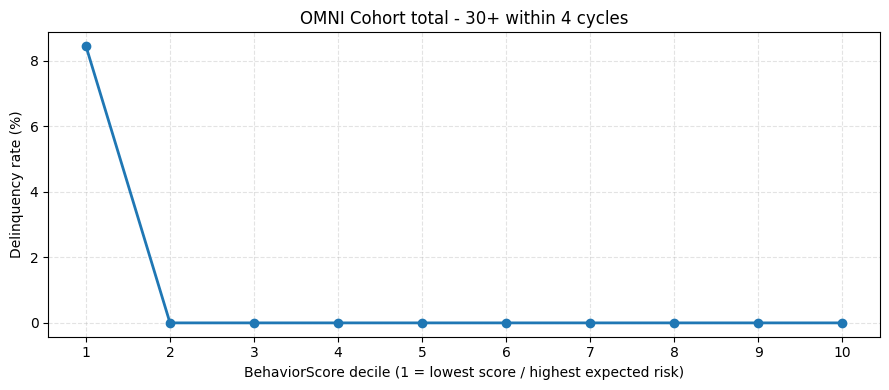

TOTAL OMNI PORTFOLIO snapshot 2025-12 - 30+ within 4 cycles
  eligible accounts: 1,947, overall EDR: 6.73%


,decile,score_min,score_max,n,bads,bad_rate,lift_vs_overall,pct_population,cum_n,cum_bads,cum_bad_rate,cum_bad_share
0,1,537.000000,641.000000,184,98.000000,53.26%,7.92,9.5%,184,98.000000,53.26%,74.8%
1,2,642.000000,654.000000,182,21.000000,11.54%,1.71,9.3%,366,119.000000,32.51%,90.8%
2,3,655.000000,659.000000,201,5.000000,2.49%,0.37,10.3%,567,124.000000,21.87%,94.7%
3,4,660.000000,663.000000,176,2.000000,1.14%,0.17,9.0%,743,126.000000,16.96%,96.2%
4,5,664.000000,665.000000,157,2.000000,1.27%,0.19,8.1%,900,128.000000,14.22%,97.7%
5,6,666.000000,667.000000,228,2.000000,0.88%,0.13,11.7%,1128,130.000000,11.52%,99.2%
6,7,668.000000,669.000000,91,0.000000,0.00%,0.00,4.7%,1219,130.000000,10.66%,99.2%
7,8,670.000000,675.000000,324,1.000000,0.31%,0.05,16.6%,1543,131.000000,8.49%,100.0%
8,9,676.000000,678.000000,204,0.000000,0.00%,0.00,10.5%,1747,131.000000,7.50%,100.0%
9,10,679.000000,691.000000,200,0.000000,0.00%,0.00,10.3%,1947,131.000000,6.73%,100.0%


CARD ACTIVATION by board month (share active by the latest data month)


,board_month_str,boarded,activated,pct_activated
0,2025-08,728,625,85.9%
1,2025-09,1060,908,85.7%
2,2025-10,2949,2417,82.0%
3,2025-11,4873,3902,80.1%
4,2025-12,5599,4366,78.0%
5,2026-01,5223,4039,77.3%
6,2026-02,5185,3868,74.6%
7,2026-03,5693,4133,72.6%
8,2026-04,4418,2836,64.2%
9,2026-05,2997,836,27.9%


In [17]:
# Notebook-native sanity views so the notebook is interpretable on its own,
# before opening the interactive dashboard.  Uses the first read, pooled across
# all board months (the "total" selection).
_read = READS[0]

print("=" * 90)
print(f"OMNI COHORT (all board months pooled) - {_read['label']}")
_sc, _bd = eligible_score_bad(omni_cohort_frames[_read["key"]], _read["bucket"], _read["horizon"])
cohort_total_deciles = cumulative_share_deciles(_sc, _bd)
print(f"  eligible accounts: {len(_sc):,}, overall EDR: "
      f"{(np.mean(_bd) if _bd else float('nan')):.2%}")
if not cohort_total_deciles.empty:
    display(cohort_total_deciles.style.format({
        "bad_rate": "{:.2%}", "lift_vs_overall": "{:.2f}", "pct_population": "{:.1%}",
        "cum_bad_rate": "{:.2%}", "cum_bad_share": "{:.1%}",
    }))
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(cohort_total_deciles["decile"], cohort_total_deciles["bad_rate"] * 100, marker="o", linewidth=2)
    ax.set_title(f"OMNI Cohort total - {_read['label']}")
    ax.set_xlabel("BehaviorScore decile (1 = lowest score / highest expected risk)")
    ax.set_ylabel("Delinquency rate (%)")
    ax.set_xticks(cohort_total_deciles["decile"])
    ax.grid(True, linestyle="--", alpha=0.35)
    fig.tight_layout()
    plt.show()

print("=" * 90)
print(f"TOTAL OMNI PORTFOLIO snapshot {PORTFOLIO_SNAPSHOT_MONTH:%Y-%m} - {_read['label']}")
_sc, _bd = eligible_score_bad(omni_portfolio_frames[_read["key"]], _read["bucket"], _read["horizon"])
portfolio_total_deciles = cumulative_share_deciles(_sc, _bd)
print(f"  eligible accounts: {len(_sc):,}, overall EDR: "
      f"{(np.mean(_bd) if _bd else float('nan')):.2%}")
if not portfolio_total_deciles.empty:
    display(portfolio_total_deciles.style.format({
        "bad_rate": "{:.2%}", "lift_vs_overall": "{:.2f}", "pct_population": "{:.1%}",
        "cum_bad_rate": "{:.2%}", "cum_bad_share": "{:.1%}",
    }))

print("=" * 90)
print("CARD ACTIVATION by board month (share active by the latest data month)")
if not activation_accounts.empty:
    _act = (activation_accounts
            .assign(active=(activation_accounts["act_lag"] >= 0).astype(int))
            .groupby("board_month_str")
            .agg(boarded=("act_lag", "size"), activated=("active", "sum"))
            .reset_index())
    _act["pct_activated"] = _act["activated"] / _act["boarded"]
    display(_act.style.format({"pct_activated": "{:.1%}"}))

### 12. Build the interactive dashboard payload

Account-level columnar data the browser re-deciles for any month combination. One dataset per (prism &times; population).

In [18]:
# Assemble the account-level payload the dashboard recomputes from.  Columnar
# arrays keep the embedded JSON compact; the browser re-deciles any month combo.
import json


def build_account_frame(frames, reads, board_col):
    key0 = reads[0]["key"]
    base = frames.get(key0)
    if base is None or base.height == 0:
        return pd.DataFrame()
    bpdf = base.to_pandas()
    out = pd.DataFrame()
    out["creditaccountid"] = bpdf["creditaccountid"]
    out["board_month"] = pd.to_datetime(bpdf[board_col]).dt.strftime("%Y-%m")
    out["program_code"] = bpdf["program_code"] if "program_code" in bpdf.columns else ""
    out["channel"] = bpdf["channel"] if "channel" in bpdf.columns else ""
    out["creditline"] = pd.to_numeric(bpdf["creditline"], errors="coerce") if "creditline" in bpdf.columns else np.nan
    out["bhvr_score"] = pd.to_numeric(bpdf["bhvr_score"], errors="coerce")
    out = out.drop_duplicates("creditaccountid")
    out = out[out["bhvr_score"].between(VALID_SCORE_MIN, VALID_SCORE_MAX)].copy().set_index("creditaccountid")
    for r in reads:
        f = frames.get(r["key"])
        tcol = f"target_{r['bucket']}plus_mob{r['horizon']}"
        if f is None or f.height == 0:
            out[f"e_{r['key']}"] = 0
            out[f"b_{r['key']}"] = 0
            continue
        fpdf = f.to_pandas()
        elig = (pd.to_numeric(fpdf["metric_eligible"], errors="coerce").fillna(0).astype(int)
                if "metric_eligible" in fpdf.columns else pd.Series(1, index=fpdf.index))
        tgt = (pd.to_numeric(fpdf[tcol], errors="coerce").fillna(0).astype(int)
               if tcol in fpdf.columns else pd.Series(0, index=fpdf.index))
        m = (pd.DataFrame({"creditaccountid": fpdf["creditaccountid"], "e": elig.values, "b": tgt.values})
             .drop_duplicates("creditaccountid").set_index("creditaccountid"))
        out[f"e_{r['key']}"] = m["e"].reindex(out.index).fillna(0).astype(int)
        out[f"b_{r['key']}"] = m["b"].reindex(out.index).fillna(0).astype(int)
    return out.reset_index()


def to_columnar(acct, reads, prism, population, did):
    if acct is None or acct.empty:
        return None
    cols = {
        "month": acct["board_month"].astype(str).tolist(),
        "score": [int(round(x)) for x in acct["bhvr_score"].tolist()],
        "cl": [None if pd.isna(x) else float(x) for x in acct["creditline"].tolist()],
        "program": acct["program_code"].fillna("").astype(str).tolist(),
        "channel": acct["channel"].fillna("").astype(str).tolist(),
    }
    rmap = {r["key"]: {"e": [int(x) for x in acct[f"e_{r['key']}"].tolist()],
                       "b": [int(x) for x in acct[f"b_{r['key']}"].tolist()]} for r in reads}
    return {"id": did, "prism": prism, "population": population, "n": int(len(acct)),
            "months": sorted(set(cols["month"])), "cols": cols, "reads": rmap}


omni_dashboard_diagnostics = []
datasets = []

# OMNI cohort + OMNI total portfolio: one dataset each.
for prism, pop, did, board_col, frames in [
    ("Cohort", "OMNI", "cohort-omni", "vintage", omni_cohort_frames),
    ("Total Portfolio", "OMNI", "port-omni", "board_month", omni_portfolio_frames),
]:
    acct = build_account_frame(frames, READS, board_col)
    ds = to_columnar(acct, READS, prism, pop, did)
    if ds:
        datasets.append(ds)
        omni_dashboard_diagnostics.append({"source": f"{prism} / {pop}", "status": "included",
                                           "message": f"{ds['n']:,} valid-scored accounts across {len(ds['months'])} board month(s)"})
    else:
        omni_dashboard_diagnostics.append({"source": f"{prism} / {pop}", "status": "empty",
                                           "message": "No accounts available for this slice."})

# OMNI-like: one dataset per credit-line group, so the Population selector treats
# each as a distinct population alongside OMNI.
OMNI_LIKE_LABEL_MAP = {
    "OMNI-Like Group 1 - Vantage3Score >= 731 & Credit Line >= $5,000":             "OMNI-like CL >= $5K",
    "OMNI-Like Group 2 - Vantage3Score >= 731 & $5,000 > Credit Line >= $3,000":    "OMNI-like CL $3K-$5K",
    "OMNI-Like Group 3 - Vantage3Score >= 731 & Credit Line < $3,000":              "OMNI-like CL < $3K",
    "OMNI-Like Group Unknown Credit Line":                                           "OMNI-like CL Unknown",
}

def _omni_like_short(g):
    return OMNI_LIKE_LABEL_MAP.get(g, str(g))

_base_like = omni_like_frames.get(READS[0]["key"]) if omni_like_frames else None
if _base_like is not None and _base_like.height:
    _like_groups = sorted(g for g in _base_like.select("omni_like_group").to_series().to_list() if g is not None)
    _like_groups = list(dict.fromkeys(_like_groups))  # dedupe preserving sort
    for grp in _like_groups:
        grp_frames = {k: v.filter(pl.col("omni_like_group") == grp) for k, v in omni_like_frames.items()}
        acct = build_account_frame(grp_frames, READS, "board_month")
        pop_label = _omni_like_short(grp)
        did = "port-like-" + safe_label(pop_label)
        ds = to_columnar(acct, READS, "Total Portfolio", pop_label, did)
        if ds:
            datasets.append(ds)
            omni_dashboard_diagnostics.append({"source": f"Total Portfolio / {pop_label}", "status": "included",
                                               "message": f"{ds['n']:,} valid-scored accounts (group: {grp})"})
        else:
            omni_dashboard_diagnostics.append({"source": f"Total Portfolio / {pop_label}", "status": "empty",
                                               "message": f"No accounts available for {grp}"})
else:
    omni_dashboard_diagnostics.append({"source": "Total Portfolio / OMNI-like", "status": "empty",
                                       "message": "No OMNI-like snapshot accounts pulled."})

if not activation_accounts.empty:
    # Attach BehaviorScore from the cohort dataset so the dashboard can render
    # the "Activation by BehaviorScore band" crosstab. Score comes from the
    # FIRST READS entry's cohort pull - one valid-scored row per account.
    _cohort_base = omni_cohort_frames.get(READS[0]["key"]) if omni_cohort_frames else None
    if _cohort_base is not None and _cohort_base.height:
        _coh_pdf = _cohort_base.to_pandas()
        _score_map = (_coh_pdf.dropna(subset=["bhvr_score"])
                              .drop_duplicates("creditaccountid")
                              .set_index("creditaccountid")["bhvr_score"]
                              .to_dict())
        activation_accounts = activation_accounts.copy()
        activation_accounts["bhvr_score"] = (activation_accounts["creditaccountid"]
                                             .map(_score_map))
    else:
        activation_accounts = activation_accounts.copy()
        activation_accounts["bhvr_score"] = np.nan

    activation_payload = {
        "months": sorted(activation_accounts["board_month_str"].unique().tolist()),
        "n": int(len(activation_accounts)),
        "cols": {
            "month": activation_accounts["board_month_str"].astype(str).tolist(),
            "act_lag": [int(x) for x in activation_accounts["act_lag"].tolist()],
            "obs_months": [int(x) for x in activation_accounts["obs_months"].tolist()],
            "score": [None if pd.isna(s) else int(round(float(s)))
                      for s in activation_accounts["bhvr_score"].tolist()],
        },
    }
    _scored = int(sum(1 for s in activation_payload["cols"]["score"] if s is not None))
    omni_dashboard_diagnostics.append({"source": "Active card tracker", "status": "included",
                                       "message": f"{activation_payload['n']:,} boarded accounts "
                                                  f"({_scored:,} with cohort BehaviorScore for "
                                                  f"the Activation x Score crosstab)"})
else:
    activation_payload = None
    omni_dashboard_diagnostics.append({"source": "Active card tracker", "status": "empty",
                                       "message": "No boarded accounts."})

omni_meta = {
    "generated_at": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "latest_data_month": LATEST_DATA_MONTH.strftime("%Y-%m"),
    "program_codes": OMNI_PROGRAM_CODES,
    "omni_creditline": int(OMNI_CREDITLINE) if OMNI_CREDITLINE is not None else None,
    "fraud_exclusion_ids": FRAUD_EXCLUSION_REASON_IDS,
    "valid_score_min": VALID_SCORE_MIN,
    "valid_score_max": VALID_SCORE_MAX,
    "n_deciles": N_DECILES,
    "reads": [{"key": r["key"], "label": r["label"], "bucket": r["bucket"], "horizon": r["horizon"]} for r in READS],
}

omni_payload = {"meta": omni_meta, "datasets": datasets,
                "activation": activation_payload, "diagnostics": omni_dashboard_diagnostics}
print(f"Datasets embedded   : {[d['id'] for d in datasets]}")
print(f"Account rows embedded: {sum(d['n'] for d in datasets):,}")

Datasets embedded   : ['cohort-omni', 'port-omni', 'port-like-omni_like_cl_____5k', 'port-like-omni_like_cl__3k__5k', 'port-like-omni_like_cl____3k']
Account rows embedded: 928,447


### 13. Render & export the standalone D3 dashboard

Writes a self-contained HTML file plus a companion JSON and opens it in your default browser.

**v4 dashboard layout:**

- **Rank-Order tab** &mdash; KPI strip (with D1/D10 lift BETA), both reads side-by-side, cumulative bad capture, read-by-read summary, decile detail table.
- **Cohort Trend tab** &mdash; EDR by board month + D1/D10 lift by board month (rank-order stability over vintages).
- **Active Card Tracker** &mdash; activation curve, lag distribution, by-month table, and Activation &times; BehaviorScore band crosstab.
- **Benchmark tab** &mdash; OMNI vs three OMNI-like populations on absolute EDR; honours the Prism selector.
- **Lift Comparison tab (BETA)** &mdash; the same populations on a lift-normalized axis so the rank-order strengths are directly comparable regardless of baseline EDR.
- **Methodology** &mdash; three concise cards + build diagnostics.

In [19]:
# Render the standalone interactive D3 dashboard.  The notebook prepares the
# payload, writes a self-contained HTML file plus a companion JSON, and opens it
# in the browser (the standalone-app pattern, reliable across notebook envs).
import json
import uuid
import webbrowser

OMNI_DASHBOARD_TEMPLATE = r'''<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>OMNI BehaviorScore Rank-Order Studio</title>
<script src="https://d3js.org/d3.v7.min.js"></script>
<style>
:root{
  --ink:#1d2b31;--ink-soft:#3a4a52;--muted:#74838a;--faint:#9aa7ac;
  --paper:#f5f3ec;--panel:#ffffff;--line:#e2e6dd;--line-soft:#eef1ea;
  --omni:#3f7d6e;--omni-soft:#e2efe9;--bench:#b9794f;--bench-soft:#f4e8dd;
  --good:#5b8f7c;--bad:#b35a52;--warn:#d8a23c;--accent:#2f5d6b;--ink-chip:#243036;
  --shadow:0 18px 48px rgba(28,42,38,.10);--shadow-sm:0 8px 22px rgba(28,42,38,.06);
}
*{box-sizing:border-box}
html,body{margin:0;padding:0}
body{background:var(--paper);color:var(--ink);
  font-family:"Inter","Segoe UI",Roboto,Helvetica,Arial,sans-serif;
  -webkit-font-smoothing:antialiased;line-height:1.45}
.wrap{max-width:1500px;margin:0 auto;padding:26px 26px 60px}
.serif{font-family:"Iowan Old Style","Palatino Linotype","Georgia",serif}

/* Hero */
.hero{position:relative;background:
   radial-gradient(1200px 320px at 88% -40%,rgba(63,125,110,.16),transparent 60%),
   linear-gradient(135deg,#ffffff 0%,#f4f7f1 55%,#eef4ef 100%);
  border:1px solid var(--line);border-radius:20px;padding:30px 32px;box-shadow:var(--shadow)}
.eyebrow{font-size:11px;letter-spacing:.22em;text-transform:uppercase;color:var(--omni);font-weight:800}
.hero h1{margin:10px 0 0;font-size:33px;line-height:1.08;letter-spacing:-.01em;max-width:900px}
.hero .lede{margin-top:12px;color:var(--ink-soft);max-width:880px;font-size:15px}
.hero-foot{margin-top:20px;display:flex;flex-wrap:wrap;gap:10px;align-items:center}
.tag{background:rgba(255,255,255,.7);border:1px solid var(--line);border-radius:999px;
  padding:7px 13px;font-size:12px;color:var(--ink-soft)}
.tag b{color:var(--ink)}
.verdict{margin-left:auto;display:flex;align-items:center;gap:10px;background:var(--ink-chip);
  color:#eef3ee;border-radius:14px;padding:11px 16px;font-size:13px;box-shadow:var(--shadow-sm);max-width:520px}
.verdict .dot{width:10px;height:10px;border-radius:50%;background:var(--good);box-shadow:0 0 0 4px rgba(91,143,124,.25);flex-shrink:0}
.verdict.warn .dot{background:var(--warn);box-shadow:0 0 0 4px rgba(216,162,60,.25)}
.verdict.bad .dot{background:var(--bad);box-shadow:0 0 0 4px rgba(179,90,82,.25)}

/* Control bar */
.controls{position:sticky;top:0;z-index:30;margin:18px 0 16px;background:rgba(245,243,236,.92);
  backdrop-filter:blur(6px);border:1px solid var(--line);border-radius:16px;padding:14px;box-shadow:var(--shadow-sm)}
.control-grid{display:grid;grid-template-columns:repeat(3,minmax(0,1fr));gap:12px}
.ctl label{display:block;font-size:10px;letter-spacing:.1em;text-transform:uppercase;color:var(--muted);font-weight:800;margin-bottom:6px}
.ctl select{width:100%;border:1px solid var(--line);background:#fff;color:var(--ink);border-radius:10px;
  padding:9px 10px;font-size:13px;font-family:inherit}
.months{margin-top:13px}
.months .hd{display:flex;align-items:center;justify-content:space-between;margin-bottom:8px}
.months .hd .hint{font-size:11px;color:var(--muted)}
.chiprow{display:flex;flex-wrap:wrap;gap:7px}
.chip{border:1px solid var(--line);background:#fff;color:var(--ink-soft);border-radius:999px;
  padding:7px 13px;font-size:12px;cursor:pointer;user-select:none;transition:all .12s ease;font-weight:600}
.chip:hover{border-color:var(--omni);color:var(--omni)}
.chip.on{background:var(--omni);border-color:var(--omni);color:#fff;box-shadow:0 6px 14px rgba(63,125,110,.25)}
.chip.total{background:var(--ink-chip);border-color:var(--ink-chip);color:#fff}
.chip.total.on{background:var(--ink-chip);box-shadow:0 6px 14px rgba(36,48,54,.3)}

/* Tabs */
.tabs{display:flex;gap:4px;margin:6px 0 16px;border-bottom:1px solid var(--line);flex-wrap:wrap}
.tab{padding:11px 16px;font-size:13.5px;font-weight:700;color:var(--muted);cursor:pointer;
  border-bottom:2px solid transparent;margin-bottom:-1px;display:flex;align-items:center;gap:6px}
.tab:hover{color:var(--ink)}
.tab.on{color:var(--ink);border-bottom-color:var(--omni)}
.beta{display:inline-block;font-size:9px;letter-spacing:.1em;padding:2px 6px;border-radius:4px;
  background:var(--warn);color:#fff;font-weight:800;vertical-align:1px}

/* KPIs */
.kpis{display:grid;grid-template-columns:repeat(5,1fr);gap:12px;margin-bottom:16px}
.kpi{background:var(--panel);border:1px solid var(--line);border-radius:16px;padding:15px 16px;box-shadow:var(--shadow-sm);position:relative}
.kpi.accent{border-top:3px solid var(--accent)}
.kpi.good{border-top:3px solid var(--good)}
.kpi.warn{border-top:3px solid var(--warn)}
.kpi.bad{border-top:3px solid var(--bad)}
.kpi .k-label{font-size:10px;letter-spacing:.08em;text-transform:uppercase;color:var(--muted);font-weight:800;display:flex;align-items:center;gap:6px}
.kpi .k-value{margin-top:8px;font-size:26px;font-weight:800;letter-spacing:-.01em}
.kpi .k-hint{margin-top:5px;color:var(--faint);font-size:11.5px}

/* Panels */
.grid{display:grid;gap:14px}
.g-2{grid-template-columns:1fr 1fr}
.g-1{grid-template-columns:1fr}
.panel{background:var(--panel);border:1px solid var(--line);border-radius:16px;padding:16px 18px;
  box-shadow:var(--shadow-sm);position:relative}
.panel h2{margin:0;font-size:16px;letter-spacing:-.01em;display:flex;align-items:center;gap:6px}
.panel h2 .head-meta{font-size:11.5px;color:var(--muted);font-weight:600;letter-spacing:0}
.panel .sub{margin:5px 0 12px;color:var(--muted);font-size:12px;line-height:1.4}
.panel.span{grid-column:1 / -1}
.legend{display:flex;gap:14px;flex-wrap:wrap;font-size:11.5px;color:var(--ink-soft);margin-top:8px}
.legend .nmeta{color:var(--muted)}
.sw{display:inline-block;width:11px;height:11px;border-radius:3px;margin-right:6px;vertical-align:-1px}

/* Tables */
table.dt{width:100%;border-collapse:collapse;font-size:12px;margin-top:6px}
table.dt th,table.dt td{padding:7px 9px;border-bottom:1px solid var(--line-soft);text-align:right}
table.dt th{color:var(--muted);text-transform:uppercase;letter-spacing:.05em;font-size:10px;font-weight:800}
table.dt th:first-child,table.dt td:first-child{text-align:left}
table.dt tr:hover td{background:#fbfcf9}
table.dt caption{caption-side:top;text-align:left;font-size:11.5px;color:var(--muted);padding:0 0 6px}
.barcell{position:relative}
.barcell .fill{position:absolute;left:0;top:0;bottom:0;background:var(--omni-soft);z-index:0;border-radius:3px}
.barcell span{position:relative;z-index:1}

/* Axes / chart bits */
.axis text{fill:var(--muted);font-size:11px}
.axis path,.axis line{stroke:#cdd6cd}
.grid-l line{stroke:var(--line-soft)}
.grid-l path{display:none}
.empty{min-height:180px;display:flex;align-items:center;justify-content:center;text-align:center;
  color:var(--muted);border:1px dashed #cdd6cd;border-radius:12px;background:#fafbf7;padding:22px;font-size:13px}
.tooltip{position:fixed;display:none;pointer-events:none;z-index:90;max-width:300px;background:var(--ink-chip);
  color:#f3f6f1;border-radius:11px;padding:10px 12px;font-size:12px;line-height:1.5;box-shadow:0 16px 38px rgba(20,30,28,.3)}
.tooltip b{color:#fff}
.note{font-size:11.5px;color:var(--muted);margin-top:10px;line-height:1.5}

/* Methodology */
.method{display:grid;grid-template-columns:1fr 1fr 1fr;gap:14px}
.method .card{background:#fbfcf9;border:1px solid var(--line);border-radius:12px;padding:14px 16px}
.method h3{margin:0 0 6px;font-size:13.5px;color:var(--accent)}
.method p,.method li{font-size:12.5px;color:var(--ink-soft);margin:5px 0}
.method code{background:#eef1ea;border-radius:5px;padding:1px 5px;font-size:11.5px}
.diag table{width:100%;border-collapse:collapse;font-size:11.5px;margin-top:8px}
.diag th,.diag td{border-bottom:1px solid var(--line-soft);text-align:left;padding:6px 8px;vertical-align:top}
.diag th{color:var(--muted);text-transform:uppercase;letter-spacing:.05em;font-size:10px}
.hide{display:none !important}
@media(max-width:1080px){
  .control-grid{grid-template-columns:repeat(2,1fr)}
  .kpis{grid-template-columns:repeat(2,1fr)}
  .g-2{grid-template-columns:1fr}
  .method{grid-template-columns:1fr}
  .verdict{margin-left:0}
}
</style>
</head>
<body>
<div class="wrap" id="__DASHBOARD_ID__">

  <section class="hero">
    <div class="eyebrow">OMNI Portfolio &middot; BehaviorScore Validation</div>
    <h1 class="serif">Does BehaviorScore rank-order early delinquency for the OMNI population?</h1>
    <div class="lede">BehaviorScore is the portfolio score (built with Experian) that estimates the chance an account
      rolls 2+ cycles delinquent over the next six cycles. OMNI is a higher-quality boarded population (only the $10K
      credit-line tier in this study). This studio compares OMNI to three OMNI-like benchmark populations on the
      Benchmark and Lift Comparison tabs &mdash; OMNI alone everywhere else.</div>
    <div class="hero-foot">
      <span class="tag">Latest data month <b id="metaLatest">&mdash;</b></span>
      <span class="tag">OMNI tier <b id="metaTier">&mdash;</b></span>
      <span class="tag">OMNI codes <b id="metaCodes">&mdash;</b></span>
      <span class="tag">Generated <b id="metaGen">&mdash;</b></span>
      <div class="verdict" id="verdict"><span class="dot"></span><span id="verdictText">&mdash;</span></div>
    </div>
  </section>

  <section class="controls">
    <div class="control-grid">
      <div class="ctl"><label>Prism</label><select id="selPrism"></select></div>
      <div class="ctl"><label>Population</label><select id="selPop"></select></div>
      <div class="ctl"><label>Read (drives KPIs / table / Trend / Active-by-Score)</label><select id="selRead"></select></div>
    </div>
    <div class="months">
      <div class="hd">
        <label style="margin:0">Cohort months (board month) &mdash; click to combine</label>
        <span class="hint" id="monthHint">No selection = total population</span>
      </div>
      <div class="chiprow" id="monthChips"></div>
    </div>
  </section>

  <div class="tabs" id="tabs"></div>

  <div id="tab-rank" class="tabpane">
    <div class="kpis" id="kpis"></div>
    <div class="grid g-2">
      <section class="panel">
        <h2 id="rankTitle1">BehaviorScore rank-order &mdash; <span class="head-meta" id="rankMeta1">&mdash;</span></h2>
        <div class="sub">Tie-aware deciles (decile 1 = lowest scores / highest expected risk). Bars = valid-score volume; line = delinquency rate.</div>
        <div id="chartDecile1"></div>
        <div class="legend">
          <span><span class="sw" style="background:#d9e6e0"></span>Valid-score volume</span>
          <span><span class="sw" style="background:var(--omni)"></span>Delinquency rate (EDR)</span>
        </div>
      </section>
      <section class="panel">
        <h2 id="rankTitle2">BehaviorScore rank-order &mdash; <span class="head-meta" id="rankMeta2">&mdash;</span></h2>
        <div class="sub">Same construction, second performance read. Compare shapes across reads to see consistency.</div>
        <div id="chartDecile2"></div>
        <div class="legend">
          <span><span class="sw" style="background:#d9e6e0"></span>Valid-score volume</span>
          <span><span class="sw" style="background:var(--omni)"></span>Delinquency rate (EDR)</span>
        </div>
      </section>
    </div>
    <div class="grid g-2" style="margin-top:14px">
      <section class="panel">
        <h2>Cumulative bad capture <span class="head-meta" id="gainsMeta">&mdash;</span></h2>
        <div class="sub">Walking from the lowest-score decile up, how quickly do we accumulate the bads? A strong score bends well above the diagonal.</div>
        <div id="chartGains"></div>
      </section>
      <section class="panel">
        <h2>Read-by-read comparison</h2>
        <div class="sub">Headline numbers for each performance read, computed on the current selection.</div>
        <div id="readCompare"></div>
      </section>
    </div>
    <div class="grid g-1" style="margin-top:14px">
      <section class="panel span">
        <h2>Decile detail <span class="head-meta" id="decileTableMeta">&mdash;</span></h2>
        <div class="sub">Volume, delinquency rate, and lift versus the selection's overall rate for the read selected above.</div>
        <div id="decileTable"></div>
      </section>
    </div>
  </div>

  <div id="tab-trend" class="tabpane hide">
    <div class="grid g-2">
      <section class="panel">
        <h2>Delinquency rate by board month <span class="head-meta" id="trendMeta">&mdash;</span></h2>
        <div class="sub">Each point is one board-month cohort at the selected read. Use this to spot a weakening vintage before it shows up in the pooled number.</div>
        <div id="chartTrend"></div>
      </section>
      <section class="panel">
        <h2>D1 vs D10 lift by board month <span class="head-meta" id="trendLiftMeta">&mdash;</span></h2>
        <div class="sub">Rank-order strength per cohort &mdash; bottom-decile EDR divided by top-decile EDR. Stable line = the score keeps separating risk over time; falling line = drift.</div>
        <div id="chartTrendLift"></div>
      </section>
    </div>
    <div class="grid g-2" style="margin-top:14px">
      <section class="panel">
        <h2>Volume &amp; avg score by board month</h2>
        <div class="sub">Eligible valid-score volume (bars) and average BehaviorScore (line) per board month.</div>
        <div id="chartVol"></div>
      </section>
      <section class="panel">
        <h2>Month detail</h2>
        <div class="sub">Per board-month population, eligibility, delinquency, and average score for the current read.</div>
        <div id="monthTable"></div>
      </section>
    </div>
  </div>

  <div id="tab-active" class="tabpane hide">
    <div class="grid g-2">
      <section class="panel">
        <h2>Card activation curve</h2>
        <div class="sub">Share of boarded OMNI accounts that have activated (first month with <code>activeaccountindicator = 1</code>) by months since boarding. Censoring-aware: each point only uses accounts old enough to be observed at that month.</div>
        <div id="chartActCurve"></div>
      </section>
      <section class="panel">
        <h2>Activation lag distribution</h2>
        <div class="sub">Among accounts that have activated, how many months after boarding it took.</div>
        <div id="chartActHist"></div>
      </section>
    </div>
    <div class="grid g-1" style="margin-top:14px">
      <section class="panel span">
        <h2>Activation by board month</h2>
        <div class="sub">Boarded volume, share activated overall, share activated by month 1 / 3 / 6 (among accounts observable that long), and median activation lag.</div>
        <div id="activeTable"></div>
        <div class="note">This tracker uses the OMNI acquisition cohort regardless of the Prism selector, because activation is a boarding concept. The Read selector does not affect it; the Months chips do.</div>
      </section>
    </div>
    <div class="grid g-1" style="margin-top:14px">
      <section class="panel span">
        <h2>Activation by BehaviorScore band</h2>
        <div class="sub">Does a low BehaviorScore correlate with slow / no activation? Boards are bucketed by their cohort BehaviorScore; activation share and median lag are shown per band.</div>
        <div id="activeByScore"></div>
        <div class="note">Score is taken from the cohort dataset (BehaviorScore at the latest available valid row per board). Boards with no valid score appear in the &ldquo;no valid score&rdquo; row.</div>
      </section>
    </div>
  </div>

  <div id="tab-bench" class="tabpane hide">
    <section class="panel span">
      <h2>OMNI vs the three OMNI-like populations <span class="head-meta" id="benchMeta">&mdash;</span></h2>
      <div class="sub">All four populations overlaid on one BehaviorScore decile chart for the current read &amp; month selection. OMNI is the $10K-tier book; the three OMNI-like groups are non-OMNI VantageScore 731+ accounts split by credit line.</div>
      <div id="chartBench"></div>
      <div class="legend" id="benchLegend"></div>
    </section>
    <div class="grid g-1" style="margin-top:14px">
      <section class="panel span">
        <h2>Population summary</h2>
        <div class="sub">Headline numbers and the D1-vs-D10 lift for each population, in the same colour as the chart above.</div>
        <div id="benchSummary"></div>
      </section>
    </div>
  </div>

  <div id="tab-lift" class="tabpane hide">
    <section class="panel span">
      <h2>Lift-normalized rank-order <span class="beta">BETA</span> <span class="head-meta" id="liftMeta">&mdash;</span></h2>
      <div class="sub">Each decile's EDR divided by that population's overall EDR &mdash; a level-free view of rank-order strength.
        OMNI and OMNI-like books have different baseline EDRs, so absolute curves are hard to compare. On this chart, a steep
        downward line (D1 high, D10 low) means the score is doing real work, regardless of the population's risk level.
        A flat line near 1.0 means the score is not separating risk for that population.</div>
      <div id="chartLift"></div>
      <div class="legend" id="liftLegend"></div>
    </section>
    <div class="grid g-1" style="margin-top:14px">
      <section class="panel span">
        <h2>Population lift summary</h2>
        <div class="sub">D1 lift, D10 lift, and the D1-vs-D10 spread &mdash; the closer to a 1.0 baseline at each end, the weaker the rank-order.</div>
        <div id="liftSummary"></div>
      </section>
    </div>
  </div>

  <div id="tab-method" class="tabpane hide">
    <section class="panel span">
      <h2>Methodology &amp; definitions</h2>
      <div class="sub">Everything the numbers above depend on. The notebook is the source of truth; this app only reshapes and recomputes from the embedded account-level rows.</div>
      <div class="method">
        <div class="card">
          <h3>Populations</h3>
          <p><b>OMNI</b> &mdash; the analysis subject. Accounts whose first four characters of <code>reservationnumber</code> match the OMNI program-code list AND whose boarding row carries the OMNI credit-line tier (header tag, currently $10K). Fraud and deceased accounts (<code>dimstatusreasonid</code> in 52 / 88 / 43 / 55) are removed from every view.</p>
          <p><b>OMNI-like</b> (Benchmark and Lift Comparison tabs only) &mdash; non-OMNI book filtered to VantageScore 731+ at snapshot, split into three credit-line groups (<code>&ge;$5K</code>, <code>$3K&ndash;$5K</code>, <code>&lt;$3K</code>). Same screens as OMNI for fraud/deceased.</p>
        </div>
        <div class="card">
          <h3>Two prisms, two reads</h3>
          <p><b>Cohort:</b> group by board / open month, read at a fixed months-on-books horizon. Pooled across months when the Months chips are deselected.</p>
          <p><b>Total Portfolio:</b> snapshot all active + newly boarded OMNI accounts at the latest complete data month and walk forward.</p>
          <p>Reads in scope: <span id="methodReads">&mdash;</span>. Eligible = matured enough to observe the full forward window. Bad = reached the bucket or charged off within that window.</p>
        </div>
        <div class="card">
          <h3>Tie-aware deciles &amp; lift</h3>
          <p>Deciles are cut on cumulative population share of the BehaviorScore, so two accounts with the same score never split across a boundary. They are intentionally <b>uneven</b> in size &mdash; decile 1 = lowest scores = highest expected risk.</p>
          <p><b>Lift</b> = decile EDR / overall EDR. The D1-vs-D10 lift KPI on the Rank-Order tab is the single number that says "is the score working here?" Roughly: &ge;2&times; clean, 1.5&ndash;2&times; weak, &lt;1.5&times; not separating.</p>
        </div>
      </div>
    </section>
    <section class="panel span diag" style="margin-top:14px">
      <h2>Build diagnostics</h2>
      <div class="sub">What was included or skipped when this app was generated.</div>
      <div id="diagnostics"></div>
    </section>
  </div>

  <div class="tooltip" id="tooltip"></div>
</div>

<script>
(function(){
  "use strict";
  var PAYLOAD = __DASHBOARD_DATA__;
  var root = d3.select("#__DASHBOARD_ID__");
  var meta = PAYLOAD.meta || {};
  var datasets = PAYLOAD.datasets || [];
  var activation = PAYLOAD.activation || null;
  var diagnostics = PAYLOAD.diagnostics || [];
  var tooltip = root.select("#tooltip");

  var fmtInt = function(v){return v==null?"NA":d3.format(",.0f")(v);};
  var fmtPct = function(v){return (v==null||isNaN(v))?"NA":d3.format(".2%")(v);};
  var fmtPct1 = function(v){return (v==null||isNaN(v))?"NA":d3.format(".1%")(v);};
  var fmtMoney = function(v){return (v==null||isNaN(v))?"NA":"$"+d3.format(",.0f")(v);};
  var fmtNum = function(v){return (v==null||isNaN(v))?"NA":d3.format(",.1f")(v);};
  var fmtLift = function(v){return (v==null||isNaN(v)||!isFinite(v))?"NA":d3.format(".2f")(v)+"x";};
  function clamp(v,lo,hi){return Math.max(lo,Math.min(hi,v));}

  function tip(ev,html){tooltip.style("display","block").html(html)
      .style("left",(ev.clientX+14)+"px").style("top",(ev.clientY+14)+"px");}
  function untip(){tooltip.style("display","none");}
  function empty(sel,msg){root.select(sel).html('<div class="empty">'+msg+'</div>');}
  function svgIn(sel,W,H,m){
    root.select(sel).html("");
    var s=root.select(sel).append("svg").attr("width","100%").attr("viewBox","0 0 "+W+" "+H)
        .attr("preserveAspectRatio","xMinYMin meet");
    return s.append("g").attr("transform","translate("+m.left+","+m.top+")");
  }

  var state={tab:"rank",prism:null,pop:null,read:null,months:new Set()};

  // Population colour palette. Benchmark + Lift tabs reuse this so each population
  // is the same colour everywhere it appears.
  var POP_PALETTE={
    "OMNI":"#3f7d6e",
    "OMNI-like CL >= $5K":"#b9794f",
    "OMNI-like CL $3K-$5K":"#7a8aa5",
    "OMNI-like CL < $3K":"#9b7aa0",
    "OMNI-like CL Unknown":"#8aa29e"
  };
  function colorFor(pop){return POP_PALETTE[pop]||"#84a37a";}

  function datasetFor(prism,pop){
    return datasets.find(function(d){return d.prism===prism&&d.population===pop;})||null;
  }
  function readsFor(ds){
    if(!ds) return [];
    return (meta.reads||[]).filter(function(r){return ds.reads && ds.reads[r.key];});
  }
  function readLabel(key){
    var r=(meta.reads||[]).find(function(x){return x.key===key;});
    return r?r.label:key;
  }

  // Tie-aware cumulative-share deciles (mirror of the notebook's Python builder).
  function tieAwareDeciles(scores,bads,k){
    k=k||10;
    var n=scores.length; if(!n) return {rows:[],overall:null,total:0,bads:0};
    var idx=d3.range(n).sort(function(a,b){return scores[a]-scores[b]||a-b;});
    var groups=[]; var i=0;
    while(i<n){
      var s=scores[idx[i]]; var cnt=0,bd=0; var j=i;
      while(j<n && scores[idx[j]]===s){cnt++; bd+=bads[idx[j]]; j++;}
      groups.push({score:s,n:cnt,bads:bd}); i=j;
    }
    var totalBads=d3.sum(groups,function(g){return g.bads;});
    var overall=totalBads/n;
    var cum=0; var byDecile={};
    groups.forEach(function(g){
      cum+=g.n;
      var dcl=clamp(Math.ceil(cum/n*k),1,k);
      if(!byDecile[dcl]) byDecile[dcl]={decile:dcl,n:0,bads:0,smin:g.score,smax:g.score};
      var b=byDecile[dcl];
      b.n+=g.n; b.bads+=g.bads; b.smin=Math.min(b.smin,g.score); b.smax=Math.max(b.smax,g.score);
    });
    var rows=Object.keys(byDecile).map(function(key){return byDecile[key];})
      .sort(function(a,b){return a.decile-b.decile;});
    var cn=0,cb=0;
    rows.forEach(function(r){
      r.bad_rate=r.n?r.bads/r.n:null;
      r.lift=(overall&&r.bad_rate!=null)?r.bad_rate/overall:null;
      cn+=r.n; cb+=r.bads; r.cum_n=cn; r.cum_bads=cb;
      r.cum_bad_rate=cn?cb/cn:null; r.cum_bad_share=totalBads?cb/totalBads:null;
      r.pop_share=r.n/n;
    });
    return {rows:rows,overall:overall,total:n,bads:totalBads};
  }

  function selectionArrays(ds,readKey,useMonths){
    var out={scores:[],bads:[]};
    if(!ds||!ds.reads||!ds.reads[readKey]) return out;
    var c=ds.cols, rd=ds.reads[readKey], n=ds.n;
    var monthsSet=useMonths;
    for(var i=0;i<n;i++){
      if(rd.e[i]!==1) continue;
      if(monthsSet && monthsSet.size && !monthsSet.has(c.month[i])) continue;
      out.scores.push(c.score[i]); out.bads.push(rd.b[i]);
    }
    return out;
  }

  function d1d10Lift(dec){
    if(!dec || !dec.rows || !dec.rows.length) return null;
    var d1=dec.rows[0], dn=dec.rows[dec.rows.length-1];
    if(!d1 || !dn || dn.bad_rate==null || dn.bad_rate===0 || d1.bad_rate==null) return null;
    return d1.bad_rate/dn.bad_rate;
  }
  function liftBucket(lift){
    if(lift==null) return {cls:"",label:"insufficient"};
    if(lift>=2) return {cls:"good",label:"clean rank-order"};
    if(lift>=1.5) return {cls:"warn",label:"weak rank-order"};
    return {cls:"bad",label:"not separating"};
  }

  function buildOptions(){
    var prisms=Array.from(new Set(datasets.map(function(d){return d.prism;})));
    var sel=root.select("#selPrism"); sel.selectAll("option").remove();
    prisms.forEach(function(p){sel.append("option").attr("value",p).text(p);});
    if(!state.prism||prisms.indexOf(state.prism)<0) state.prism=prisms[0];
    sel.property("value",state.prism);
    syncPop();
  }
  // Population dropdown lists only OMNI for the prism. OMNI-like populations
  // are still embedded in datasets[] - they're used by Benchmark / Lift tabs
  // only - but they don't belong in the main selector because they're a
  // comparison reference, not an independent slice the team analyzes.
  function syncPop(){
    var pops=Array.from(new Set(datasets
        .filter(function(d){return d.prism===state.prism && d.population==="OMNI";})
        .map(function(d){return d.population;})));
    var sel=root.select("#selPop"); sel.selectAll("option").remove();
    pops.forEach(function(p){sel.append("option").attr("value",p).text(p);});
    if(!state.pop||pops.indexOf(state.pop)<0) state.pop=pops[0]||"OMNI";
    sel.property("value",state.pop);
    syncRead();
  }
  function syncRead(){
    var ds=datasetFor(state.prism,state.pop);
    var reads=readsFor(ds);
    var sel=root.select("#selRead"); sel.selectAll("option").remove();
    reads.forEach(function(r){sel.append("option").attr("value",r.key).text(r.label);});
    if(!state.read||!reads.find(function(r){return r.key===state.read;}))
      state.read=reads.length?reads[0].key:null;
    if(state.read) sel.property("value",state.read);
    syncMonths();
  }
  function syncMonths(){
    var months;
    if(state.tab==="active"){ months=(activation&&activation.months)?activation.months.slice():[]; }
    else { var ds=datasetFor(state.prism,state.pop); months=(ds&&ds.months)?ds.months.slice():[]; }
    var box=root.select("#monthChips"); box.html("");
    var keep=new Set(); state.months.forEach(function(m){if(months.indexOf(m)>=0) keep.add(m);});
    state.months=keep;
    box.append("div").attr("class","chip total"+(state.months.size===0?" on":""))
      .text("Total ("+(months.length)+" mo)")
      .on("click",function(){state.months=new Set(); render();});
    months.forEach(function(m){
      box.append("div").attr("class","chip"+(state.months.has(m)?" on":""))
        .text(monthLabel(m))
        .on("click",function(){
          if(state.months.has(m)) state.months.delete(m); else state.months.add(m);
          render();
        });
    });
    root.select("#monthHint").text(state.months.size===0?"No selection = total population"
      :(state.months.size+" month"+(state.months.size>1?"s":"")+" combined"));
  }
  function monthLabel(m){
    var parts=String(m).split("-"); if(parts.length<2) return m;
    var names=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"];
    var mi=parseInt(parts[1],10)-1;
    return (names[mi]||parts[1])+" "+parts[0].slice(2);
  }

  // ---- KPIs ----
  function renderKpis(){
    var ds=datasetFor(state.prism,state.pop);
    var arr=selectionArrays(ds,state.read,state.months);
    var dec=tieAwareDeciles(arr.scores,arr.bads,meta.n_deciles||10);
    var avgScore=arr.scores.length?d3.mean(arr.scores):null;
    var avgCl=null;
    if(ds&&ds.cols&&ds.cols.cl){
      var clv=[],c=ds.cols,rd=ds.reads[state.read],n=ds.n;
      for(var i=0;i<n;i++){
        if(!rd||rd.e[i]!==1) continue;
        if(state.months.size&&!state.months.has(c.month[i])) continue;
        if(c.cl[i]!=null&&!isNaN(c.cl[i])) clv.push(c.cl[i]);
      }
      avgCl=clv.length?d3.mean(clv):null;
    }
    var lift = d1d10Lift(dec);
    var bucket = liftBucket(lift);
    var liftHint = bucket.label + " &middot; BETA";
    var cards=[
      {label:"Eligible accounts",value:fmtInt(dec.total),hint:"valid score + matured read",cls:"accent"},
      {label:"Delinquency rate",value:fmtPct(dec.overall),hint:fmtInt(dec.bads)+" bad accounts",cls:""},
      {label:"D1 vs D10 lift",value:fmtLift(lift),hint:liftHint,cls:bucket.cls,beta:true},
      {label:"Avg BehaviorScore",value:fmtNum(avgScore),hint:"selection mean",cls:""},
      {label:"Avg credit line",value:fmtMoney(avgCl),hint:"verification: should equal $10K boarding tier",cls:""}
    ];
    var k=root.select("#kpis").html("").selectAll(".kpi").data(cards).join("div")
      .attr("class",function(d){return "kpi "+(d.cls||"");});
    k.append("div").attr("class","k-label").html(function(d){
      return d.label + (d.beta?' <span class="beta">BETA</span>':'');
    });
    k.append("div").attr("class","k-value").text(function(d){return d.value;});
    k.append("div").attr("class","k-hint").html(function(d){return d.hint;});
  }

  // ---- verdict (multi-read aware) ----
  function renderVerdict(){
    var ds=datasetFor(state.prism,state.pop);
    var v=root.select("#verdict"), t=root.select("#verdictText");
    v.classed("warn",false).classed("bad",false);
    if(!ds){t.text("No data for current selection"); v.classed("bad",true); return;}
    var reads=readsFor(ds);
    if(!reads.length){t.text("No performance reads embedded"); v.classed("warn",true); return;}
    var lines=[]; var anyClean=false, anyBad=false, anyThin=false;
    reads.forEach(function(r){
      var arr=selectionArrays(ds,r.key,state.months);
      var dec=tieAwareDeciles(arr.scores,arr.bads,meta.n_deciles||10);
      var lift=d1d10Lift(dec);
      var bucket=liftBucket(lift);
      var thin=dec.total<200;
      if(thin) anyThin=true;
      else if(bucket.cls==="good") anyClean=true;
      else if(bucket.cls==="bad") anyBad=true;
      lines.push(r.label+": "+fmtLift(lift)+" lift on "+fmtInt(dec.total)+" eligible"
                 +(thin?" (thin)":""));
    });
    if(anyBad) v.classed("bad",true);
    else if(!anyClean || anyThin) v.classed("warn",true);
    t.html(lines.join(" &middot; "));
  }

  // ---- decile chart (one read) ----
  function renderDecile(sel, readKey, titleEl, metaEl){
    var ds=datasetFor(state.prism,state.pop);
    var arr=selectionArrays(ds,readKey,state.months);
    var dec=tieAwareDeciles(arr.scores,arr.bads,meta.n_deciles||10);
    var lbl=readLabel(readKey);
    if(titleEl) root.select(titleEl).text(lbl);
    if(metaEl) root.select(metaEl).text(dec.total?(fmtInt(dec.total)+" eligible · "+fmtPct(dec.overall)+" overall · "+fmtLift(d1d10Lift(dec))+" D1/D10"):"no data");
    if(!dec.rows.length){ empty(sel,"No eligible scored accounts for "+lbl+"."); return; }
    var rows=dec.rows;
    var W=620,H=320,m={top:18,right:50,bottom:42,left:54},w=W-m.left-m.right,h=H-m.top-m.bottom;
    var g=svgIn(sel,W,H,m);
    var x=d3.scaleBand().domain(rows.map(function(d){return String(d.decile);})).range([0,w]).padding(.18);
    var yR=d3.scaleLinear().domain([0,(d3.max(rows,function(d){return d.bad_rate;})||.001)*1.15]).range([h,0]);
    var yN=d3.scaleLinear().domain([0,(d3.max(rows,function(d){return d.n;})||1)*1.1]).range([h,0]);
    g.append("g").attr("class","grid-l").call(d3.axisLeft(yR).ticks(6).tickSize(-w).tickFormat(""));
    g.append("g").attr("class","axis").attr("transform","translate(0,"+h+")").call(d3.axisBottom(x))
      .append("text").attr("x",w/2).attr("y",36).attr("fill","#74838a").attr("font-size",11)
      .attr("text-anchor","middle").text("BehaviorScore decile  (1 = lowest score → 10 = highest)");
    g.append("g").attr("class","axis").call(d3.axisLeft(yR).ticks(6).tickFormat(d3.format(".1%")));
    g.append("g").attr("class","axis").attr("transform","translate("+w+",0)")
      .call(d3.axisRight(yN).ticks(5).tickFormat(d3.format(".2s")));
    g.selectAll("rect.vol").data(rows).join("rect").attr("class","vol")
      .attr("x",function(d){return x(String(d.decile));}).attr("y",function(d){return yN(d.n);})
      .attr("width",x.bandwidth()).attr("height",function(d){return h-yN(d.n);})
      .attr("rx",5).attr("fill","#d9e6e0")
      .on("mousemove",function(e,d){tip(e,"<b>Decile "+d.decile+"</b><br>Valid scores: "+fmtInt(d.n)
        +"<br>Score range: "+d.smin+"–"+d.smax+"<br>EDR: "+fmtPct(d.bad_rate)+"<br>Bads: "+fmtInt(d.bads)
        +"<br>Lift: "+(d.lift==null?"NA":d3.format(".2f")(d.lift)+"x"));}).on("mouseleave",untip);
    var popColor=colorFor(state.pop);
    var line=d3.line().x(function(d){return x(String(d.decile))+x.bandwidth()/2;})
      .y(function(d){return yR(d.bad_rate||0);}).curve(d3.curveMonotoneX);
    g.append("path").datum(rows).attr("fill","none").attr("stroke",popColor).attr("stroke-width",3).attr("d",line);
    if(dec.overall!=null){
      g.append("line").attr("x1",0).attr("x2",w).attr("y1",yR(dec.overall)).attr("y2",yR(dec.overall))
        .attr("stroke","#b35a52").attr("stroke-dasharray","5 4").attr("stroke-width",1.3).attr("opacity",.8);
      g.append("text").attr("x",w-4).attr("y",yR(dec.overall)-5).attr("text-anchor","end")
        .attr("fill","#b35a52").attr("font-size",10).text("overall "+fmtPct(dec.overall));
    }
    g.selectAll("circle.pt").data(rows).join("circle").attr("class","pt")
      .attr("cx",function(d){return x(String(d.decile))+x.bandwidth()/2;})
      .attr("cy",function(d){return yR(d.bad_rate||0);}).attr("r",4.5).attr("fill",popColor)
      .attr("stroke","#fff").attr("stroke-width",1.6)
      .on("mousemove",function(e,d){tip(e,"<b>Decile "+d.decile+"</b><br>EDR: "+fmtPct(d.bad_rate)
        +"<br>Valid scores: "+fmtInt(d.n)+"<br>Bads: "+fmtInt(d.bads));}).on("mouseleave",untip);
  }

  function renderGains(){
    var ds=datasetFor(state.prism,state.pop);
    var arr=selectionArrays(ds,state.read,state.months);
    var dec=tieAwareDeciles(arr.scores,arr.bads,meta.n_deciles||10);
    root.select("#gainsMeta").text(readLabel(state.read));
    if(!dec.rows.length) return empty("#chartGains","No eligible scored accounts for this selection.");
    var pts=[{x:0,y:0}];
    dec.rows.forEach(function(r){pts.push({x:r.cum_n/dec.total,y:r.cum_bad_share});});
    var W=620,H=320,m={top:18,right:20,bottom:46,left:52},w=W-m.left-m.right,h=H-m.top-m.bottom;
    var g=svgIn("#chartGains",W,H,m);
    var x=d3.scaleLinear().domain([0,1]).range([0,w]), y=d3.scaleLinear().domain([0,1]).range([h,0]);
    g.append("g").attr("class","grid-l").call(d3.axisLeft(y).ticks(5).tickSize(-w).tickFormat(""));
    g.append("g").attr("class","axis").attr("transform","translate(0,"+h+")")
      .call(d3.axisBottom(x).ticks(5).tickFormat(d3.format(".0%")))
      .append("text").attr("x",w/2).attr("y",36).attr("fill","#74838a").attr("font-size",11)
      .attr("text-anchor","middle").text("cumulative population (lowest score first)");
    g.append("g").attr("class","axis").call(d3.axisLeft(y).ticks(5).tickFormat(d3.format(".0%")));
    g.append("line").attr("x1",0).attr("y1",h).attr("x2",w).attr("y2",0)
      .attr("stroke","#c2ccc2").attr("stroke-dasharray","5 4");
    var line=d3.line().x(function(d){return x(d.x);}).y(function(d){return y(d.y);}).curve(d3.curveMonotoneX);
    g.append("path").datum(pts).attr("fill","none").attr("stroke","var(--accent)").attr("stroke-width",3).attr("d",line);
    g.append("path").datum(pts).attr("fill","var(--omni)").attr("opacity",.08)
      .attr("d",d3.area().x(function(d){return x(d.x);}).y0(h).y1(function(d){return y(d.y);}).curve(d3.curveMonotoneX));
    g.selectAll("circle").data(pts.slice(1)).join("circle").attr("cx",function(d){return x(d.x);})
      .attr("cy",function(d){return y(d.y);}).attr("r",3.5).attr("fill","var(--accent)")
      .on("mousemove",function(e,d){tip(e,"Bottom "+fmtPct1(d.x)+" of accounts<br>capture <b>"+fmtPct1(d.y)+"</b> of bads");})
      .on("mouseleave",untip);
  }

  function renderReadCompare(){
    var ds=datasetFor(state.prism,state.pop);
    var reads=readsFor(ds);
    if(!reads.length) return empty("#readCompare","No reads to compare.");
    var html='<table class="dt"><thead><tr><th>Read</th><th>Eligible</th><th>Bads</th><th>EDR</th><th>D1 EDR</th><th>D10 EDR</th><th>D1/D10 lift</th><th>Reversals</th></tr></thead><tbody>';
    reads.forEach(function(r){
      var arr=selectionArrays(ds,r.key,state.months);
      var dec=tieAwareDeciles(arr.scores,arr.bads,meta.n_deciles||10);
      var lift=d1d10Lift(dec);
      var d1=dec.rows[0],dn=dec.rows[dec.rows.length-1];
      var viols=0,rates=dec.rows.map(function(x){return x.bad_rate;});
      for(var i=1;i<rates.length;i++){if(rates[i]>rates[i-1]+1e-9) viols++;}
      var bucket=liftBucket(lift);
      html+='<tr><td>'+r.label+'</td><td>'+fmtInt(dec.total)+'</td><td>'+fmtInt(dec.bads)+'</td>'
           +'<td>'+fmtPct(dec.overall)+'</td>'
           +'<td>'+(d1?fmtPct(d1.bad_rate):"NA")+'</td>'
           +'<td>'+(dn?fmtPct(dn.bad_rate):"NA")+'</td>'
           +'<td><b style="color:'+(bucket.cls==="good"?"var(--good)":bucket.cls==="warn"?"var(--warn)":bucket.cls==="bad"?"var(--bad)":"var(--muted)")+'">'+fmtLift(lift)+'</b></td>'
           +'<td>'+viols+'</td></tr>';
    });
    html+='</tbody></table>';
    root.select("#readCompare").html(html);
  }

  function renderDecileTable(){
    var ds=datasetFor(state.prism,state.pop);
    var arr=selectionArrays(ds,state.read,state.months);
    var dec=tieAwareDeciles(arr.scores,arr.bads,meta.n_deciles||10);
    root.select("#decileTableMeta").text(readLabel(state.read));
    if(!dec.rows.length) return empty("#decileTable","No decile table for this selection.");
    var maxN=d3.max(dec.rows,function(d){return d.n;})||1;
    var html='<table class="dt"><thead><tr><th>Decile</th><th>Score range</th><th>Accounts</th>'
      +'<th>Pop %</th><th>Bads</th><th>EDR</th><th>Lift</th><th>Cum EDR</th><th>Cum bad capture</th></tr></thead><tbody>';
    dec.rows.forEach(function(r){
      var pct=Math.round((r.n/maxN)*100);
      html+='<tr><td>'+r.decile+'</td><td>'+r.smin+'–'+r.smax+'</td>'
        +'<td class="barcell"><span class="fill" style="width:'+pct+'%"></span><span>'+fmtInt(r.n)+'</span></td>'
        +'<td>'+fmtPct1(r.pop_share)+'</td><td>'+fmtInt(r.bads)+'</td><td>'+fmtPct(r.bad_rate)+'</td>'
        +'<td>'+(r.lift==null?"NA":d3.format(".2f")(r.lift)+"x")+'</td>'
        +'<td>'+fmtPct(r.cum_bad_rate)+'</td><td>'+fmtPct1(r.cum_bad_share)+'</td></tr>';
    });
    html+='</tbody></table>';
    root.select("#decileTable").html(html);
  }

  // ---- per-month stats (trend tab) ----
  function monthStats(ds,readKey){
    if(!ds||!ds.reads||!ds.reads[readKey]) return [];
    var c=ds.cols, rd=ds.reads[readKey], n=ds.n, acc={};
    for(var i=0;i<n;i++){
      if(rd.e[i]!==1) continue;
      var mk=c.month[i]; if(!acc[mk]) acc[mk]={month:mk,n:0,bads:0,ssum:0,scores:[],basicBads:[]};
      var a=acc[mk]; a.n++; a.bads+=rd.b[i]; a.ssum+=c.score[i];
      a.scores.push(c.score[i]); a.basicBads.push(rd.b[i]);
    }
    return Object.keys(acc).map(function(k){var a=acc[k];
      var dec=tieAwareDeciles(a.scores,a.basicBads,meta.n_deciles||10);
      return {month:k,n:a.n,bads:a.bads,bad_rate:a.n?a.bads/a.n:null,
              avg_score:a.n?a.ssum/a.n:null,lift:d1d10Lift(dec)};})
      .sort(function(p,q){return p.month<q.month?-1:1;});
  }
  function renderTrend(){
    var ds=datasetFor(state.prism,state.pop);
    var rows=monthStats(ds,state.read);
    root.select("#trendMeta").text(readLabel(state.read));
    if(state.months.size) rows=rows.filter(function(r){return state.months.has(r.month);});
    if(!rows.length) return empty("#chartTrend","No board-month series for this selection.");
    var W=620,H=320,m={top:18,right:24,bottom:48,left:56},w=W-m.left-m.right,h=H-m.top-m.bottom;
    var g=svgIn("#chartTrend",W,H,m);
    var x=d3.scalePoint().domain(rows.map(function(d){return d.month;})).range([0,w]).padding(.5);
    var y=d3.scaleLinear().domain([0,(d3.max(rows,function(d){return d.bad_rate;})||.001)*1.15]).range([h,0]);
    g.append("g").attr("class","grid-l").call(d3.axisLeft(y).ticks(5).tickSize(-w).tickFormat(""));
    g.append("g").attr("class","axis").attr("transform","translate(0,"+h+")")
      .call(d3.axisBottom(x).tickFormat(monthLabel)).selectAll("text")
      .attr("transform","rotate(-22)").style("text-anchor","end");
    g.append("g").attr("class","axis").call(d3.axisLeft(y).ticks(5).tickFormat(d3.format(".1%")));
    var popColor=colorFor(state.pop);
    var line=d3.line().x(function(d){return x(d.month);}).y(function(d){return y(d.bad_rate||0);}).curve(d3.curveMonotoneX);
    g.append("path").datum(rows).attr("fill","none").attr("stroke",popColor).attr("stroke-width",3).attr("d",line);
    g.selectAll("circle").data(rows).join("circle").attr("cx",function(d){return x(d.month);})
      .attr("cy",function(d){return y(d.bad_rate||0);}).attr("r",5).attr("fill",popColor)
      .attr("stroke","#fff").attr("stroke-width",1.8)
      .on("mousemove",function(e,d){tip(e,"<b>"+monthLabel(d.month)+"</b><br>EDR: "+fmtPct(d.bad_rate)
        +"<br>Eligible: "+fmtInt(d.n)+"<br>Bads: "+fmtInt(d.bads));}).on("mouseleave",untip);
  }
  function renderTrendLift(){
    var ds=datasetFor(state.prism,state.pop);
    var rows=monthStats(ds,state.read).filter(function(r){return r.lift!=null && isFinite(r.lift);});
    root.select("#trendLiftMeta").text(readLabel(state.read));
    if(state.months.size) rows=rows.filter(function(r){return state.months.has(r.month);});
    if(!rows.length) return empty("#chartTrendLift","Not enough per-month signal to compute lift.");
    var W=620,H=320,m={top:18,right:24,bottom:48,left:56},w=W-m.left-m.right,h=H-m.top-m.bottom;
    var g=svgIn("#chartTrendLift",W,H,m);
    var x=d3.scalePoint().domain(rows.map(function(d){return d.month;})).range([0,w]).padding(.5);
    var yMax=Math.max(2.5,(d3.max(rows,function(d){return d.lift;})||1)*1.1);
    var y=d3.scaleLinear().domain([0,yMax]).range([h,0]);
    g.append("g").attr("class","grid-l").call(d3.axisLeft(y).ticks(5).tickSize(-w).tickFormat(""));
    g.append("g").attr("class","axis").attr("transform","translate(0,"+h+")")
      .call(d3.axisBottom(x).tickFormat(monthLabel)).selectAll("text")
      .attr("transform","rotate(-22)").style("text-anchor","end");
    g.append("g").attr("class","axis").call(d3.axisLeft(y).ticks(5).tickFormat(function(v){return v.toFixed(1)+"x";}));
    g.append("line").attr("x1",0).attr("x2",w).attr("y1",y(1)).attr("y2",y(1))
      .attr("stroke","#c2ccc2").attr("stroke-dasharray","4 4");
    g.append("text").attr("x",w-4).attr("y",y(1)-4).attr("text-anchor","end")
      .attr("fill","var(--muted)").attr("font-size",10).text("1.0x baseline (no rank-order)");
    var popColor=colorFor(state.pop);
    var line=d3.line().x(function(d){return x(d.month);}).y(function(d){return y(d.lift);}).curve(d3.curveMonotoneX);
    g.append("path").datum(rows).attr("fill","none").attr("stroke",popColor).attr("stroke-width",3).attr("d",line);
    g.selectAll("circle").data(rows).join("circle").attr("cx",function(d){return x(d.month);})
      .attr("cy",function(d){return y(d.lift);}).attr("r",5).attr("fill",popColor)
      .attr("stroke","#fff").attr("stroke-width",1.8)
      .on("mousemove",function(e,d){tip(e,"<b>"+monthLabel(d.month)+"</b><br>D1/D10 lift: <b>"+fmtLift(d.lift)+"</b>"
        +"<br>Eligible: "+fmtInt(d.n));}).on("mouseleave",untip);
  }
  function renderVol(){
    var ds=datasetFor(state.prism,state.pop);
    var rows=monthStats(ds,state.read);
    if(state.months.size) rows=rows.filter(function(r){return state.months.has(r.month);});
    if(!rows.length) return empty("#chartVol","No board-month series for this selection.");
    var W=620,H=320,m={top:18,right:54,bottom:48,left:54},w=W-m.left-m.right,h=H-m.top-m.bottom;
    var g=svgIn("#chartVol",W,H,m);
    var x=d3.scaleBand().domain(rows.map(function(d){return d.month;})).range([0,w]).padding(.22);
    var yN=d3.scaleLinear().domain([0,(d3.max(rows,function(d){return d.n;})||1)*1.1]).range([h,0]);
    var sExtent=d3.extent(rows,function(d){return d.avg_score;});
    var yS=d3.scaleLinear().domain([sExtent[0]-10,sExtent[1]+10]).range([h,0]);
    g.append("g").attr("class","axis").attr("transform","translate(0,"+h+")")
      .call(d3.axisBottom(x).tickFormat(monthLabel)).selectAll("text")
      .attr("transform","rotate(-22)").style("text-anchor","end");
    g.append("g").attr("class","axis").call(d3.axisLeft(yN).ticks(5).tickFormat(d3.format(".2s")));
    g.append("g").attr("class","axis").attr("transform","translate("+w+",0)")
      .call(d3.axisRight(yS).ticks(5));
    g.selectAll("rect").data(rows).join("rect").attr("x",function(d){return x(d.month);})
      .attr("y",function(d){return yN(d.n);}).attr("width",x.bandwidth())
      .attr("height",function(d){return h-yN(d.n);}).attr("rx",5).attr("fill","#d9e6e0")
      .on("mousemove",function(e,d){tip(e,"<b>"+monthLabel(d.month)+"</b><br>Eligible: "+fmtInt(d.n)
        +"<br>Avg score: "+fmtNum(d.avg_score));}).on("mouseleave",untip);
    var line=d3.line().x(function(d){return x(d.month)+x.bandwidth()/2;}).y(function(d){return yS(d.avg_score);}).curve(d3.curveMonotoneX);
    g.append("path").datum(rows).attr("fill","none").attr("stroke","var(--bench)").attr("stroke-width",2.5).attr("d",line);
    g.selectAll("circle").data(rows).join("circle").attr("cx",function(d){return x(d.month)+x.bandwidth()/2;})
      .attr("cy",function(d){return yS(d.avg_score);}).attr("r",4).attr("fill","var(--bench)").attr("stroke","#fff").attr("stroke-width",1.5);
  }
  function renderMonthTable(){
    var ds=datasetFor(state.prism,state.pop);
    var rows=monthStats(ds,state.read);
    if(!rows.length) return empty("#monthTable","No per-month detail for this selection.");
    var html='<table class="dt"><thead><tr><th>Board month</th><th>Eligible</th><th>Bads</th>'
      +'<th>EDR</th><th>D1/D10 lift</th><th>Avg score</th><th>In selection</th></tr></thead><tbody>';
    rows.forEach(function(r){
      var inSel=(state.months.size===0)||state.months.has(r.month);
      html+='<tr style="'+(inSel?"":"opacity:.45")+'"><td>'+monthLabel(r.month)+'</td><td>'+fmtInt(r.n)+'</td>'
        +'<td>'+fmtInt(r.bads)+'</td><td>'+fmtPct(r.bad_rate)+'</td><td>'+fmtLift(r.lift)+'</td>'
        +'<td>'+fmtNum(r.avg_score)+'</td>'
        +'<td>'+(inSel?"✓":"")+'</td></tr>';
    });
    html+='</tbody></table>';
    root.select("#monthTable").html(html);
  }

  // ---- active card tracker ----
  function activationRows(){
    if(!activation||!activation.cols) return null;
    var c=activation.cols,n=activation.n,rows=[];
    for(var i=0;i<n;i++){
      if(state.months.size&&!state.months.has(c.month[i])) continue;
      rows.push({month:c.month[i],lag:c.act_lag[i],obs:c.obs_months?c.obs_months[i]:null,
                 score:(c.score?c.score[i]:null)});
    }
    return rows;
  }
  function renderActiveCurve(){
    var rows=activationRows();
    if(!rows){return empty("#chartActCurve","Activation fields were not embedded for this build.");}
    if(!rows.length) return empty("#chartActCurve","No boarded accounts in this month selection.");
    var maxT=d3.max(rows,function(r){return r.obs==null?0:r.obs;})||0;
    maxT=Math.min(maxT,12);
    var pts=[];
    for(var t=0;t<=maxT;t++){
      var denom=0,numer=0;
      rows.forEach(function(r){
        if(r.obs!=null && r.obs>=t){denom++; if(r.lag!=null && r.lag>=0 && r.lag<=t) numer++;}
      });
      pts.push({t:t,rate:denom?numer/denom:null,denom:denom,numer:numer});
    }
    pts=pts.filter(function(p){return p.rate!=null;});
    if(!pts.length) return empty("#chartActCurve","Not enough observation history yet.");
    var W=620,H=320,m={top:18,right:24,bottom:46,left:54},w=W-m.left-m.right,h=H-m.top-m.bottom;
    var g=svgIn("#chartActCurve",W,H,m);
    var x=d3.scaleLinear().domain([0,maxT]).range([0,w]);
    var y=d3.scaleLinear().domain([0,1]).range([h,0]);
    g.append("g").attr("class","grid-l").call(d3.axisLeft(y).ticks(5).tickSize(-w).tickFormat(""));
    g.append("g").attr("class","axis").attr("transform","translate(0,"+h+")")
      .call(d3.axisBottom(x).ticks(Math.min(maxT,12)).tickFormat(d3.format("d")))
      .append("text").attr("x",w/2).attr("y",36).attr("fill","#74838a").attr("font-size",11)
      .attr("text-anchor","middle").text("months since boarding");
    g.append("g").attr("class","axis").call(d3.axisLeft(y).ticks(5).tickFormat(d3.format(".0%")));
    var area=d3.area().x(function(d){return x(d.t);}).y0(h).y1(function(d){return y(d.rate);}).curve(d3.curveMonotoneX);
    g.append("path").datum(pts).attr("fill","var(--omni)").attr("opacity",.1).attr("d",area);
    var line=d3.line().x(function(d){return x(d.t);}).y(function(d){return y(d.rate);}).curve(d3.curveMonotoneX);
    g.append("path").datum(pts).attr("fill","none").attr("stroke","var(--omni)").attr("stroke-width",3).attr("d",line);
    g.selectAll("circle").data(pts).join("circle").attr("cx",function(d){return x(d.t);})
      .attr("cy",function(d){return y(d.rate);}).attr("r",4).attr("fill","var(--omni)").attr("stroke","#fff").attr("stroke-width",1.6)
      .on("mousemove",function(e,d){tip(e,"<b>Month "+d.t+"</b><br>Activated: <b>"+fmtPct1(d.rate)+"</b>"
        +"<br>"+fmtInt(d.numer)+" of "+fmtInt(d.denom)+" observable");}).on("mouseleave",untip);
  }
  function renderActiveHist(){
    var rows=activationRows();
    if(!rows) return empty("#chartActHist","Activation fields were not embedded for this build.");
    var active=rows.filter(function(r){return r.lag!=null&&r.lag>=0;});
    if(!active.length) return empty("#chartActHist","No activated accounts in this selection.");
    var maxLag=Math.min(d3.max(active,function(r){return r.lag;})||0,12);
    var buckets=d3.range(0,maxLag+1).map(function(t){return {lag:t,n:0};});
    active.forEach(function(r){var l=Math.min(r.lag,maxLag); buckets[l].n++;});
    var W=620,H=320,m={top:18,right:20,bottom:46,left:54},w=W-m.left-m.right,h=H-m.top-m.bottom;
    var g=svgIn("#chartActHist",W,H,m);
    var x=d3.scaleBand().domain(buckets.map(function(d){return String(d.lag);})).range([0,w]).padding(.16);
    var y=d3.scaleLinear().domain([0,(d3.max(buckets,function(d){return d.n;})||1)*1.1]).range([h,0]);
    g.append("g").attr("class","grid-l").call(d3.axisLeft(y).ticks(5).tickSize(-w).tickFormat(""));
    g.append("g").attr("class","axis").attr("transform","translate(0,"+h+")").call(d3.axisBottom(x))
      .append("text").attr("x",w/2).attr("y",36).attr("fill","#74838a").attr("font-size",11)
      .attr("text-anchor","middle").text("activation lag (months after boarding)");
    g.append("g").attr("class","axis").call(d3.axisLeft(y).ticks(5).tickFormat(d3.format(".2s")));
    g.selectAll("rect").data(buckets).join("rect").attr("x",function(d){return x(String(d.lag));})
      .attr("y",function(d){return y(d.n);}).attr("width",x.bandwidth())
      .attr("height",function(d){return h-y(d.n);}).attr("rx",5).attr("fill","var(--omni)")
      .on("mousemove",function(e,d){tip(e,"<b>Lag "+d.lag+" mo</b><br>"+fmtInt(d.n)+" accounts");}).on("mouseleave",untip);
  }
  function renderActiveTable(){
    if(!activation||!activation.cols) return empty("#activeTable","Activation fields were not embedded for this build.");
    var c=activation.cols,n=activation.n,acc={};
    for(var i=0;i<n;i++){
      var mk=c.month[i];
      if(!acc[mk]) acc[mk]={month:mk,boarded:0,active:0,a1d:0,a1n:0,a3d:0,a3n:0,a6d:0,a6n:0,lags:[]};
      var a=acc[mk]; a.boarded++;
      var lag=c.act_lag[i], obs=c.obs_months?c.obs_months[i]:null;
      if(lag!=null&&lag>=0){a.active++; a.lags.push(lag);}
      [[1,"a1"],[3,"a3"],[6,"a6"]].forEach(function(p){
        var t=p[0],k=p[1];
        if(obs!=null&&obs>=t){a[k+"d"]++; if(lag!=null&&lag>=0&&lag<=t) a[k+"n"]++;}
      });
    }
    var rows=Object.keys(acc).map(function(k){return acc[k];}).sort(function(p,q){return p.month<q.month?-1:1;});
    var med=function(arr){if(!arr.length)return null; var s=arr.slice().sort(function(a,b){return a-b;});
      var mid=Math.floor(s.length/2); return s.length%2?s[mid]:(s[mid-1]+s[mid])/2;};
    var html='<table class="dt"><thead><tr><th>Board month</th><th>Boarded</th><th>% active (ever)</th>'
      +'<th>% by mo1</th><th>% by mo3</th><th>% by mo6</th><th>Median lag</th><th>In selection</th></tr></thead><tbody>';
    rows.forEach(function(r){
      var inSel=(state.months.size===0)||state.months.has(r.month);
      html+='<tr style="'+(inSel?"":"opacity:.45")+'"><td>'+monthLabel(r.month)+'</td><td>'+fmtInt(r.boarded)+'</td>'
        +'<td>'+fmtPct1(r.boarded?r.active/r.boarded:null)+'</td>'
        +'<td>'+fmtPct1(r.a1d?r.a1n/r.a1d:null)+'</td>'
        +'<td>'+fmtPct1(r.a3d?r.a3n/r.a3d:null)+'</td>'
        +'<td>'+fmtPct1(r.a6d?r.a6n/r.a6d:null)+'</td>'
        +'<td>'+(med(r.lags)==null?"NA":fmtNum(med(r.lags))+" mo")+'</td>'
        +'<td>'+(inSel?"✓":"")+'</td></tr>';
    });
    html+='</tbody></table>';
    root.select("#activeTable").html(html);
  }
  // Activation x BehaviorScore band crosstab. For each board, look up its
  // cohort BehaviorScore (attached during payload build) and bucket the boards
  // into score bands. Within each band, compute the share that has ever
  // activated and the median lag of those that did. Boards with no valid score
  // appear in the "no valid score" row.
  function renderActivationByScore(){
    if(!activation||!activation.cols)
      return empty("#activeByScore","Activation fields were not embedded for this build.");
    if(!activation.cols.score)
      return empty("#activeByScore","Score-on-activation not embedded in this build (regenerate the notebook).");
    var rows=activationRows()||[];
    if(!rows.length) return empty("#activeByScore","No boarded accounts in this month selection.");
    var bands=[
      {key:"<400",label:"no valid score / <400",lo:-Infinity,hi:399.99},
      {key:"400-499",label:"400–499",lo:400,hi:499.99},
      {key:"500-599",label:"500–599",lo:500,hi:599.99},
      {key:"600-699",label:"600–699",lo:600,hi:699.99},
      {key:"700-799",label:"700–799",lo:700,hi:799.99},
      {key:"800-900",label:"800–900",lo:800,hi:900}
    ];
    var acc=bands.map(function(b){return {b:b,boarded:0,active:0,lags:[],obsSum:0};});
    rows.forEach(function(r){
      var sc=(r.score==null)?-1:r.score;
      var bi=acc.findIndex(function(x){return sc>=x.b.lo&&sc<=x.b.hi;});
      if(bi<0) bi=0;
      var a=acc[bi];
      a.boarded++;
      if(r.lag!=null&&r.lag>=0){a.active++; a.lags.push(r.lag);}
      if(r.obs!=null) a.obsSum+=r.obs;
    });
    var med=function(arr){if(!arr.length)return null; var s=arr.slice().sort(function(a,b){return a-b;});
      var mid=Math.floor(s.length/2); return s.length%2?s[mid]:(s[mid-1]+s[mid])/2;};
    var maxBoarded=d3.max(acc,function(r){return r.boarded;})||1;
    var html='<table class="dt"><thead><tr><th>Score band</th><th>Boarded</th><th>Activated</th>'
      +'<th>% activated</th><th>Median lag</th></tr></thead><tbody>';
    acc.forEach(function(r){
      var pct=Math.round((r.boarded/maxBoarded)*100);
      var actShare=r.boarded?r.active/r.boarded:null;
      html+='<tr><td>'+r.b.label+'</td>'
           +'<td class="barcell"><span class="fill" style="width:'+pct+'%"></span><span>'+fmtInt(r.boarded)+'</span></td>'
           +'<td>'+fmtInt(r.active)+'</td>'
           +'<td>'+fmtPct1(actShare)+'</td>'
           +'<td>'+(med(r.lags)==null?"NA":fmtNum(med(r.lags))+" mo")+'</td></tr>';
    });
    html+='</tbody></table>';
    root.select("#activeByScore").html(html);
  }

  // Benchmark: build series for the CURRENT prism. If we're in Cohort prism
  // (no OMNI-like embedded) we show OMNI by itself with a note.
  function buildBenchSeries(){
    var omni=datasetFor(state.prism,"OMNI");
    if(!omni) return null;
    var rk=state.read;
    if(!omni.reads || !omni.reads[rk]){
      var fb=(meta.reads||[]).find(function(r){return omni.reads && omni.reads[r.key];});
      if(!fb) return null;
      rk=fb.key;
    }
    var likeDs=datasets.filter(function(d){
      return d.prism===state.prism && d.population.indexOf("OMNI-like")===0;
    });
    var series=[];
    function push(ds){
      var arr=selectionArrays(ds,rk,state.months);
      var dec=tieAwareDeciles(arr.scores,arr.bads,meta.n_deciles||10);
      series.push({label:ds.population,color:colorFor(ds.population),dec:dec});
    }
    push(omni); likeDs.forEach(push);
    return {series:series,read:rk};
  }
  function renderBench(){
    var built=buildBenchSeries();
    var noteEl=root.select("#benchMeta");
    if(!built || !built.series.length){
      empty("#chartBench","Benchmark needs OMNI for the "+state.prism+" prism.");
      noteEl.text("");
      root.select("#benchLegend").html("");
      root.select("#benchSummary").html("");
      return;
    }
    var series=built.series, rk=built.read;
    noteEl.text(readLabel(rk)+(series.length<2?" · "+state.prism+" prism — OMNI-like benchmark only available in Total Portfolio prism":" · "+state.prism+" prism"));
    if(!series.some(function(s){return s.dec.rows.length;}))
      return empty("#chartBench","No eligible accounts for this selection.");
    var W=1180,H=360,m={top:18,right:24,bottom:50,left:58},w=W-m.left-m.right,h=H-m.top-m.bottom;
    var g=svgIn("#chartBench",W,H,m);
    var deciles=d3.range(1,(meta.n_deciles||10)+1);
    var x=d3.scaleBand().domain(deciles.map(String)).range([0,w]).padding(.18);
    var allRates=[]; series.forEach(function(s){s.dec.rows.forEach(function(r){if(r.bad_rate!=null) allRates.push(r.bad_rate);});});
    var maxR=d3.max(allRates)||.001;
    var y=d3.scaleLinear().domain([0,maxR*1.15]).range([h,0]);
    g.append("g").attr("class","grid-l").call(d3.axisLeft(y).ticks(6).tickSize(-w).tickFormat(""));
    g.append("g").attr("class","axis").attr("transform","translate(0,"+h+")").call(d3.axisBottom(x))
      .append("text").attr("x",w/2).attr("y",40).attr("fill","#74838a").attr("font-size",11)
      .attr("text-anchor","middle").text("BehaviorScore decile (1 = lowest score)");
    g.append("g").attr("class","axis").call(d3.axisLeft(y).ticks(6).tickFormat(d3.format(".1%")));
    series.forEach(function(s,idx){
      if(!s.dec.rows.length) return;
      var byD={}; s.dec.rows.forEach(function(r){byD[r.decile]=r;});
      var pts=deciles.map(function(d){return byD[d]?{d:d,r:byD[d].bad_rate,n:byD[d].n}:null;}).filter(Boolean);
      if(!pts.length) return;
      var line=d3.line().x(function(p){return x(String(p.d))+x.bandwidth()/2;})
                        .y(function(p){return y(p.r||0);}).curve(d3.curveMonotoneX);
      g.append("path").datum(pts).attr("fill","none").attr("stroke",s.color).attr("stroke-width",3).attr("d",line);
      g.selectAll("circle.bench-s"+idx).data(pts).join("circle").attr("class","bench-s"+idx)
        .attr("cx",function(p){return x(String(p.d))+x.bandwidth()/2;})
        .attr("cy",function(p){return y(p.r||0);}).attr("r",4.5)
        .attr("fill",s.color).attr("stroke","#fff").attr("stroke-width",1.6)
        .on("mousemove",function(e,p){tip(e,"<b>"+s.label+"</b><br>Decile "+p.d+"<br>EDR: "+fmtPct(p.r)
          +"<br>Valid scores: "+fmtInt(p.n));}).on("mouseleave",untip);
    });
    // Legend with EDR and n per population.
    var lg=root.select("#benchLegend").html("");
    series.forEach(function(s){
      lg.append("span").html('<span class="sw" style="background:'+s.color+'"></span>'+s.label
        +' <span class="nmeta">· n='+fmtInt(s.dec.total)+' · '+fmtPct(s.dec.overall)+' EDR</span>');
    });
    renderBenchSummary(series);
  }
  function renderBenchSummary(series){
    var html='<table class="dt"><thead><tr><th>Population</th><th>Eligible</th><th>Bads</th><th>EDR</th><th>D1 EDR</th><th>D10 EDR</th><th>D1/D10 lift</th></tr></thead><tbody>';
    series.forEach(function(s){
      var dec=s.dec,total=dec.total||0,bads=dec.bads||0,
          d1=dec.rows[0],dn=dec.rows[dec.rows.length-1],
          lift=d1d10Lift(dec);
      var bucket=liftBucket(lift);
      html+='<tr><td><span class="sw" style="background:'+s.color+'"></span>'+s.label+'</td>'
           +'<td>'+fmtInt(total)+'</td><td>'+fmtInt(bads)+'</td>'
           +'<td>'+fmtPct(total?bads/total:null)+'</td>'
           +'<td>'+(d1?fmtPct(d1.bad_rate):"NA")+'</td>'
           +'<td>'+(dn?fmtPct(dn.bad_rate):"NA")+'</td>'
           +'<td style="color:'+(bucket.cls==="good"?"var(--good)":bucket.cls==="warn"?"var(--warn)":bucket.cls==="bad"?"var(--bad)":"var(--muted)")+'"><b>'+fmtLift(lift)+'</b></td></tr>';
    });
    html+='</tbody></table>';
    root.select("#benchSummary").html(html);
  }

  // Lift Comparison tab (BETA): each decile's bad rate divided by its
  // population's overall bad rate. Removes baseline-level differences so we
  // can compare rank-order STRENGTH across populations of different quality.
  function renderLiftComparison(){
    var built=buildBenchSeries();
    root.select("#liftMeta").text("");
    if(!built || !built.series.length){
      empty("#chartLift","Lift Comparison needs OMNI for the "+state.prism+" prism.");
      root.select("#liftLegend").html("");
      root.select("#liftSummary").html("");
      return;
    }
    var series=built.series, rk=built.read;
    root.select("#liftMeta").text(readLabel(rk)+" · "+state.prism+" prism"
      +(series.length<2?" · OMNI-like benchmark only in Total Portfolio prism":""));
    if(!series.some(function(s){return s.dec.rows.length;}))
      return empty("#chartLift","No eligible accounts for this selection.");
    var W=1180,H=360,m={top:18,right:24,bottom:50,left:58},w=W-m.left-m.right,h=H-m.top-m.bottom;
    var g=svgIn("#chartLift",W,H,m);
    var deciles=d3.range(1,(meta.n_deciles||10)+1);
    var x=d3.scaleBand().domain(deciles.map(String)).range([0,w]).padding(.18);
    // Y axis from 0 to max lift across all series + 10%
    var allLifts=[];
    series.forEach(function(s){s.dec.rows.forEach(function(r){if(r.lift!=null&&isFinite(r.lift)) allLifts.push(r.lift);});});
    var maxL=Math.max(2.5,(d3.max(allLifts)||1)*1.1);
    var y=d3.scaleLinear().domain([0,maxL]).range([h,0]);
    g.append("g").attr("class","grid-l").call(d3.axisLeft(y).ticks(6).tickSize(-w).tickFormat(""));
    g.append("g").attr("class","axis").attr("transform","translate(0,"+h+")").call(d3.axisBottom(x))
      .append("text").attr("x",w/2).attr("y",40).attr("fill","#74838a").attr("font-size",11)
      .attr("text-anchor","middle").text("BehaviorScore decile (1 = lowest score)");
    g.append("g").attr("class","axis").call(d3.axisLeft(y).ticks(6).tickFormat(function(v){return v.toFixed(1)+"x";}));
    g.append("line").attr("x1",0).attr("x2",w).attr("y1",y(1)).attr("y2",y(1))
      .attr("stroke","#c2ccc2").attr("stroke-dasharray","4 4");
    g.append("text").attr("x",w-4).attr("y",y(1)-4).attr("text-anchor","end")
      .attr("fill","var(--muted)").attr("font-size",10).text("1.0x = the population's overall EDR");
    series.forEach(function(s,idx){
      if(!s.dec.rows.length) return;
      var byD={}; s.dec.rows.forEach(function(r){byD[r.decile]=r;});
      var pts=deciles.map(function(d){return (byD[d]&&byD[d].lift!=null&&isFinite(byD[d].lift))
        ?{d:d,lift:byD[d].lift,n:byD[d].n,edr:byD[d].bad_rate}:null;}).filter(Boolean);
      if(!pts.length) return;
      var line=d3.line().x(function(p){return x(String(p.d))+x.bandwidth()/2;})
                        .y(function(p){return y(p.lift);}).curve(d3.curveMonotoneX);
      g.append("path").datum(pts).attr("fill","none").attr("stroke",s.color).attr("stroke-width",3).attr("d",line);
      g.selectAll("circle.lift-s"+idx).data(pts).join("circle").attr("class","lift-s"+idx)
        .attr("cx",function(p){return x(String(p.d))+x.bandwidth()/2;})
        .attr("cy",function(p){return y(p.lift);}).attr("r",4.5)
        .attr("fill",s.color).attr("stroke","#fff").attr("stroke-width",1.6)
        .on("mousemove",function(e,p){tip(e,"<b>"+s.label+"</b><br>Decile "+p.d+"<br>Lift: <b>"+fmtLift(p.lift)+"</b>"
          +"<br>EDR: "+fmtPct(p.edr)+" of "+fmtPct(s.dec.overall)+" overall");}).on("mouseleave",untip);
    });
    var lg=root.select("#liftLegend").html("");
    series.forEach(function(s){
      lg.append("span").html('<span class="sw" style="background:'+s.color+'"></span>'+s.label
        +' <span class="nmeta">· '+fmtLift(d1d10Lift(s.dec))+' D1/D10 lift</span>');
    });
    // Summary table
    var html='<table class="dt"><thead><tr><th>Population</th><th>Eligible</th><th>Overall EDR</th><th>D1 lift</th><th>D10 lift</th><th>D1/D10 spread</th></tr></thead><tbody>';
    series.forEach(function(s){
      var dec=s.dec,d1=dec.rows[0],dn=dec.rows[dec.rows.length-1],
          lift=d1d10Lift(dec);
      var bucket=liftBucket(lift);
      html+='<tr><td><span class="sw" style="background:'+s.color+'"></span>'+s.label+'</td>'
           +'<td>'+fmtInt(dec.total)+'</td><td>'+fmtPct(dec.overall)+'</td>'
           +'<td>'+(d1?fmtLift(d1.lift):"NA")+'</td>'
           +'<td>'+(dn?fmtLift(dn.lift):"NA")+'</td>'
           +'<td style="color:'+(bucket.cls==="good"?"var(--good)":bucket.cls==="warn"?"var(--warn)":bucket.cls==="bad"?"var(--bad)":"var(--muted)")+'"><b>'+fmtLift(lift)+'</b></td></tr>';
    });
    html+='</tbody></table>';
    root.select("#liftSummary").html(html);
  }

  function renderDiagnostics(){
    var rows=diagnostics.length?diagnostics:[{source:"dashboard",status:"ok",message:"No diagnostics returned."}];
    var html='<table><thead><tr><th>Source</th><th>Status</th><th>Message</th></tr></thead><tbody>';
    rows.forEach(function(d){html+='<tr><td>'+(d.source||"")+'</td><td>'+(d.status||"")+'</td><td>'+(d.message||"")+'</td></tr>';});
    html+='</tbody></table>'; root.select("#diagnostics").html(html);
  }
  function renderMethodMeta(){
    root.select("#metaLatest").text(meta.latest_data_month||"—");
    var tier=meta.omni_creditline;
    root.select("#metaTier").text(tier?("CL = $"+d3.format(",")(tier)):"all CLs");
    root.select("#metaCodes").text((meta.program_codes||[]).length+" codes");
    root.select("#metaGen").text(meta.generated_at||"—");
    var rd=(meta.reads||[]).map(function(r){return r.label;}).join(" · ");
    root.select("#methodReads").text(rd||"—");
  }

  var TABS=[
    {key:"rank",label:"Rank-Order",beta:false},
    {key:"trend",label:"Cohort Trend",beta:false},
    {key:"active",label:"Active Card Tracker",beta:false},
    {key:"bench",label:"Benchmark",beta:false},
    {key:"lift",label:"Lift Comparison",beta:true},
    {key:"method",label:"Methodology",beta:false}
  ];
  function buildTabs(){
    var t=root.select("#tabs").html("");
    TABS.forEach(function(p){
      var el=t.append("div").attr("class","tab"+(state.tab===p.key?" on":"")).attr("data-tab",p.key)
        .on("click",function(){state.tab=p.key; render();});
      el.append("span").text(p.label);
      if(p.beta) el.append("span").attr("class","beta").text("BETA");
    });
  }
  function showTab(){
    root.selectAll(".tabpane").classed("hide",true);
    root.select("#tab-"+state.tab).classed("hide",false);
    root.selectAll(".tab").classed("on",false);
    root.select('.tab[data-tab="'+state.tab+'"]').classed("on",true);
    // Activation is always OMNI cohort - disable irrelevant selectors there.
    root.select("#selPop").property("disabled",state.tab==="active");
    root.select("#selRead").property("disabled",state.tab==="active");
    root.select("#selPrism").property("disabled",state.tab==="active");
  }

  function render(){
    buildTabs(); showTab(); syncMonths(); renderMethodMeta();
    renderVerdict();
    if(state.tab==="rank"){
      renderKpis();
      var ds=datasetFor(state.prism,state.pop);
      var reads=readsFor(ds);
      var slots=[
        {sel:"#chartDecile1",title:"#rankTitle1",meta:"#rankMeta1"},
        {sel:"#chartDecile2",title:"#rankTitle2",meta:"#rankMeta2"}
      ];
      reads.slice(0,2).forEach(function(r,i){renderDecile(slots[i].sel,r.key,slots[i].title,slots[i].meta);});
      if(reads.length<2){ empty("#chartDecile2","Only one read embedded."); root.select("#rankMeta2").text(""); }
      renderGains(); renderReadCompare(); renderDecileTable();
    }
    else if(state.tab==="trend"){renderTrend(); renderTrendLift(); renderVol(); renderMonthTable();}
    else if(state.tab==="active"){renderActiveCurve(); renderActiveHist(); renderActiveTable(); renderActivationByScore();}
    else if(state.tab==="bench"){renderBench();}
    else if(state.tab==="lift"){renderLiftComparison();}
    else if(state.tab==="method"){renderDiagnostics();}
  }

  function boot(){
    renderMethodMeta();
    if(!datasets.length){
      root.select(".controls").classed("hide",true);
      root.select(".kpis").remove();
      root.selectAll(".tabpane").classed("hide",true);
      root.select("#tab-method").classed("hide",false);
      root.select("#tabs").html("");
      renderDiagnostics();
      root.select("#verdictText").text("No data — run the analysis cells, then rerun the export");
      root.select("#verdict").classed("bad",true);
      return;
    }
    buildOptions();
    root.select("#selPrism").on("change",function(){state.prism=this.value; syncPop(); render();});
    root.select("#selPop").on("change",function(){state.pop=this.value; syncRead(); render();});
    root.select("#selRead").on("change",function(){state.read=this.value; render();});
    render();
  }
  boot();
})();
</script>
</body>
</html>
'''

dashboard_id = "omni-bs-studio-" + uuid.uuid4().hex[:8]
payload_json = json.dumps(omni_payload, default=str, allow_nan=False)
dashboard_html = (OMNI_DASHBOARD_TEMPLATE
                  .replace("__DASHBOARD_ID__", dashboard_id)
                  .replace("__DASHBOARD_DATA__", payload_json))

stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
omni_dashboard_path = EXPORT_DIR / f"omni_behaviorscore_studio_v4_{stamp}.html"
omni_dashboard_path.write_text(dashboard_html, encoding="utf-8")
omni_payload_path = EXPORT_DIR / f"omni_behaviorscore_studio_v4_{stamp}.json"
omni_payload_path.write_text(payload_json, encoding="utf-8")
print(f"Saved dashboard -> {omni_dashboard_path}")
print(f"Saved payload   -> {omni_payload_path}")
try:
    webbrowser.open(omni_dashboard_path.as_uri())
    print("Opened in your default browser.")
except Exception as exc:  # pragma: no cover
    print(f"Open the file manually in a browser. ({exc})")

Saved dashboard -> C:\Users\gsmith\88c6afda0b696ca552ccd7000b7ae067\BehaviorScore\Omni Analysis\BehaviorScore\Omni_RankOrder\exports\omni_behaviorscore_studio_v4_20260604_112729.html
Saved payload   -> C:\Users\gsmith\88c6afda0b696ca552ccd7000b7ae067\BehaviorScore\Omni Analysis\BehaviorScore\Omni_RankOrder\exports\omni_behaviorscore_studio_v4_20260604_112729.json
Opened in your default browser.


### 14. Export tie-aware decile tables to Excel

For offline sharing.

In [ ]:
# Export the same tie-aware decile tables to Excel for sharing offline.
stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
xlsx_path = EXPORT_DIR / f"omni_behaviorscore_tables_v2_{stamp}.xlsx"
with pd.ExcelWriter(xlsx_path, engine="xlsxwriter") as writer:
    for r in READS:
        sc, bd = eligible_score_bad(omni_cohort_frames[r["key"]], r["bucket"], r["horizon"])
        cumulative_share_deciles(sc, bd).to_excel(writer, sheet_name=f"cohort_{r['key']}"[:31], index=False)
        sc, bd = eligible_score_bad(omni_portfolio_frames[r["key"]], r["bucket"], r["horizon"])
        cumulative_share_deciles(sc, bd).to_excel(writer, sheet_name=f"port_{r['key']}"[:31], index=False)
        sc, bd = eligible_score_bad(omni_like_frames[r["key"]], r["bucket"], r["horizon"])
        cumulative_share_deciles(sc, bd).to_excel(writer, sheet_name=f"like_{r['key']}"[:31], index=False)
    if activation_payload is not None:
        act_tbl = (activation_accounts
                   .assign(active=(activation_accounts["act_lag"] >= 0).astype(int))
                   .groupby("board_month_str")
                   .agg(boarded=("act_lag", "size"), activated=("active", "sum"))
                   .reset_index())
        act_tbl["pct_activated"] = act_tbl["activated"] / act_tbl["boarded"]
        act_tbl.to_excel(writer, sheet_name="activation_by_month", index=False)
print(f"Exported tables -> {xlsx_path}")

### 15. Close connections

In [ ]:
agora.close_connections()
print("Connections closed.")